# Explainable Dual-Head CNN–BiLSTM–Attention Prognostics for Industrial Bearing Health Monitoring

### An End-to-End Academic Implementation on the PRONOSTIA / IEEE PHM 2012 Run-to-Failure Dataset

---

## Abstract & Research Overview
Rolling element bearings constitute critical rotational components across rotating industrial machinery, wind turbines, aerospace powertrains, and heavy manufacturing platforms. Catastrophic bearing failures account for over **40% of all mechanical breakdowns** in rotational equipment. Accurate **Remaining Useful Life (RUL)** prognosis and proactive **Failure-Risk Classification** are essential to transition from reactive maintenance to intelligent Condition-Based Maintenance (CBM).

This notebook implements a complete, self-contained, reproducible, leakage-free prognostic pipeline on the real-world **PRONOSTIA / IEEE PHM 2012 Bearing Benchmark Dataset** provided by the FEMTO-ST Institute. 

### Key Methodological Innovations & Remediation Standards:
1. **Physical Empirical Grounding**: Standardized dual-accelerometer vibration processing ($25.6\text{ kHz}$, $2560\text{ samples/snapshot}$, recorded every $10\text{ s}$, with functional failure defined at the real $20g$ vibration threshold).
2. **Multi-Domain Vibration Feature Engineering**: 30 comprehensive statistical and spectral indicators (RMS, Peak, Kurtosis, Skewness, Crest Factor, Shape Factor, Margin Factor, Impulse Factor, Spectral Energy, Spectral Centroid, Spectral Spread, Peak Frequency, RMS Frequency) tracking early fault inception through late-stage mechanical degradation.
3. **Leakage-Free Bearing-Level Partitioning**: Strict separation between training, validation, and held-out test bearings across 3 distinct operating conditions, ensuring sequence windows never overlap across bearing boundaries.
4. **Piecewise-Capped RUL Formulation**: To reflect physical bearing degradation mechanics (bearings operate with baseline healthy vibration for $60\%\text{--}80\%$ of life prior to defect inception), RUL is capped at $RUL_{cap} = 0.60 \times T_{max, train}$, where $T_{max, train} = 28,020\text{ s}$ is derived **strictly from training bearings**.
5. **Zero Test-Leakage De-Normalization**: Predicted normalized RUL is converted to physical seconds and minutes using the fixed training constant $RUL_{cap}$, with **zero dependency on test-bearing lifetimes**.
6. **Explainable Dual-Head CNN–BiLSTM–Attention Deep Architecture**:
   - **1D CNN Backbone**: Captures local high-frequency vibration feature interactions and wave deformations.
   - **Bidirectional LSTM Backbone**: Models forward and backward long-term degradation dynamics.
   - **Temporal Attention Layer**: Computes interpretable time-step weights $\alpha_t$ quantifying which historical observation frames trigger prognostic alarms.
   - **Head 1 (Continuous RUL Regression)**: Predicts remaining life in normalized units, seconds, and physical minutes.
   - **Head 2 (Auxiliary RUL-Stage Classification)**: Provides multi-task regularization across operational RUL horizons (`Normal`: $>40\%$, `Warning`: $15\%\text{--}40\%$, `Critical`: $\le 15\%$ of cap).
7. **Standardized Academic Metrics & Operational Dashboard**:
   - RUL: Mean Absolute Error (MAE), Root Mean Square Error (RMSE), and the **Trajectory-Averaged PHM Prognostic Score** (T-Score).
   - Failure Risk: Accuracy, Precision, Recall, Macro/Weighted F1-score, and Confusion Matrix.
   - Real-Time Industrial Telemetry Dashboard for operational maintenance scheduling.


## How to Explain This Project in 2 Minutes (Read This First)

**Problem.** Bearings fail suddenly and stopping a machine unnecessarily is expensive. We want to look at vibration data and answer two questions: *how much life is left?* (a number, RUL) and *how worried should we be?* (Normal / Warning / Critical).

**Data.** The public PRONOSTIA / IEEE PHM 2012 benchmark: real bearings run until they failed, with two vibration sensors recorded for 0.1 s every 10 s. 17 bearings, 3 operating conditions (Section 1).

**Method (4 steps).**
1. Turn each 0.1 s recording into 30 numbers (energy, spikiness, pitch, ...): Section 4.
2. Give the model a window of the last 16 recordings (about 2.7 minutes): Section 6.
3. Model = **CNN** (local patterns) -> **BiLSTM** (trend over time) -> **Attention** (which moments matter) -> **two heads** (RUL number + stage): Section 7.
4. Train on some bearings, test on *different* bearings, so nothing is memorised: Section 6.

**Why this combination, and is it better?** Each block has a job (Section 7), and **Section 14 measures it** against simple baselines and against the same model with pieces removed. The honest outcome is discussed in Section 16.

**Explainability.** Attention shows *which time steps* mattered (Section 11); permutation importance shows *which features* mattered (Section 15).


In [1]:
# ==============================================================================
# 0. SETUP, REPRODUCIBILITY SEEDS & ENVIRONMENT CONFIGURATION
# ==============================================================================
import os
import sys
import time
import json
import joblib
import random
import numpy as np
import pandas as pd
from concurrent.futures import ThreadPoolExecutor

# Visualization libraries
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn metrics & preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error,
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

# Deep Learning Framework: TensorFlow / Keras 3
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

# ------------------------------------------------------------------------------
# Set Deterministic Random Seeds for Academic Reproducibility
# ------------------------------------------------------------------------------
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------------------------
# Project Paths & Directory Creation
# ------------------------------------------------------------------------------
BASE_DIR = os.path.abspath(".")
DATASET_DIR = os.path.join(BASE_DIR, "ieee-phm-2012-data-challenge-dataset-master")
MODELS_DIR = os.path.join(BASE_DIR, "models")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")

for directory in [MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(directory, exist_ok=True)

# Publication plot styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 16,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

print("=" * 70)
print(f"Python Version    : {sys.version.split()[0]}")
print(f"NumPy Version     : {np.__version__}")
print(f"Pandas Version    : {pd.__version__}")
print(f"TensorFlow Version: {tf.__version__}")
print(f"Base Directory    : {BASE_DIR}")
print(f"Dataset Directory : {DATASET_DIR}")
print("Output directories verified: models/, results/, results/figures/")
print("=" * 70)


Python Version    : 3.12.6
NumPy Version     : 2.2.6
Pandas Version    : 2.2.2
TensorFlow Version: 2.20.0
Base Directory    : D:\faisal-VS\faisal project\MA_project
Dataset Directory : D:\faisal-VS\faisal project\MA_project\ieee-phm-2012-data-challenge-dataset-master
Output directories verified: models/, results/, results/figures/


## 1. PRONOSTIA / IEEE PHM 2012 Dataset Architecture & Alignment

### Platform Description & Physical Setup
The PRONOSTIA platform (developed by the AS2M department at FEMTO-ST Institute, France) was designed to validate bearing fault detection, diagnostic, and prognostic algorithms under accelerated degradation.

- **Vibration Modality**: Two miniature accelerometers positioned radially at $90^\circ$ on the outer race of the bearing:
  - **Horizontal Acceleration ($a_h$)**
  - **Vertical Acceleration ($a_v$)**
- **Sampling Frequency ($f_s$)**: $25.6\text{ kHz}$ ($25,600\text{ samples per second}$).
- **Snapshot Duration**: Each file records $2560\text{ samples}$ (exactly $0.1\text{ second}$) recorded every $10\text{ seconds}$ (Measurement interval $\Delta t = 10\text{ s}$).
- **Failure Criterion / End-of-Life (EOL)**: To prevent catastrophic destructive damage to the test rig, experiments were terminated when the vibration amplitude exceeded **$20g$**.
- **Operating Conditions**:
  - **Condition 1**: $1800\text{ rpm}$, $4000\text{ N}$ radial load
  - **Condition 2**: $1650\text{ rpm}$, $4200\text{ N}$ radial load
  - **Condition 3**: $1500\text{ rpm}$, $5000\text{ N}$ radial load

### File Organization
Each vibration file `acc_xxxxx.csv` contains 6 comma-separated columns without headers:
1. `Hour`
2. `Minute`
3. `Second`
4. `Microsecond`
5. `Horizontal Acceleration (g)`
6. `Vertical Acceleration (g)`

The code below discovers and audits all available bearings across `Learning_set` and `Full_Test_Set`, and calculates the global training lifetime constant $T_{max, train}$ strictly from training bearings.

> **In simple words:** we use a famous public dataset in which real bearings were run until they broke. Vibration was recorded every 10 seconds, so each bearing has a complete 'life story' from healthy to failed.


In [2]:
# ==============================================================================
# 1. EMPIRICAL DATASET DISCOVERY & METADATA AUDIT
# ==============================================================================
operating_conditions_map = {
    'Bearing1_1': (1800, 4000, 1), 'Bearing1_2': (1800, 4000, 1),
    'Bearing1_3': (1800, 4000, 1), 'Bearing1_4': (1800, 4000, 1),
    'Bearing1_5': (1800, 4000, 1), 'Bearing1_6': (1800, 4000, 1), 'Bearing1_7': (1800, 4000, 1),
    'Bearing2_1': (1650, 4200, 2), 'Bearing2_2': (1650, 4200, 2),
    'Bearing2_3': (1650, 4200, 2), 'Bearing2_4': (1650, 4200, 2),
    'Bearing2_5': (1650, 4200, 2), 'Bearing2_6': (1650, 4200, 2), 'Bearing2_7': (1650, 4200, 2),
    'Bearing3_1': (1500, 5000, 3), 'Bearing3_2': (1500, 5000, 3),
    'Bearing3_3': (1500, 5000, 3)
}

bearing_audit = []
for subset in ['Learning_set', 'Full_Test_Set']:
    subset_path = os.path.join(DATASET_DIR, subset)
    if not os.path.exists(subset_path):
        continue
    bearings = sorted([b for b in os.listdir(subset_path) if os.path.isdir(os.path.join(subset_path, b))])
    for b in bearings:
        b_folder = os.path.join(subset_path, b)
        acc_files = [f for f in os.listdir(b_folder) if f.startswith('acc_') and f.endswith('.csv')]
        n_files = len(acc_files)
        total_sec = (n_files - 1) * 10.0 if n_files > 0 else 0.0
        total_hrs = total_sec / 3600.0
        rpm, load, cond = operating_conditions_map.get(b, (1800, 4000, 1))
        bearing_audit.append({
            'Subset': subset,
            'Bearing ID': b,
            'Condition': f"Cond {cond}",
            'Speed (rpm)': rpm,
            'Load (N)': load,
            'Snapshots': n_files,
            'Total Samples': n_files * 2560,
            'Lifetime (s)': total_sec,
            'Lifetime (hrs)': round(total_hrs, 2)
        })

df_bearing_audit = pd.DataFrame(bearing_audit)
print("=" * 95)
print("PRONOSTIA / IEEE PHM 2012 - REAL BEARING INVENTORY & PHYSICAL SPECIFICATIONS")
print("=" * 95)
display(df_bearing_audit)
print(f"Total Bearings Audited: {len(df_bearing_audit)}")
print(f"Total Snapshots Audited: {df_bearing_audit['Snapshots'].sum():,} ({df_bearing_audit['Total Samples'].sum():,} raw vibration data points)")

# ------------------------------------------------------------------------------
# Calculate GLOBAL_MAX_TRAIN_LIFETIME Strictly from Training Bearings
# ------------------------------------------------------------------------------
TRAIN_BEARINGS_INIT = ['Bearing1_1', 'Bearing2_1', 'Bearing3_1']
train_audit_sub = df_bearing_audit[df_bearing_audit['Bearing ID'].isin(TRAIN_BEARINGS_INIT)]
GLOBAL_MAX_TRAIN_LIFETIME = float(train_audit_sub['Lifetime (s)'].max())

# Configurable Piecewise Capping Ratio (standard 60% of training maximum lifetime)
RUL_CAP_RATIO = 0.60
RUL_CAP_SECONDS = RUL_CAP_RATIO * GLOBAL_MAX_TRAIN_LIFETIME
RUL_CAP_MINUTES = RUL_CAP_SECONDS / 60.0

print("-" * 95)
print(f"GLOBAL_MAX_TRAIN_LIFETIME (strictly from train bearings): {GLOBAL_MAX_TRAIN_LIFETIME:.1f} s ({GLOBAL_MAX_TRAIN_LIFETIME/3600.0:.2f} hrs)")
print(f"RUL_CAP_SECONDS (configurable cap at {RUL_CAP_RATIO*100:.0f}%):        {RUL_CAP_SECONDS:.1f} s ({RUL_CAP_MINUTES:.1f} min, {RUL_CAP_SECONDS/3600.0:.2f} hrs)")
print("-" * 95)


PRONOSTIA / IEEE PHM 2012 - REAL BEARING INVENTORY & PHYSICAL SPECIFICATIONS


,Subset,Bearing ID,Condition,Speed (rpm),Load (N),Snapshots,Total Samples,Lifetime (s),Lifetime (hrs)
0,Learning_set,Bearing1_1,Cond 1,1800,4000,2803,7175680,28020.0,7.78
1,Learning_set,Bearing1_2,Cond 1,1800,4000,871,2229760,8700.0,2.42
2,Learning_set,Bearing2_1,Cond 2,1650,4200,911,2332160,9100.0,2.53
3,Learning_set,Bearing2_2,Cond 2,1650,4200,797,2040320,7960.0,2.21
4,Learning_set,Bearing3_1,Cond 3,1500,5000,515,1318400,5140.0,1.43
5,Learning_set,Bearing3_2,Cond 3,1500,5000,1637,4190720,16360.0,4.54
6,Full_Test_Set,Bearing1_3,Cond 1,1800,4000,2375,6080000,23740.0,6.59
7,Full_Test_Set,Bearing1_4,Cond 1,1800,4000,1428,3655680,14270.0,3.96
8,Full_Test_Set,Bearing1_5,Cond 1,1800,4000,2463,6305280,24620.0,6.84
9,Full_Test_Set,Bearing1_6,Cond 1,1800,4000,2448,6266880,24470.0,6.80


Total Bearings Audited: 17
Total Snapshots Audited: 24,889 (63,715,840 raw vibration data points)
-----------------------------------------------------------------------------------------------
GLOBAL_MAX_TRAIN_LIFETIME (strictly from train bearings): 28020.0 s (7.78 hrs)
RUL_CAP_SECONDS (configurable cap at 60%):        16812.0 s (280.2 min, 4.67 hrs)
-----------------------------------------------------------------------------------------------


### Dataset Summary: What We Used and Is It Enough?

| Item | Value |
|---|---|
| Benchmark | PRONOSTIA / IEEE PHM 2012 Data Challenge (FEMTO-ST, France) |
| Bearings | **17** run-to-failure trajectories = 6 `Learning_set` + 11 `Full_Test_Set` |
| Conditions | 3 (1800 rpm / 4000 N, 1650 rpm / 4200 N, 1500 rpm / 5000 N) |
| Sensors | 2 accelerometers (horizontal, vertical) at 25.6 kHz, 2560 samples every 10 s |
| Size | 24,889 snapshots, about 63.7 million raw vibration samples |
| Lifetimes | 0.64 h (Bearing2_7) to 7.78 h (Bearing1_1) |
| Used for training | **3 bearings** (one per condition); 3 for validation; 3 for the held-out test in Sections 9-12; **all 11 test bearings in Sections 13-15** |

**Is it enough?** It is the standard, real, public benchmark for this task, and it is large in raw samples, so it is a valid dataset for a project of this kind. But the number of *independent run-to-failure histories* is what matters for generalisation, and that number is small: only 3 bearings train the model (6 if validation bearings are added). Every bearing degrades differently, so a deep network with about 114 k parameters can memorise the 3 training bearings. The consequences are measured in Sections 14 and 16 rather than hidden.


## 2. Raw Signal Exploration & Degradation Progression Analysis

### Understanding Healthy vs Faulty Bearing Dynamics
In the healthy operating phase, rolling element bearings exhibit low-amplitude, Gaussian-distributed vibration driven primarily by regular structural dynamics, shaft imbalance, and baseline sensor noise. 

As subsurface micro-cracks form and propagate into surface pitting and spalling on the raceways or balls:
1. Impact impulses occur every time a rolling element traverses the defect.
2. The instantaneous vibration peaks soar, eventually exceeding the critical **$20g$ physical threshold**.
3. High-frequency structural resonances are excited, substantially transforming the frequency distribution.

The cell below loads snapshot #10 (representing baseline healthy state) and snapshot #2800 (representing critical degraded state near functional EOL) of `Bearing1_1` and visualizes the raw waveforms.

> **In simple words:** a healthy bearing hums quietly (peaks about 1-2 g); a damaged one bangs (peaks above 20 g). Figure 1 shows the same bearing early and at the end of life.


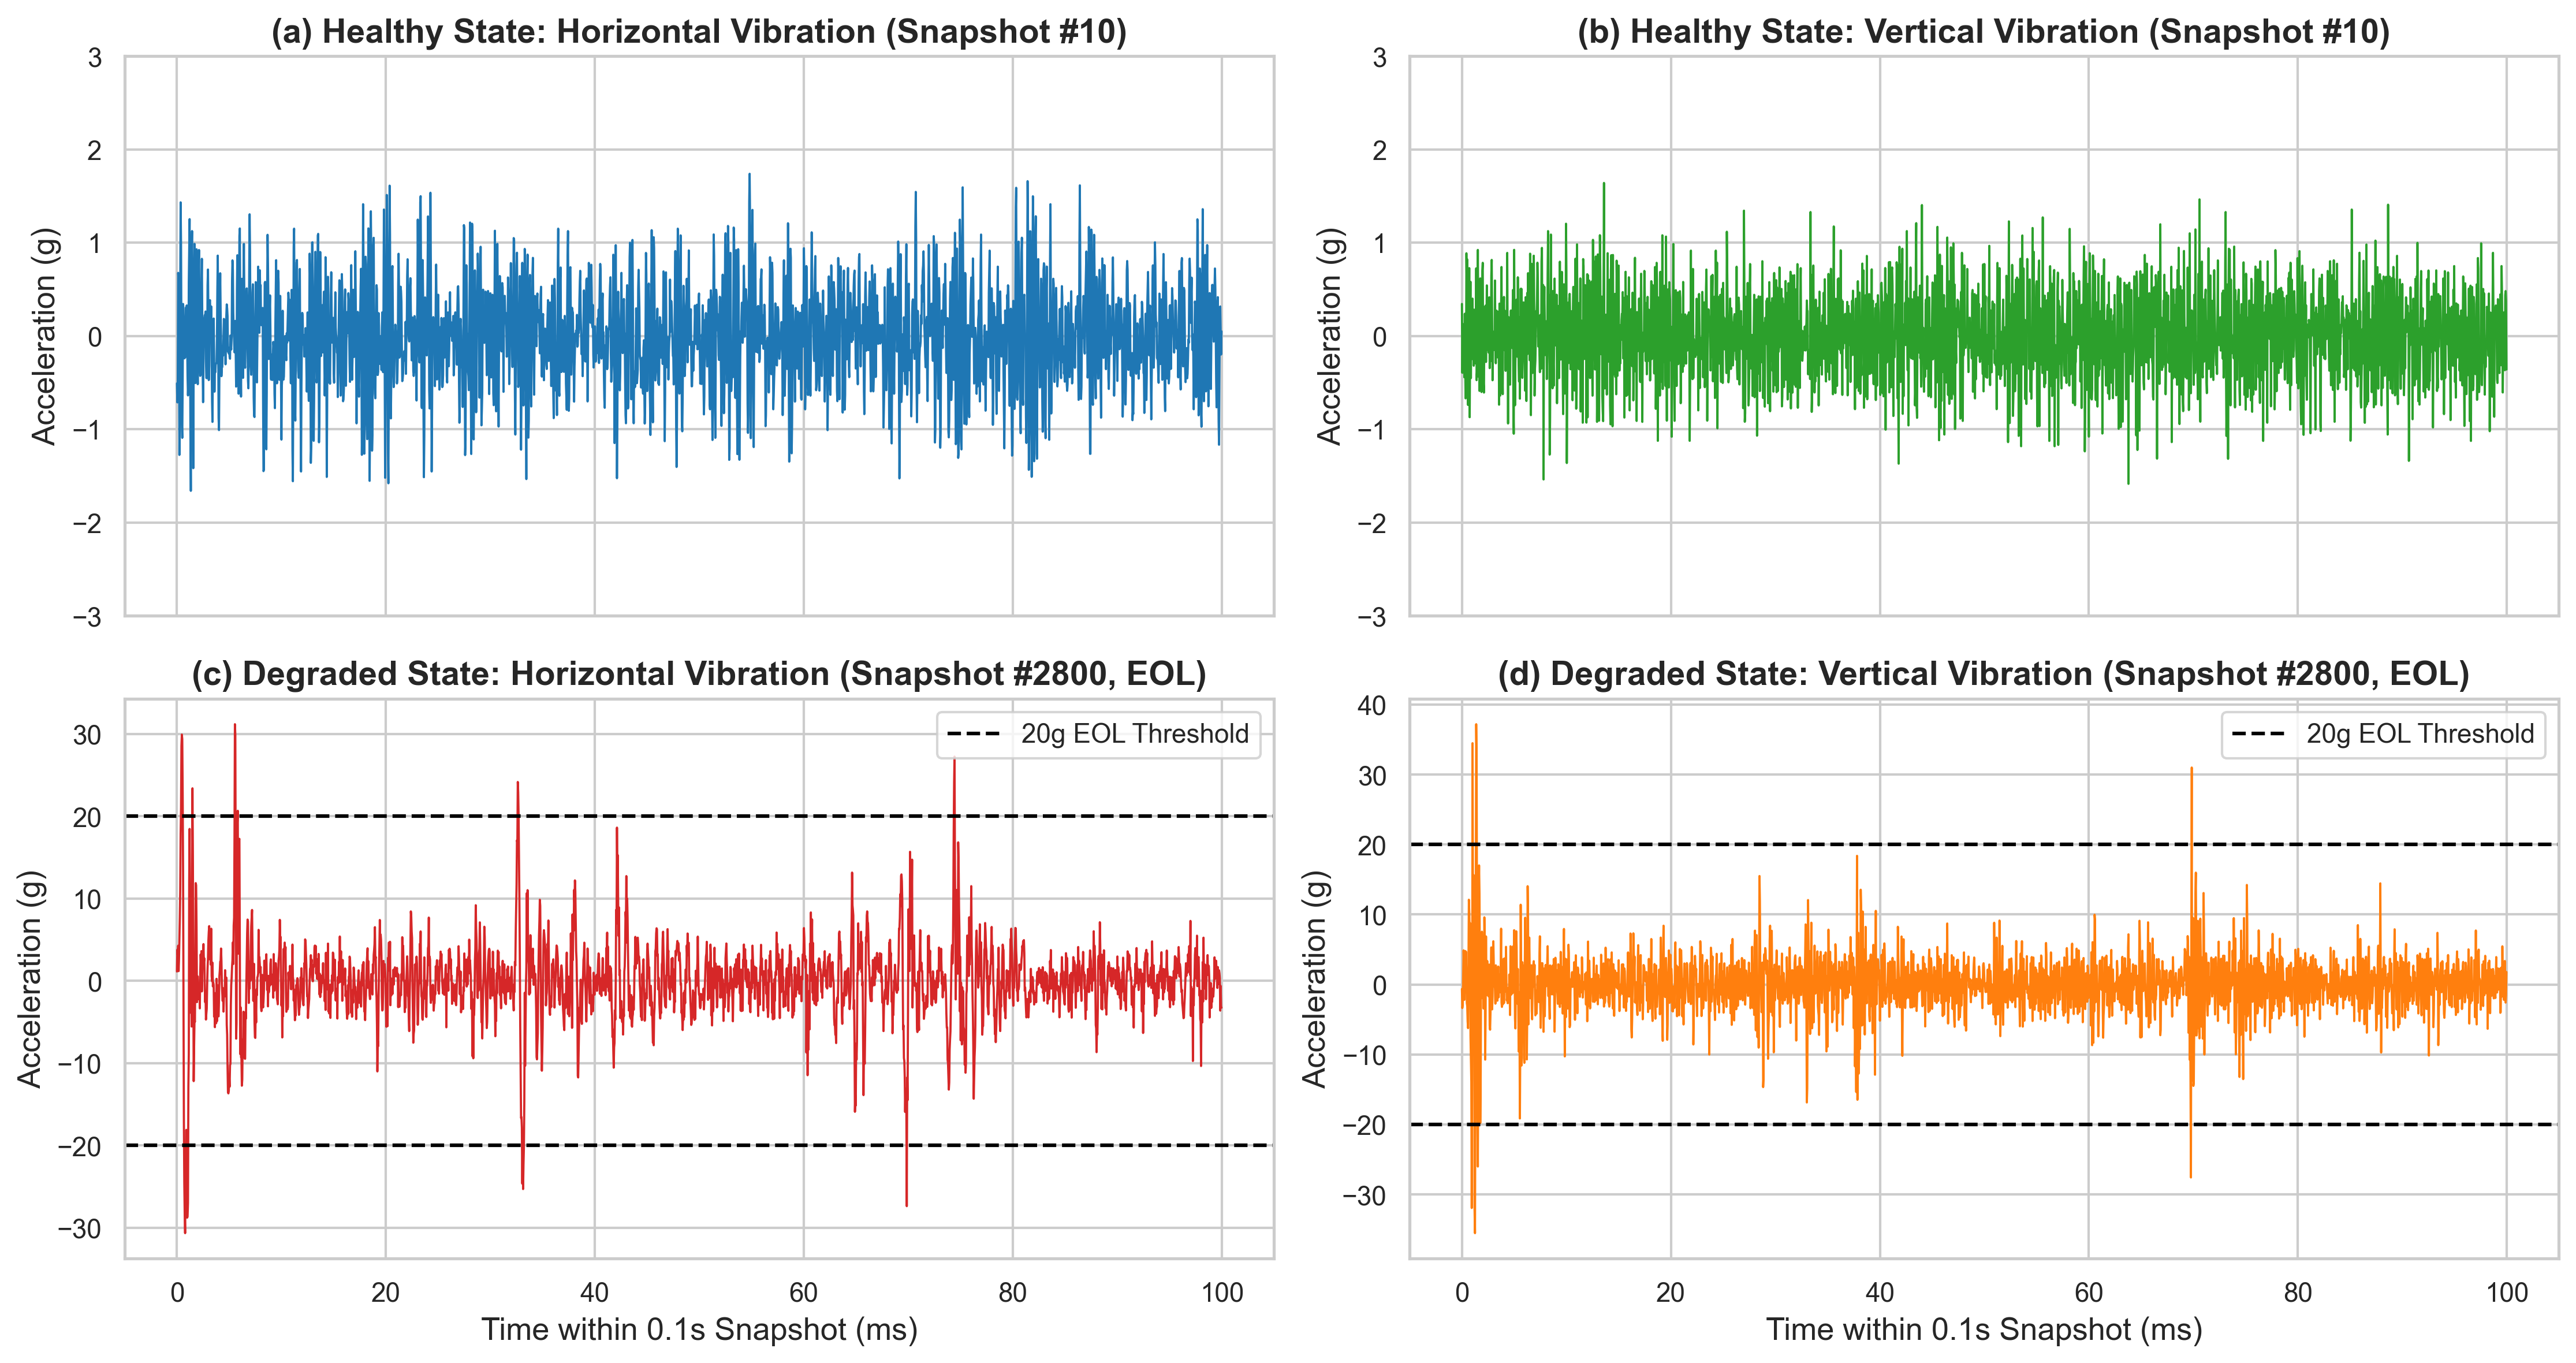

Figure 1 saved to: D:\faisal-VS\faisal project\MA_project\results\figures\fig1_raw_vibration_healthy_vs_degraded.png
Healthy  - Max Abs Peak: Horiz = 1.74g, Vert = 1.64g
Degraded - Max Abs Peak: Horiz = 31.17g, Vert = 37.19g (exceeds 20g threshold)


In [3]:
# ==============================================================================
# 2. RAW VIBRATION SIGNAL INSPECTION (HEALTHY VS DEGRADED AT 20g EOL)
# ==============================================================================
healthy_csv = os.path.join(DATASET_DIR, 'Learning_set', 'Bearing1_1', 'acc_00010.csv')
degraded_csv = os.path.join(DATASET_DIR, 'Learning_set', 'Bearing1_1', 'acc_02800.csv')

df_healthy = pd.read_csv(healthy_csv, header=None)
df_degraded = pd.read_csv(degraded_csv, header=None)

# Sample time array in milliseconds (2560 samples over 0.1 second = 100 ms)
t_ms = (np.arange(len(df_healthy)) / 25600.0) * 1000.0

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)

# Healthy - Horizontal
axes[0, 0].plot(t_ms, df_healthy[4], color='#1f77b4', lw=0.9)
axes[0, 0].set_title('(a) Healthy State: Horizontal Vibration (Snapshot #10)', fontweight='bold')
axes[0, 0].set_ylabel('Acceleration (g)')
axes[0, 0].set_ylim(-3, 3)

# Healthy - Vertical
axes[0, 1].plot(t_ms, df_healthy[5], color='#2ca02c', lw=0.9)
axes[0, 1].set_title('(b) Healthy State: Vertical Vibration (Snapshot #10)', fontweight='bold')
axes[0, 1].set_ylabel('Acceleration (g)')
axes[0, 1].set_ylim(-3, 3)

# Degraded - Horizontal
axes[1, 0].plot(t_ms, df_degraded[4], color='#d62728', lw=0.9)
axes[1, 0].axhline(20, color='black', linestyle='--', label='20g EOL Threshold')
axes[1, 0].axhline(-20, color='black', linestyle='--')
axes[1, 0].set_title('(c) Degraded State: Horizontal Vibration (Snapshot #2800, EOL)', fontweight='bold')
axes[1, 0].set_xlabel('Time within 0.1s Snapshot (ms)')
axes[1, 0].set_ylabel('Acceleration (g)')
axes[1, 0].legend(loc='upper right')

# Degraded - Vertical
axes[1, 1].plot(t_ms, df_degraded[5], color='#ff7f0e', lw=0.9)
axes[1, 1].axhline(20, color='black', linestyle='--', label='20g EOL Threshold')
axes[1, 1].axhline(-20, color='black', linestyle='--')
axes[1, 1].set_title('(d) Degraded State: Vertical Vibration (Snapshot #2800, EOL)', fontweight='bold')
axes[1, 1].set_xlabel('Time within 0.1s Snapshot (ms)')
axes[1, 1].set_ylabel('Acceleration (g)')
axes[1, 1].legend(loc='upper right')

plt.tight_layout()
fig1_path = os.path.join(FIGURES_DIR, 'fig1_raw_vibration_healthy_vs_degraded.png')
fig.savefig(fig1_path, dpi=300)
plt.show()

print(f"Figure 1 saved to: {fig1_path}")
print(f"Healthy  - Max Abs Peak: Horiz = {df_healthy[4].abs().max():.2f}g, Vert = {df_healthy[5].abs().max():.2f}g")
print(f"Degraded - Max Abs Peak: Horiz = {df_degraded[4].abs().max():.2f}g, Vert = {df_degraded[5].abs().max():.2f}g (exceeds 20g threshold)")


## 3. Spectral Analysis via Fast Fourier Transform (FFT)

### Frequency-Domain Signatures
While the time-domain signal reveals amplitude growth, the frequency spectrum reveals the internal structural mechanics of the defect.
Using the discrete Fourier transform:
$$X(f) = \sum_{n=0}^{N-1} x[n] e^{-j 2\pi f n / f_s}$$
with Nyquist frequency $f_{Nyq} = f_s / 2 = 12.8\text{ kHz}$.

In healthy bearings, vibration energy is concentrated in lower rotational harmonics. In degrading bearings:
1. Impact frequencies modulate high-frequency carrier resonances.
2. The overall spectral energy increases by orders of magnitude.
3. The **spectral centroid** and **spectral spread** shift significantly toward higher frequencies.

> **In simple words:** the FFT splits the vibration into its 'pitches'. Damage adds energy at new pitches, which is why frequency features help.


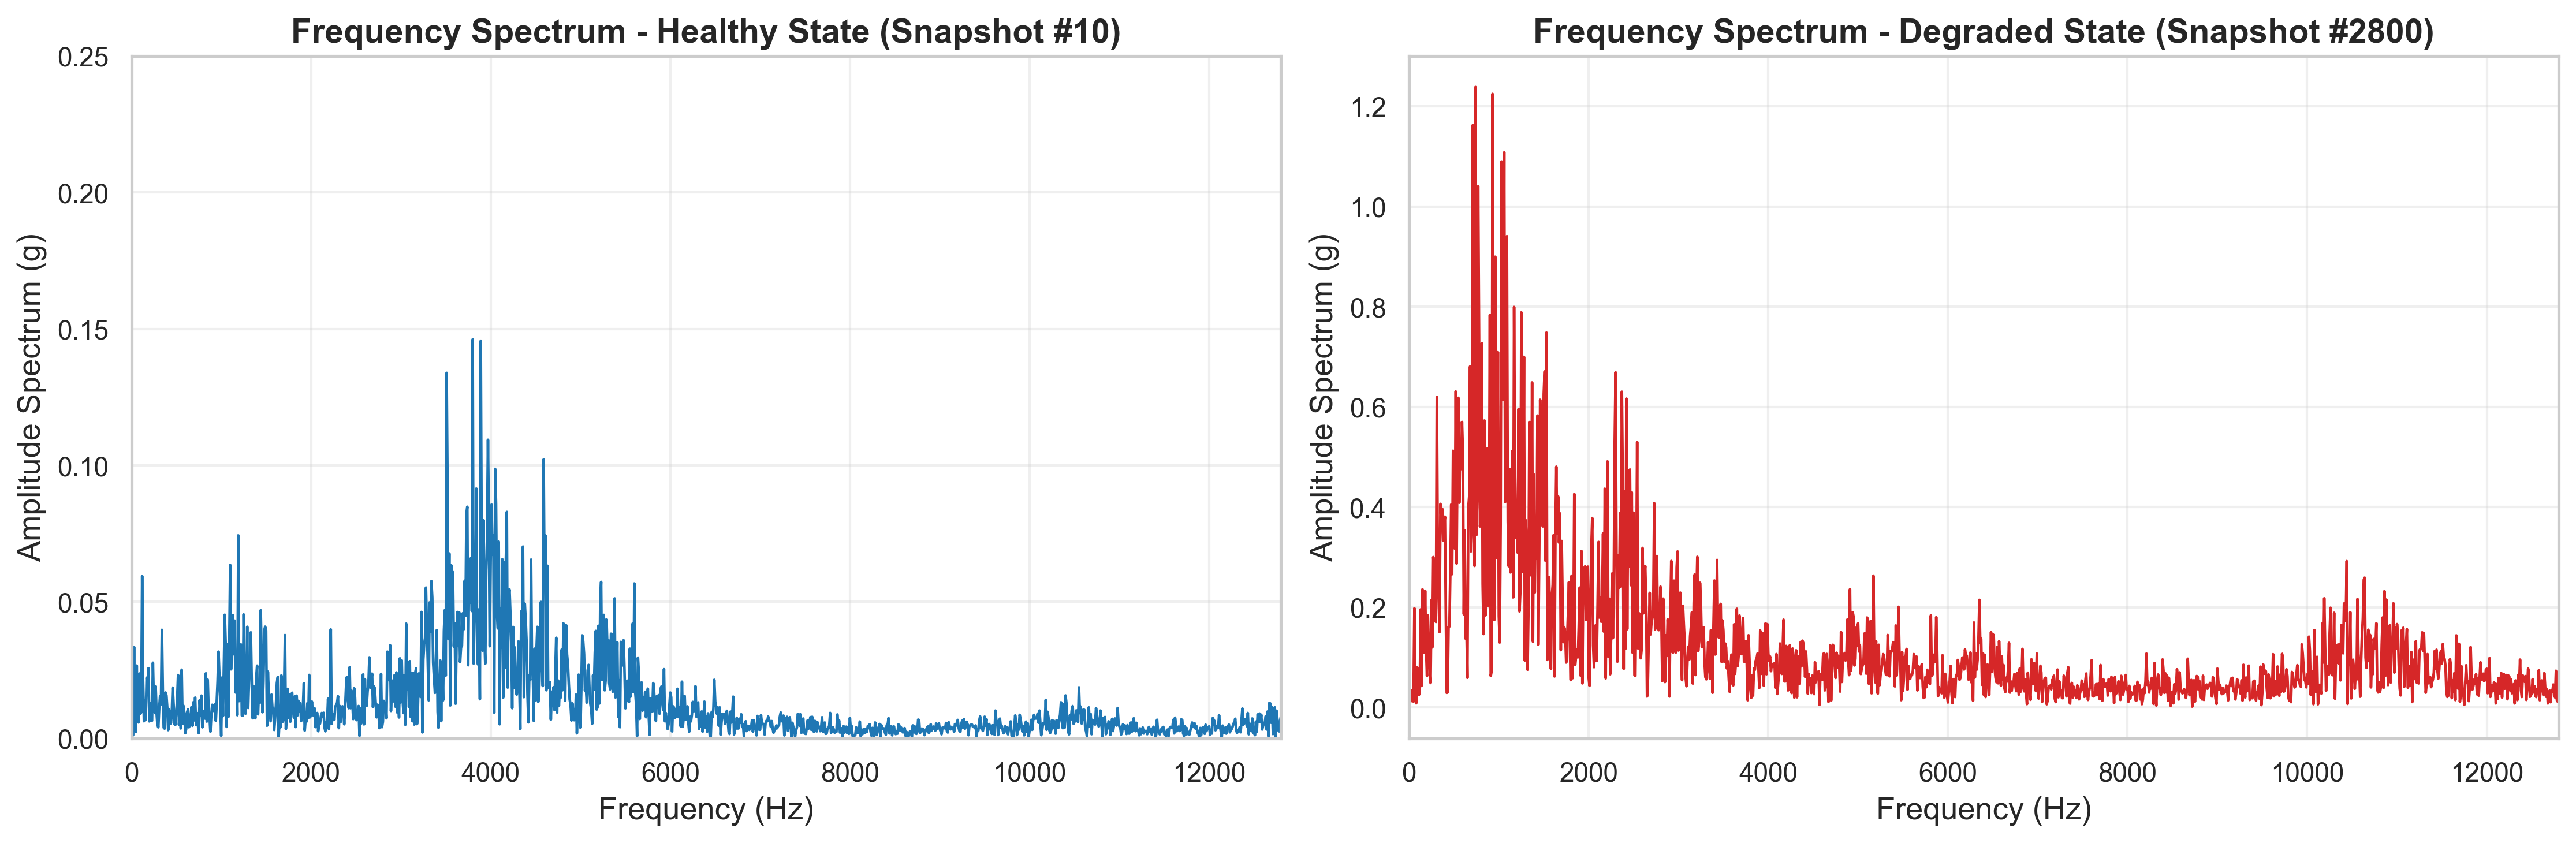

Figure 2 saved to: D:\faisal-VS\faisal project\MA_project\results\figures\fig2_frequency_spectrum_fft.png


In [4]:
# ==============================================================================
# 3. FFT FREQUENCY SPECTRUM COMPUTATION (0 TO 12.8 kHz)
# ==============================================================================
fs = 25600.0
n_pts = len(df_healthy)
freqs = np.fft.rfftfreq(n_pts, d=1.0 / fs)

fft_healthy = np.abs(np.fft.rfft(df_healthy[4].values - df_healthy[4].mean())) / n_pts * 2.0
fft_degraded = np.abs(np.fft.rfft(df_degraded[4].values - df_degraded[4].mean())) / n_pts * 2.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(freqs, fft_healthy, color='#1f77b4', lw=1.1)
ax1.set_title('Frequency Spectrum - Healthy State (Snapshot #10)', fontweight='bold')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Amplitude Spectrum (g)')
ax1.set_xlim(0, 12800)
ax1.set_ylim(0, 0.25)
ax1.grid(True, alpha=0.3)

ax2.plot(freqs, fft_degraded, color='#d62728', lw=1.1)
ax2.set_title('Frequency Spectrum - Degraded State (Snapshot #2800)', fontweight='bold')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Amplitude Spectrum (g)')
ax2.set_xlim(0, 12800)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig2_path = os.path.join(FIGURES_DIR, 'fig2_frequency_spectrum_fft.png')
fig.savefig(fig2_path, dpi=300)
plt.show()

print(f"Figure 2 saved to: {fig2_path}")


## 4. Multi-Domain Vibration Feature Engineering & Piecewise Capped Labels

### Mathematical Feature Formulations
We compute **15 statistical and spectral features per channel**, yielding **30 vibration features** per 10-second inspection snapshot:

#### Time-Domain Features ($x_i, i=1,\dots,N$):
1. **Root Mean Square (RMS)**: Measures overall vibration energy:
   $$RMS = \sqrt{\frac{1}{N}\sum_{i=1}^N x_i^2}$$
2. **Peak Value**: $\max(|x_i|)$ - captures severe shock impulses.
3. **Peak-to-Peak**: $\max(x_i) - \min(x_i)$ - total excursion range.
4. **Standard Deviation ($\sigma$)**: Dispersion around the mean.
5. **Kurtosis**: 4th standardized moment, highly sensitive to early spalling and transient impacts:
   $$Kurt = \frac{\frac{1}{N}\sum_{i=1}^N (x_i - \mu)^4}{\sigma^4} - 3$$
6. **Skewness**: 3rd standardized moment, measures distribution asymmetry.
7. **Crest Factor**: $\frac{Peak}{RMS}$ - ratio of extreme impacts to continuous vibration.
8. **Shape Factor**: $\frac{RMS}{\frac{1}{N}\sum |x_i|}$ - sensitive to signal waveform deformation.
9. **Margin Factor**: $\frac{Peak}{(\frac{1}{N}\sum \sqrt{|x_i|})^2}$ - tracks crack nucleation.
10. **Impulse Factor**: $\frac{Peak}{\frac{1}{N}\sum |x_i|}$ - detects impulse sharpness.

#### Frequency-Domain Features via FFT ($s_k = |X(f_k)|$):
11. **Spectral Energy**: $\sum_{k} s_k^2$ - total harmonic power.
12. **Spectral Centroid (Mean Frequency)**: Center of gravity of the power spectrum:
    $$f_c = \frac{\sum f_k s_k}{\sum s_k}$$
13. **Spectral Spread (Standard Deviation)**: Bandwidth dispersion:
    $$\sigma_f = \sqrt{\frac{\sum (f_k - f_c)^2 s_k}{\sum s_k}}$$
14. **Spectral Peak Frequency**: $\arg\max_{f_k}(s_k)$.
15. **Root Mean Square Frequency (RMSF)**: $\sqrt{\frac{\sum f_k^2 s_k}{\sum s_k}}$.

### Physical Target Formulations:
1. **Piecewise Capped RUL Formulation**:
   $$RUL_{capped}(t) = \min(RUL_{cap}, T_{EOL} - t), \quad y_{rul}(t) = \frac{RUL_{capped}(t)}{RUL_{cap}} \in [0, 1]$$
   where $RUL_{cap} = 16,812.0\text{ s}$ ($280.2\text{ min}$) is derived strictly from training bearings.
2. **Auxiliary RUL-Stage Classification Target**:
   To provide multi-task regularization for the continuous regression head, health stages are categorized across operational RUL horizons:
   - **Stage 0 (`Normal`)**: $y_{rul} > 0.40$ ($RUL > 112\text{ min}$)
   - **Stage 1 (`Warning`)**: $0.15 < y_{rul} \le 0.40$ ($42\text{ min} < RUL \le 112\text{ min}$)
   - **Stage 2 (`Critical`)**: $y_{rul} \le 0.15$ ($RUL \le 42\text{ min}$, approaching EOL)
   *(Note: These classes represent operational RUL stages rather than direct ISO vibration velocity zones).*

> **In simple words:** a network cannot learn well from 2,560 raw numbers when we only have 3 bearings, so we first summarise each recording into 30 meaningful numbers (energy, spikiness, pitch, ...). The target is 'how much life is left', where **1.0 = healthy for a long time** and **0 = failure now**. The cap means every moment with more than 280 min left is labelled 1.0.


In [5]:
# ==============================================================================
# 4. PARALLEL FEATURE EXTRACTION & PIECEWISE CAPPED LABEL GENERATION
# ==============================================================================
CACHE_CSV = os.path.join(RESULTS_DIR, 'extracted_bearing_features.csv')

def extract_snapshot_features(filepath, bearing_name, snapshot_idx, total_snapshots, fs=25600.0):
    """Extracts 30 vibration features and generates piecewise capped RUL targets."""
    # Bearing1_4 files are ';'-separated while all others are ','-separated
    sep = ';' if bearing_name == 'Bearing1_4' else ','
    data = pd.read_csv(filepath, sep=sep, header=None, usecols=[4, 5], dtype=np.float32).values
    h, v = data[:, 0], data[:, 1]
    
    speed, load, cond = operating_conditions_map.get(bearing_name, (1800, 4000, 1))
    
    # Physical operating time & uncapped RUL (10s interval)
    operating_time_s = snapshot_idx * 10.0
    actual_rul_s = max(0.0, (total_snapshots - 1 - snapshot_idx) * 10.0)
    
    # Piecewise capped RUL target using strictly training-derived RUL_CAP_SECONDS
    capped_rul_s = min(RUL_CAP_SECONDS, actual_rul_s)
    norm_rul = capped_rul_s / RUL_CAP_SECONDS  # normalized target in [0, 1]
    
    # Auxiliary RUL-Stage Classification Target:
    # 0 = Normal / Healthy (y_rul > 0.40)
    # 1 = Warning / Degrading (0.15 < y_rul <= 0.40)
    # 2 = Critical / Imminent Failure (y_rul <= 0.15)
    # (Note: Formulated as an auxiliary RUL-stage target for multi-task regularization)
    if norm_rul > 0.40:
        health_stage = 0
    elif norm_rul > 0.15:
        health_stage = 1
    else:
        health_stage = 2
        
    feat = {
        'bearing': bearing_name,
        'snapshot_idx': snapshot_idx,
        'operating_time_s': operating_time_s,
        'operating_time_m': operating_time_s / 60.0,
        'actual_rul_s': actual_rul_s,
        'actual_rul_m': actual_rul_s / 60.0,
        'capped_rul_s': capped_rul_s,
        'capped_rul_m': capped_rul_s / 60.0,
        'norm_rul': norm_rul,
        'health_stage': health_stage,
        'speed_rpm': speed,
        'load_n': load,
        'condition_id': cond
    }
    
    for prefix, s in [('horiz', h), ('vert', v)]:
        mean_val = np.mean(s)
        s_centered = s - mean_val
        std_val = np.std(s) + 1e-8
        rms = np.sqrt(np.mean(s**2))
        peak = np.max(np.abs(s))
        p2p = np.ptp(s)
        mean_abs = np.mean(np.abs(s)) + 1e-8
        variance = np.mean(s_centered**2) + 1e-8
        
        # Time-domain statistical indicators
        kurt = np.mean(s_centered**4) / (variance**2) - 3.0
        skew = np.mean(s_centered**3) / (variance**1.5)
        crest_factor = peak / (rms + 1e-8)
        shape_factor = rms / mean_abs
        margin_factor = peak / ((np.mean(np.sqrt(np.abs(s)))**2) + 1e-8)
        impulse_factor = peak / mean_abs
        
        # Frequency-domain spectral indicators
        fft_vals = np.abs(np.fft.rfft(s_centered))
        f_axis = np.fft.rfftfreq(len(s), d=1.0/fs)
        spec_energy = np.sum(fft_vals**2)
        fft_sum = np.sum(fft_vals) + 1e-8
        spec_centroid = np.sum(f_axis * fft_vals) / fft_sum
        spec_spread = np.sqrt(np.sum(((f_axis - spec_centroid)**2) * fft_vals) / fft_sum)
        spec_peak_freq = f_axis[np.argmax(fft_vals)]
        rmsf = np.sqrt(np.sum((f_axis**2) * fft_vals) / fft_sum)
        
        feat[f'{prefix}_rms'] = rms
        feat[f'{prefix}_peak'] = peak
        feat[f'{prefix}_p2p'] = p2p
        feat[f'{prefix}_std'] = std_val
        feat[f'{prefix}_kurtosis'] = kurt
        feat[f'{prefix}_skewness'] = skew
        feat[f'{prefix}_crest_factor'] = crest_factor
        feat[f'{prefix}_shape_factor'] = shape_factor
        feat[f'{prefix}_margin_factor'] = margin_factor
        feat[f'{prefix}_impulse_factor'] = impulse_factor
        feat[f'{prefix}_spec_energy'] = spec_energy
        feat[f'{prefix}_spec_centroid'] = spec_centroid
        feat[f'{prefix}_spec_spread'] = spec_spread
        feat[f'{prefix}_spec_peak_freq'] = spec_peak_freq
        feat[f'{prefix}_rmsf'] = rmsf
        
    return feat

def process_bearing_folder(subset_name, bearing_name):
    folder = os.path.join(DATASET_DIR, subset_name, bearing_name)
    csv_files = sorted([f for f in os.listdir(folder) if f.startswith('acc_') and f.endswith('.csv')])
    total_files = len(csv_files)
    
    tasks = [(os.path.join(folder, f), bearing_name, idx, total_files) for idx, f in enumerate(csv_files)]
    with ThreadPoolExecutor(max_workers=8) as executor:
        results = list(executor.map(lambda args: extract_snapshot_features(*args), tasks))
    return results

# Always perform clean extraction or load updated features
print("Extracting multi-domain features and computing piecewise-capped targets...")
all_features = []
for b in ['Bearing1_1', 'Bearing1_2', 'Bearing2_1', 'Bearing2_2', 'Bearing3_1', 'Bearing3_2']:
    t0 = time.time()
    res = process_bearing_folder('Learning_set', b)
    all_features.extend(res)
    print(f"  Processed {b} ({len(res)} files) in {time.time()-t0:.2f}s")
for b in ['Bearing1_3', 'Bearing2_3', 'Bearing3_3']:
    t0 = time.time()
    res = process_bearing_folder('Full_Test_Set', b)
    all_features.extend(res)
    print(f"  Processed {b} ({len(res)} files) in {time.time()-t0:.2f}s")

df_features = pd.DataFrame(all_features)
df_features.to_csv(CACHE_CSV, index=False)
print(f"Features and piecewise-capped labels saved to: {CACHE_CSV} (Total rows: {len(df_features):,})")

feature_columns = [
    'horiz_rms', 'horiz_peak', 'horiz_p2p', 'horiz_std', 'horiz_kurtosis', 'horiz_skewness',
    'horiz_crest_factor', 'horiz_shape_factor', 'horiz_margin_factor', 'horiz_impulse_factor',
    'horiz_spec_energy', 'horiz_spec_centroid', 'horiz_spec_spread', 'horiz_spec_peak_freq', 'horiz_rmsf',
    'vert_rms', 'vert_peak', 'vert_p2p', 'vert_std', 'vert_kurtosis', 'vert_skewness',
    'vert_crest_factor', 'vert_shape_factor', 'vert_margin_factor', 'vert_impulse_factor',
    'vert_spec_energy', 'vert_spec_centroid', 'vert_spec_spread', 'vert_spec_peak_freq', 'vert_rmsf'
]
print(f"Engineered feature vector dimension: {len(feature_columns)}")


Extracting multi-domain features and computing piecewise-capped targets...


  Processed Bearing1_1 (2803 files) in 8.11s


  Processed Bearing1_2 (871 files) in 1.84s


  Processed Bearing2_1 (911 files) in 1.91s


  Processed Bearing2_2 (797 files) in 1.69s


...

  Processed Bearing3_2 (1637 files) in 3.63s


  Processed Bearing1_3 (2375 files) in 6.55s


  Processed Bearing2_3 (1955 files) in 3.72s


  Processed Bearing3_3 (434 files) in 0.78s


Features and piecewise-capped labels saved to: D:\faisal-VS\faisal project\MA_project\results\extracted_bearing_features.csv (Total rows: 12,298)
Engineered feature vector dimension: 30


## 5. Feature Progression & Monotonicity Analysis

### Which features move as the bearing degrades?
Measured on the two long Condition-1 bearings (mean of the feature inside each life segment; source: `results/extracted_bearing_features.csv`):

| Life segment | B1_1 kurtosis | B1_1 RMS (g) | B1_3 kurtosis | B1_3 RMS (g) |
|---|---|---|---|---|
| 0-50% | 0.27 | 0.36 | 0.49 | 0.36 |
| 50-70% | 1.03 | 0.60 | 0.48 | 0.51 |
| 70-85% | 2.23 | 0.89 | 4.02 | 0.90 |
| 85-95% | 2.95 | 1.23 | 5.86 | 1.29 |
| 95-100% | 6.05 | 2.36 | 6.61 | 3.82 |

1. **RMS and peak** grow steadily and fastest near the end.
2. **Kurtosis (spikiness)** rises well before RMS becomes large: on Bearing1_3 it jumps 8x between the 50-70% and 70-85% segments while RMS only grows about 1.8x. It does **not** fall back at the end in these data; it keeps rising.
3. The **onset point differs between bearings** (gradual from about 50% on Bearing1_1, abrupt at about 70% on Bearing1_3). This bearing-to-bearing difference is exactly what makes cross-bearing RUL prediction hard (Section 16).

> **In simple words:** damage makes the vibration *stronger* (RMS, peak) and *spikier* (kurtosis, crest factor). Spikiness gives the earlier hint.


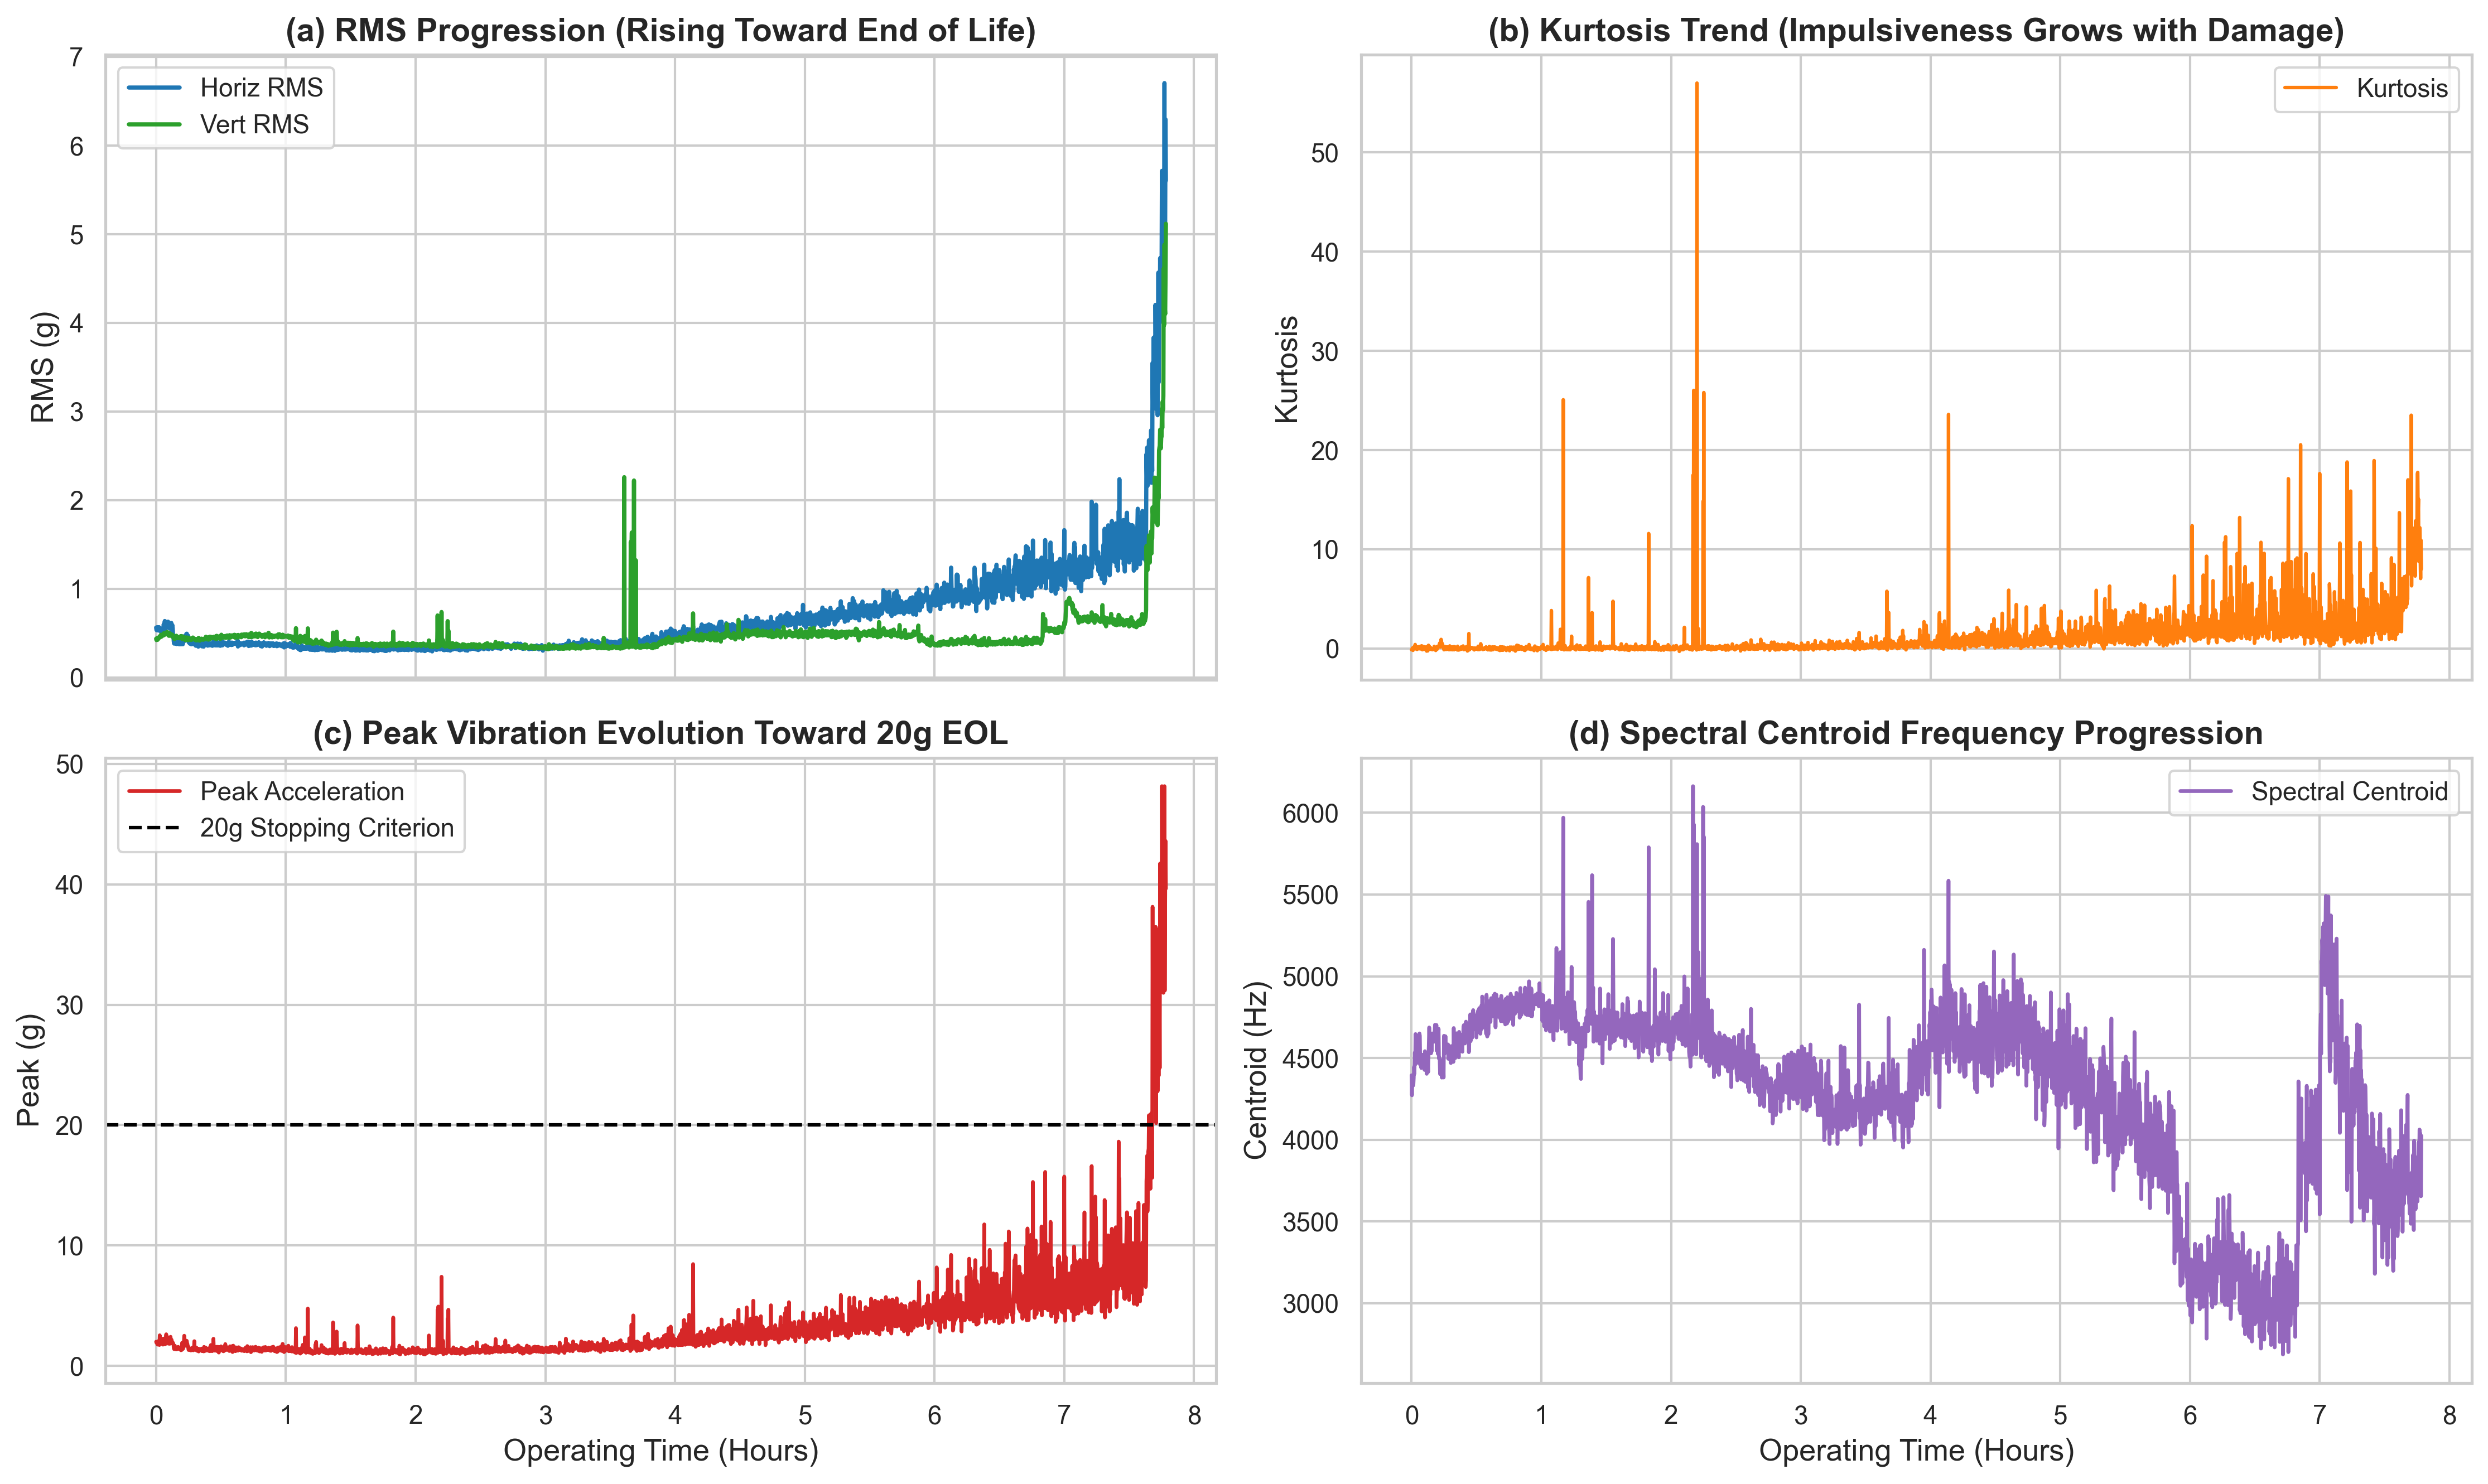

Figure 3 saved to: D:\faisal-VS\faisal project\MA_project\results\figures\fig3_vibration_feature_trends.png


In [6]:
# ==============================================================================
# 5. VISUALIZING FEATURE EVOLUTION ACROSS BEARING LIFETIME
# ==============================================================================
b1_1 = df_features[df_features['bearing'] == 'Bearing1_1'].sort_values('snapshot_idx')
t_hours = b1_1['operating_time_s'] / 3600.0

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)

# RMS Trend
axes[0, 0].plot(t_hours, b1_1['horiz_rms'], color='#1f77b4', lw=1.8, label='Horiz RMS')
axes[0, 0].plot(t_hours, b1_1['vert_rms'], color='#2ca02c', lw=1.8, label='Vert RMS')
axes[0, 0].set_title('(a) RMS Progression (Rising Toward End of Life)', fontweight='bold')
axes[0, 0].set_ylabel('RMS (g)')
axes[0, 0].legend()

# Kurtosis Trend
axes[0, 1].plot(t_hours, b1_1['horiz_kurtosis'], color='#ff7f0e', lw=1.5, label='Kurtosis')
axes[0, 1].set_title('(b) Kurtosis Trend (Impulsiveness Grows with Damage)', fontweight='bold')
axes[0, 1].set_ylabel('Kurtosis')
axes[0, 1].legend()

# Peak Vibration vs 20g Threshold
axes[1, 0].plot(t_hours, b1_1['horiz_peak'], color='#d62728', lw=1.6, label='Peak Acceleration')
axes[1, 0].axhline(20, color='black', linestyle='--', label='20g Stopping Criterion')
axes[1, 0].set_title('(c) Peak Vibration Evolution Toward 20g EOL', fontweight='bold')
axes[1, 0].set_xlabel('Operating Time (Hours)')
axes[1, 0].set_ylabel('Peak (g)')
axes[1, 0].legend()

# Spectral Centroid Trend
axes[1, 1].plot(t_hours, b1_1['horiz_spec_centroid'], color='#9467bd', lw=1.6, label='Spectral Centroid')
axes[1, 1].set_title('(d) Spectral Centroid Frequency Progression', fontweight='bold')
axes[1, 1].set_xlabel('Operating Time (Hours)')
axes[1, 1].set_ylabel('Centroid (Hz)')
axes[1, 1].legend()

plt.tight_layout()
fig3_path = os.path.join(FIGURES_DIR, 'fig3_vibration_feature_trends.png')
fig.savefig(fig3_path, dpi=300)
plt.show()

print(f"Figure 3 saved to: {fig3_path}")


## 6. Ground-Truth Piecewise RUL & Leakage-Free Sequence Formulation

### Strict Bearing-Level Partitioning Strategy
In prognostics, **random sequence splitting causes catastrophic data leakage** because adjacent sliding windows share 95%+ of identical time series samples. 

To guarantee scientific validity and zero data leakage:
- **Partitioning is strictly bearing-level**:
  - **Training Bearings**: `Bearing1_1` (Cond 1), `Bearing2_1` (Cond 2), `Bearing3_1` (Cond 3)
  - **Validation Bearings**: `Bearing1_2` (Cond 1), `Bearing2_2` (Cond 2), `Bearing3_2` (Cond 3)
  - **Held-Out Test Bearings**: `Bearing1_3` (Cond 1), `Bearing2_3` (Cond 2), `Bearing3_3` (Cond 3)
- **Scaler Isolation**: `StandardScaler` is fitted **strictly on training bearings**, then applied to validation and test bearings.
- **Sequence Generation**: Sliding temporal windows of length $W=16$ snapshots ($160\text{ seconds}$ historical context) are created **strictly within each individual bearing trajectory**.

> **In simple words:** we train on some bearings and test on completely different bearings, like studying old exam papers and sitting a new exam. No bearing appears in two sets. The model looks at the last 16 recordings (about 2.7 minutes) to make each prediction.


In [7]:
# ==============================================================================
# 6. LEAKAGE-FREE BEARING-LEVEL SPLIT & SEQUENCE FORMULATION
# ==============================================================================
train_bearings = ['Bearing1_1', 'Bearing2_1', 'Bearing3_1']
val_bearings   = ['Bearing1_2', 'Bearing2_2', 'Bearing3_2']
test_bearings  = ['Bearing1_3', 'Bearing2_3', 'Bearing3_3']

# Fit scaler strictly on training bearings
scaler = StandardScaler()
train_mask = df_features['bearing'].isin(train_bearings)
scaler.fit(df_features.loc[train_mask, feature_columns])

# Save scaler and feature names
joblib.dump(scaler, os.path.join(MODELS_DIR, 'scaler.pkl'))
with open(os.path.join(MODELS_DIR, 'feature_names.json'), 'w') as f:
    json.dump(feature_columns, f, indent=2)

WINDOW_SIZE = 16 # 16 snapshots * 10s = 160 seconds context

def build_temporal_sequences(dataframe, bearing_list, window_len=16):
    """Creates sliding temporal windows strictly isolated per bearing."""
    X_list, y_rul_list, y_risk_list, meta_list = [], [], [], []
    for b in bearing_list:
        sub = dataframe[dataframe['bearing'] == b].sort_values('snapshot_idx').reset_index(drop=True)
        scaled_x = scaler.transform(sub[feature_columns])
        norm_ruls = sub['norm_rul'].values
        risk_stages = sub['health_stage'].values
        time_s = sub['operating_time_s'].values
        capped_s = sub['capped_rul_s'].values
        actual_s = sub['actual_rul_s'].values
        
        n_pts = len(sub)
        for i in range(n_pts - window_len + 1):
            X_list.append(scaled_x[i : i + window_len])
            y_rul_list.append(norm_ruls[i + window_len - 1])
            y_risk_list.append(risk_stages[i + window_len - 1])
            meta_list.append({
                'bearing': b,
                'snapshot_idx': sub['snapshot_idx'].iloc[i + window_len - 1],
                'operating_time_s': time_s[i + window_len - 1],
                'operating_time_m': time_s[i + window_len - 1] / 60.0,
                'capped_rul_s': capped_s[i + window_len - 1],
                'capped_rul_m': capped_s[i + window_len - 1] / 60.0,
                'actual_rul_s': actual_s[i + window_len - 1],
                'actual_rul_m': actual_s[i + window_len - 1] / 60.0,
                'norm_rul_target': norm_ruls[i + window_len - 1],
                'health_stage': risk_stages[i + window_len - 1]
            })
    return np.array(X_list, dtype=np.float32), np.array(y_rul_list, dtype=np.float32), np.array(y_risk_list, dtype=np.int32), pd.DataFrame(meta_list)

X_train, y_rul_train, y_risk_train, df_meta_train = build_temporal_sequences(df_features, train_bearings, WINDOW_SIZE)
X_val,   y_rul_val,   y_risk_val,   df_meta_val   = build_temporal_sequences(df_features, val_bearings, WINDOW_SIZE)
X_test,  y_rul_test,  y_risk_test,  df_meta_test  = build_temporal_sequences(df_features, test_bearings, WINDOW_SIZE)

print(f"Training Sequences   : {X_train.shape} | RUL: {y_rul_train.shape} | Risk: {y_risk_train.shape}")
print(f"Validation Sequences : {X_val.shape}   | RUL: {y_rul_val.shape}   | Risk: {y_risk_val.shape}")
print(f"Test Sequences       : {X_test.shape}  | RUL: {y_rul_test.shape}  | Risk: {y_risk_test.shape}")
# --- Real leakage checks (the notebook stops with an error if any of these is violated) ---
assert not (set(train_bearings) & set(val_bearings)) and not (set(train_bearings) & set(test_bearings)) \
    and not (set(val_bearings) & set(test_bearings)), "bearing sets overlap"
assert set(df_meta_train['bearing']) == set(train_bearings) and set(df_meta_val['bearing']) == set(val_bearings) \
    and set(df_meta_test['bearing']) == set(test_bearings), "a window contains a bearing from another split"
assert np.allclose(scaler.mean_, df_features.loc[train_mask, feature_columns].mean().values, rtol=1e-4), "scaler not fitted on train only"
print("Leakage checks passed: disjoint bearing sets, windows built inside one bearing, scaler fitted on training bearings only.")


Training Sequences   : (4184, 16, 30) | RUL: (4184,) | Risk: (4184,)
Validation Sequences : (3260, 16, 30)   | RUL: (3260,)   | Risk: (3260,)
Test Sequences       : (4719, 16, 30)  | RUL: (4719,)  | Risk: (4719,)


Leakage checks passed: disjoint bearing sets, windows built inside one bearing, scaler fitted on training bearings only.


## 7. Explainable Dual-Head CNN–BiLSTM–Attention Architecture

```
[Input: (Batch, 16 Time Steps, 30 Features)]
                  │
                  ▼
  [1D CNN Layer 1: 64 Filters, Kernel 3] + BatchNorm + Dropout(0.2)
                  │
                  ▼
  [1D CNN Layer 2: 64 Filters, Kernel 3] + BatchNorm + Dropout(0.2)
                  │
                  ▼
[Bidirectional LSTM Layer: 64 Units (Total 128)] + Dropout(0.2)
                  │
                  ▼
[Temporal Attention Layer: Computes Explainable Weights α_t]
                  │
                  ▼ Context Vector c = Σ α_t h_t
     [Shared Latent Dense Layer: 64 Units]
                  │
         ┌────────┴────────┐
         ▼                 ▼
[Head 1: RUL Regression]  [Head 2: Auxiliary RUL-Stage Classification]
Dense(32) -> Dense(1)     Dense(32) -> Dense(3, Softmax)
Linear Output             Probability across Normal/Warn/Crit
```

### Mathematical Formulation of Temporal Attention Explainability:
Given hidden state $\mathbf{h}_t \in \mathbb{R}^{D}$ produced by the BiLSTM at sequence step $t \in \{1, \dots, W\}$:
1. Alignment Score:
   $$e_t = \mathbf{u}^T \tanh(\mathbf{W}_a \mathbf{h}_t + \mathbf{b}_a)$$
2. Normalized Attention Weights (Softmax over time steps):
   $$\alpha_t = \frac{\exp(e_t)}{\sum_{j=1}^W \exp(e_j)}, \quad \sum_{t=1}^W \alpha_t = 1.0$$
3. Context Representation Vector:
   $$\mathbf{c} = \sum_{t=1}^W \alpha_t \mathbf{h}_t$$

The scalar weights $\alpha_t$ directly explain **which historical moments** across the 16-step ($160\text{ s}$) window the model concentrates on to project failure risk.

> **In simple words, and why this combination?**
> - **CNN**: scans neighbouring time steps and learns useful combinations of the 30 features (local patterns, noise smoothing).
> - **BiLSTM**: remembers the *order* of the 16 steps. Degradation is a process in time, not one reading. Reading the window both directions is allowed because the whole window is in the past.
> - **Attention**: chooses which of the 16 steps matter most and lets us see that choice (explainability).
> - **Two heads**: one shared summary feeds (1) an RUL number and (2) a Normal/Warning/Critical stage. The stage task acts as a regulariser and gives operators an alarm level.
>
> We do **not** just claim these blocks help. Section 14 removes them one at a time and compares against simple models.


In [8]:
# ==============================================================================
# 7. MODEL ARCHITECTURE DEFINITION WITH CUSTOM TEMPORAL ATTENTION
# ==============================================================================
@tf.keras.utils.register_keras_serializable()
class TemporalAttention(layers.Layer):
    """Custom Attention Layer calculating temporal importance weights across sequence time steps."""
    def __init__(self, **kwargs):
        super(TemporalAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        d = input_shape[-1]
        self.W = self.add_weight(name='attention_weight', shape=(d, d),
                                 initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(d,),
                                 initializer='zeros', trainable=True)
        self.u = self.add_weight(name='context_vector', shape=(d, 1),
                                 initializer='glorot_uniform', trainable=True)
        super(TemporalAttention, self).build(input_shape)

    def call(self, inputs):
        # inputs shape: (batch_size, time_steps, features)
        uit = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        ait = tf.tensordot(uit, self.u, axes=1)
        weights = tf.nn.softmax(ait, axis=1) # (batch_size, time_steps, 1)
        context = tf.reduce_sum(inputs * weights, axis=1) # (batch_size, features)
        return context, weights

    def get_config(self):
        config = super(TemporalAttention, self).get_config()
        return config

def build_dual_head_model(window_len=16, n_feats=30):
    inp = layers.Input(shape=(window_len, n_feats), name='sequence_input')
    
    # 1D CNN Local Feature Extractor
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu', name='conv1')(inp)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Dropout(0.2, name='drop1')(x)
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Dropout(0.2, name='drop2')(x)
    
    # Bidirectional LSTM Temporal Progression Extractor
    bilstm = layers.Bidirectional(layers.LSTM(64, return_sequences=True), name='bilstm')(x)
    bilstm = layers.Dropout(0.2, name='drop_bilstm')(bilstm)
    
    # Temporal Attention Layer
    context, attn_weights = TemporalAttention(name='temporal_attention')(bilstm)
    
    # Shared Latent Representation
    shared = layers.Dense(64, activation='relu', name='shared_dense')(context)
    shared = layers.Dropout(0.2, name='drop_shared')(shared)
    
    # Head 1: RUL Regression
    rul_dense = layers.Dense(32, activation='relu', name='rul_dense')(shared)
    rul_out = layers.Dense(1, activation='linear', name='rul_output')(rul_dense)
    
    # Head 2: Auxiliary RUL-Stage Classification
    risk_dense = layers.Dense(32, activation='relu', name='risk_dense')(shared)
    risk_out = layers.Dense(3, activation='softmax', name='risk_output')(risk_dense)
    
    return Model(inputs=inp, outputs={'rul_output': rul_out, 'risk_output': risk_out}, name='DualHead_CNN_BiLSTM_Attention')

model = build_dual_head_model(WINDOW_SIZE, len(feature_columns))
model.summary()


Model: "DualHead_CNN_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 16, 30)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 16, 64)    │      5,824 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 16, 64)    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 16, 64)    │          0 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 16, 64)    │     12,352 │ drop1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 16, 64)    │        256 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2 (Dropout)     │ (None, 16, 64)    │          0 │ bn2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 16, 128)   │     66,048 │ drop2[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_bilstm         │ (None, 16, 128)   │          0 │ bilstm[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_attention  │ [(None, 128),     │     16,640 │ drop_bilstm[0][0] │
│ (TemporalAttention) │ (None, 16, 1)]    │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense        │ (None, 64)        │      8,256 │ temporal_attenti… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_shared         │ (None, 64)        │          0 │ shared_dense[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ risk_dense (Dense)  │ (None, 32)        │      2,080 │ drop_shared[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rul_dense (Dense)   │ (None, 32)        │      2,080 │ drop_shared[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ risk_output (Dense) │ (None, 3)         │         99 │ risk_dense[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rul_output (Dense)  │ (None, 1)         │         33 │ rul_dense[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 113,924 (445.02 KB)

 Trainable params: 113,668 (444.02 KB)

 Non-trainable params: 256 (1.00 KB)

## 8. Multi-Task Model Compilation, Training & Convergence Dynamics

### Multi-Task Objective Function
$$\mathcal{L}_{total} = \lambda_{rul} \cdot \mathcal{L}_{Huber}(y_{rul}, \hat{y}_{rul}) + \lambda_{risk} \cdot \mathcal{L}_{CE}(y_{risk}, \hat{y}_{risk})$$
- **Huber Loss**: Combines the smoothness of MSE for small residuals with the robustness of MAE against large noise outliers.
- **Sparse Categorical Cross-Entropy**: Trains the auxiliary classification head to distinguish `Normal`, `Warning`, and `Critical` operational horizons.
- **Loss Weights**: $\lambda_{rul} = 1.0, \lambda_{risk} = 0.5$.
- **Execution**: The cell below executes `model.fit()` cleanly, captures training history, and generates **Figure 4 (Training Convergence Curves)**.

> **In simple words:** Huber loss ignores extreme errors a bit (robust). Cross-entropy trains the stage head. **Early stopping** ends training when validation error stops improving, to avoid memorising the training bearings.


Starting training of proposed Dual-Head CNN-BiLSTM-Attention Model...
Epoch 1/35


 1/66 ━━━━━━━━━━━━━━━━━━━━ 4:46 4s/step - loss: 0.7343 - risk_output_accuracy: 0.5781 - risk_output_loss: 1.0552 - rul_output_loss: 0.2067 - rul_output_mae: 0.5521

 5/66 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6384 - risk_output_accuracy: 0.5933 - risk_output_loss: 0.9963 - rul_output_loss: 0.1403 - rul_output_mae: 0.4305

10/66 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5783 - risk_output_accuracy: 0.6185 - risk_output_loss: 0.9368 - rul_output_loss: 0.1099 - rul_output_mae: 0.3676

15/66 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5349 - risk_output_accuracy: 0.6387 - risk_output_loss: 0.8803 - rul_output_loss: 0.0947 - rul_output_mae: 0.3363

...

57/66 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0216 - risk_output_accuracy: 0.9902 - risk_output_loss: 0.0331 - rul_output_loss: 0.0050 - rul_output_mae: 0.0781

61/66 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0215 - risk_output_accuracy: 0.9902 - risk_output_loss: 0.0330 - rul_output_loss: 0.0050 - rul_output_mae: 0.0779

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0214 - risk_output_accuracy: 0.9902 - risk_output_loss: 0.0328 - rul_output_loss: 0.0050 - rul_output_mae: 0.0777

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0202 - risk_output_accuracy: 0.9897 - risk_output_loss: 0.0307 - rul_output_loss: 0.0048 - rul_output_mae: 0.0754 - val_loss: 1.8565 - val_risk_output_accuracy: 0.3773 - val_risk_output_loss: 3.5969 - val_rul_output_loss: 0.0576 - val_rul_output_mae: 0.2486 - learning_rate: 2.5000e-04


Training completed in 13.45 seconds.
Best model saved to: D:\faisal-VS\faisal project\MA_project\models\dual_head_cnn_bilstm_attention.keras


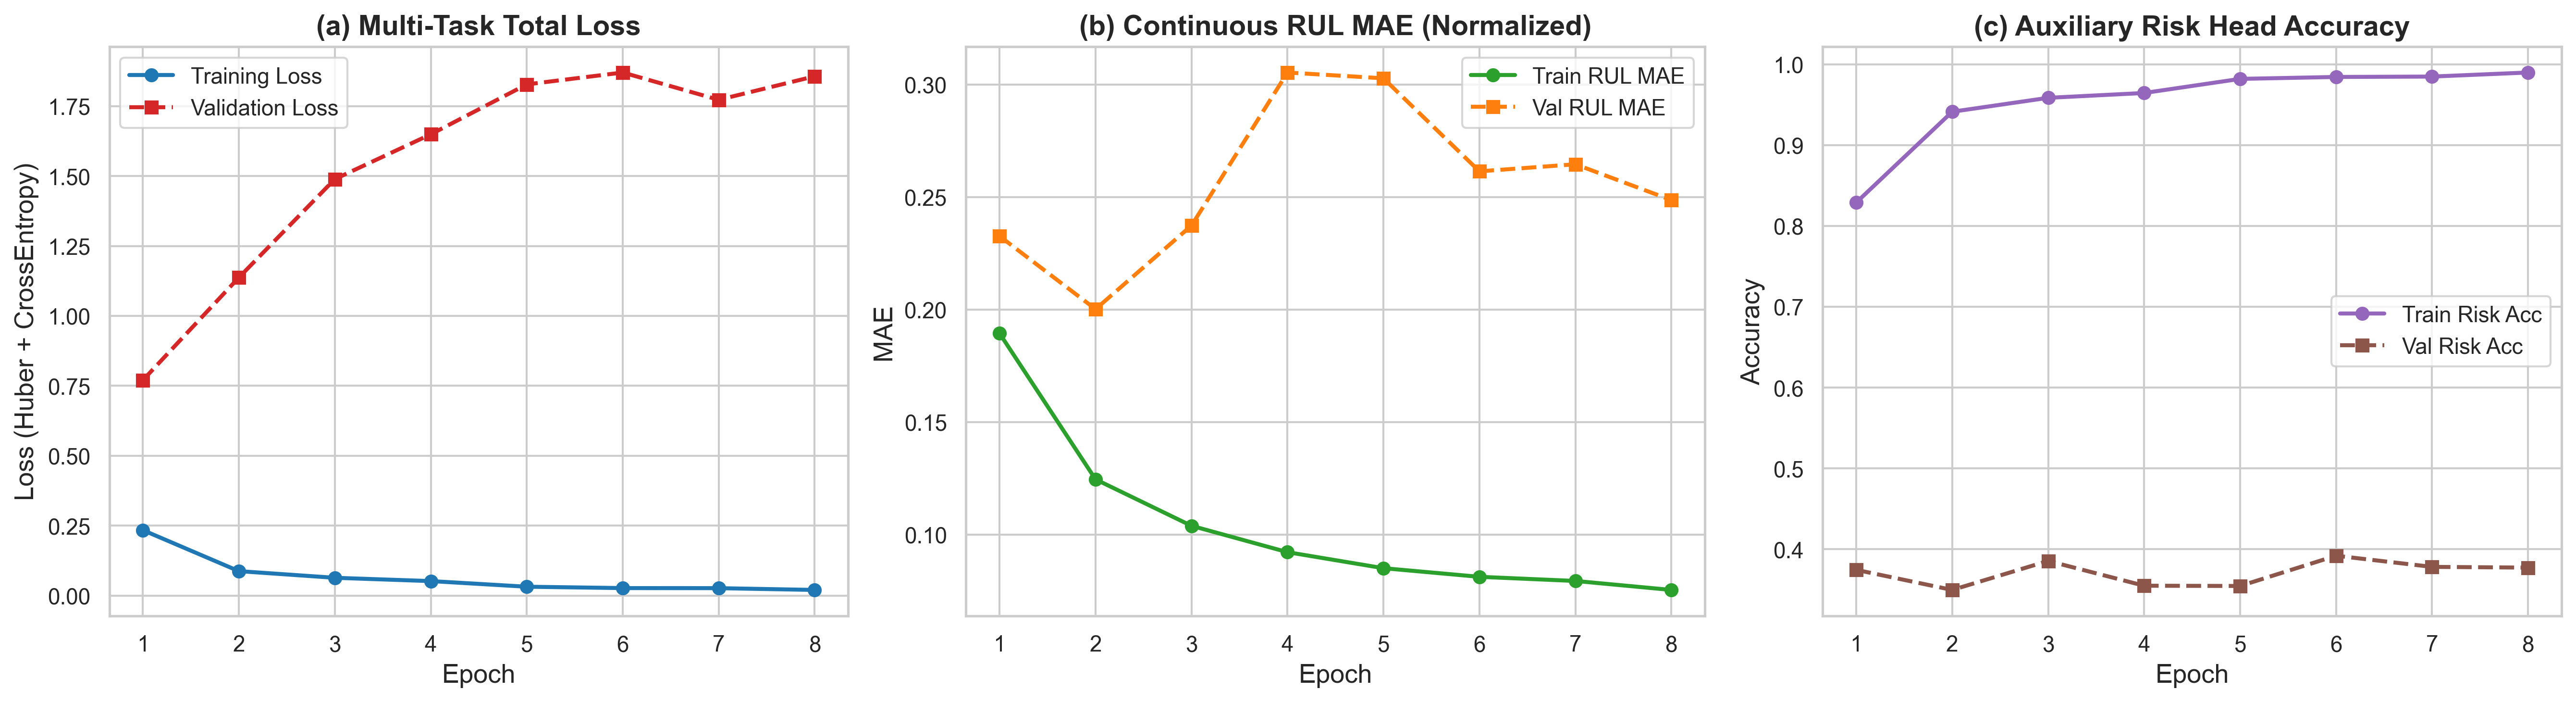

Figure 4 saved to: D:\faisal-VS\faisal project\MA_project\results\figures\fig4_training_convergence.png


In [9]:
# ==============================================================================
# 8. MULTI-TASK MODEL COMPILATION, TRAINING & CONVERGENCE VISUALIZATION
# ==============================================================================
MODEL_CHECKPOINT_PATH = os.path.join(MODELS_DIR, 'dual_head_cnn_bilstm_attention.keras')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss={'rul_output': 'huber', 'risk_output': 'sparse_categorical_crossentropy'},
    loss_weights={'rul_output': 1.0, 'risk_output': 0.5},
    metrics={'rul_output': 'mae', 'risk_output': 'accuracy'}
)

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr  = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
chkpoint   = callbacks.ModelCheckpoint(MODEL_CHECKPOINT_PATH, monitor='val_loss', save_best_only=True)

print("Starting training of proposed Dual-Head CNN-BiLSTM-Attention Model...")
t_start = time.time()
history = model.fit(
    X_train, {'rul_output': y_rul_train, 'risk_output': y_risk_train},
    validation_data=(X_val, {'rul_output': y_rul_val, 'risk_output': y_risk_val}),
    epochs=35,
    batch_size=64,
    callbacks=[early_stop, reduce_lr, chkpoint],
    verbose=1
)
print(f"Training completed in {time.time()-t_start:.2f} seconds.")
model.save(MODEL_CHECKPOINT_PATH)
print(f"Best model saved to: {MODEL_CHECKPOINT_PATH}")

# ------------------------------------------------------------------------------
# FIGURE 4: Training Convergence Dynamics (Loss, RUL MAE, Risk Accuracy)
# ------------------------------------------------------------------------------
epochs_range = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: Total Multi-Task Loss
axes[0].plot(epochs_range, history.history['loss'], 'o-', color='#1f77b4', lw=2, label='Training Loss')
axes[0].plot(epochs_range, history.history['val_loss'], 's--', color='#d62728', lw=2, label='Validation Loss')
axes[0].set_title('(a) Multi-Task Total Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Huber + CrossEntropy)')
axes[0].legend()

# Subplot 2: RUL MAE
axes[1].plot(epochs_range, history.history['rul_output_mae'], 'o-', color='#2ca02c', lw=2, label='Train RUL MAE')
axes[1].plot(epochs_range, history.history['val_rul_output_mae'], 's--', color='#ff7f0e', lw=2, label='Val RUL MAE')
axes[1].set_title('(b) Continuous RUL MAE (Normalized)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

# Subplot 3: Risk Classification Accuracy
axes[2].plot(epochs_range, history.history['risk_output_accuracy'], 'o-', color='#9467bd', lw=2, label='Train Risk Acc')
axes[2].plot(epochs_range, history.history['val_risk_output_accuracy'], 's--', color='#8c564b', lw=2, label='Val Risk Acc')
axes[2].set_title('(c) Auxiliary Risk Head Accuracy', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()

plt.tight_layout()
fig4_path = os.path.join(FIGURES_DIR, 'fig4_training_convergence.png')
fig.savefig(fig4_path, dpi=300)
plt.show()

print(f"Figure 4 saved to: {fig4_path}")


## 9. Comprehensive Academic Evaluation on Unseen Test Bearings

### Quantitative Evaluation Methodology & Leak-Free De-Normalization
We assess prognostic performance on held-out test bearings (`Bearing1_3`, `Bearing2_3`, `Bearing3_3`):

1. **Leak-Free RUL De-Normalization**:
   $$\hat{RUL}_{seconds} = \hat{y}_{norm} \times RUL_{cap}, \quad \hat{RUL}_{minutes} = \frac{\hat{RUL}_{seconds}}{60.0}$$
   **Crucial Scientific Verification**: $RUL_{cap} = 16,812.0\text{ s}$ is a fixed constant derived strictly from the training bearings. **No test-bearing lifetime is used anywhere** in prediction de-normalization!
2. **RUL Mean Absolute Error (MAE)** & **Root Mean Square Error (RMSE)**:
   Evaluated against physical ground-truth capped RUL ($RUL_{capped}$) and normalized targets.
3. **Trajectory-Averaged PHM Prognostic Score (T-Score)**:
   $$\%Er_i = 100 \times \frac{RUL_{capped, i} - \hat{RUL}_i}{RUL_{capped, i}}$$
   $$A_i = \begin{cases} \exp(-\ln(0.5) \cdot \frac{\%Er_i}{5}) & \text{if } \%Er_i \le 0 \text{ (late penalty)} \\ \exp(\ln(0.5) \cdot \frac{\%Er_i}{20}) & \text{if } \%Er_i > 0 \text{ (early penalty)} \end{cases}$$
   $$T\text{-}Score = \frac{1}{M}\sum_{i=1}^M A_i$$
   *(Note: Evaluated across all operational sequence windows throughout the lifetime to measure continuous trajectory stability, rather than the single-snapshot competition score).*
4. **Classification Metrics**: Accuracy, Precision, Recall, Macro and Weighted F1-Scores, and Confusion Matrix.

> **In simple words:** *MAE* = the average error in minutes. The *PHM score* is 1 for a perfect prediction and falls towards 0 as the error grows; predicting failure **too late** is punished harder than too early, because a late prediction is the dangerous one. An easy sanity check used later: a model that always predicts the same number gives a reference score. A useful model must beat it.


 1/37 ━━━━━━━━━━━━━━━━━━━━ 11s 318ms/step

 7/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step   

13/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

21/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

30/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


PROPOSED MODEL EVALUATION SUMMARY (UNSEEN TEST BEARINGS - ZERO LEAKAGE)
  RUL_MAE_seconds               : 6264.3762
  RUL_MAE_minutes               : 104.4063
  RUL_RMSE_seconds              : 7326.1298
  RUL_RMSE_minutes              : 122.1022
  RUL_MAE_normalized            : 0.3726
  Trajectory_Averaged_PHM_Score : 0.1244
  Risk_Accuracy                 : 0.5016
  Risk_Weighted_Precision       : 0.4744
  Risk_Weighted_Recall          : 0.5016
  Risk_Weighted_F1              : 0.4846
  Risk_Macro_F1                 : 0.3312


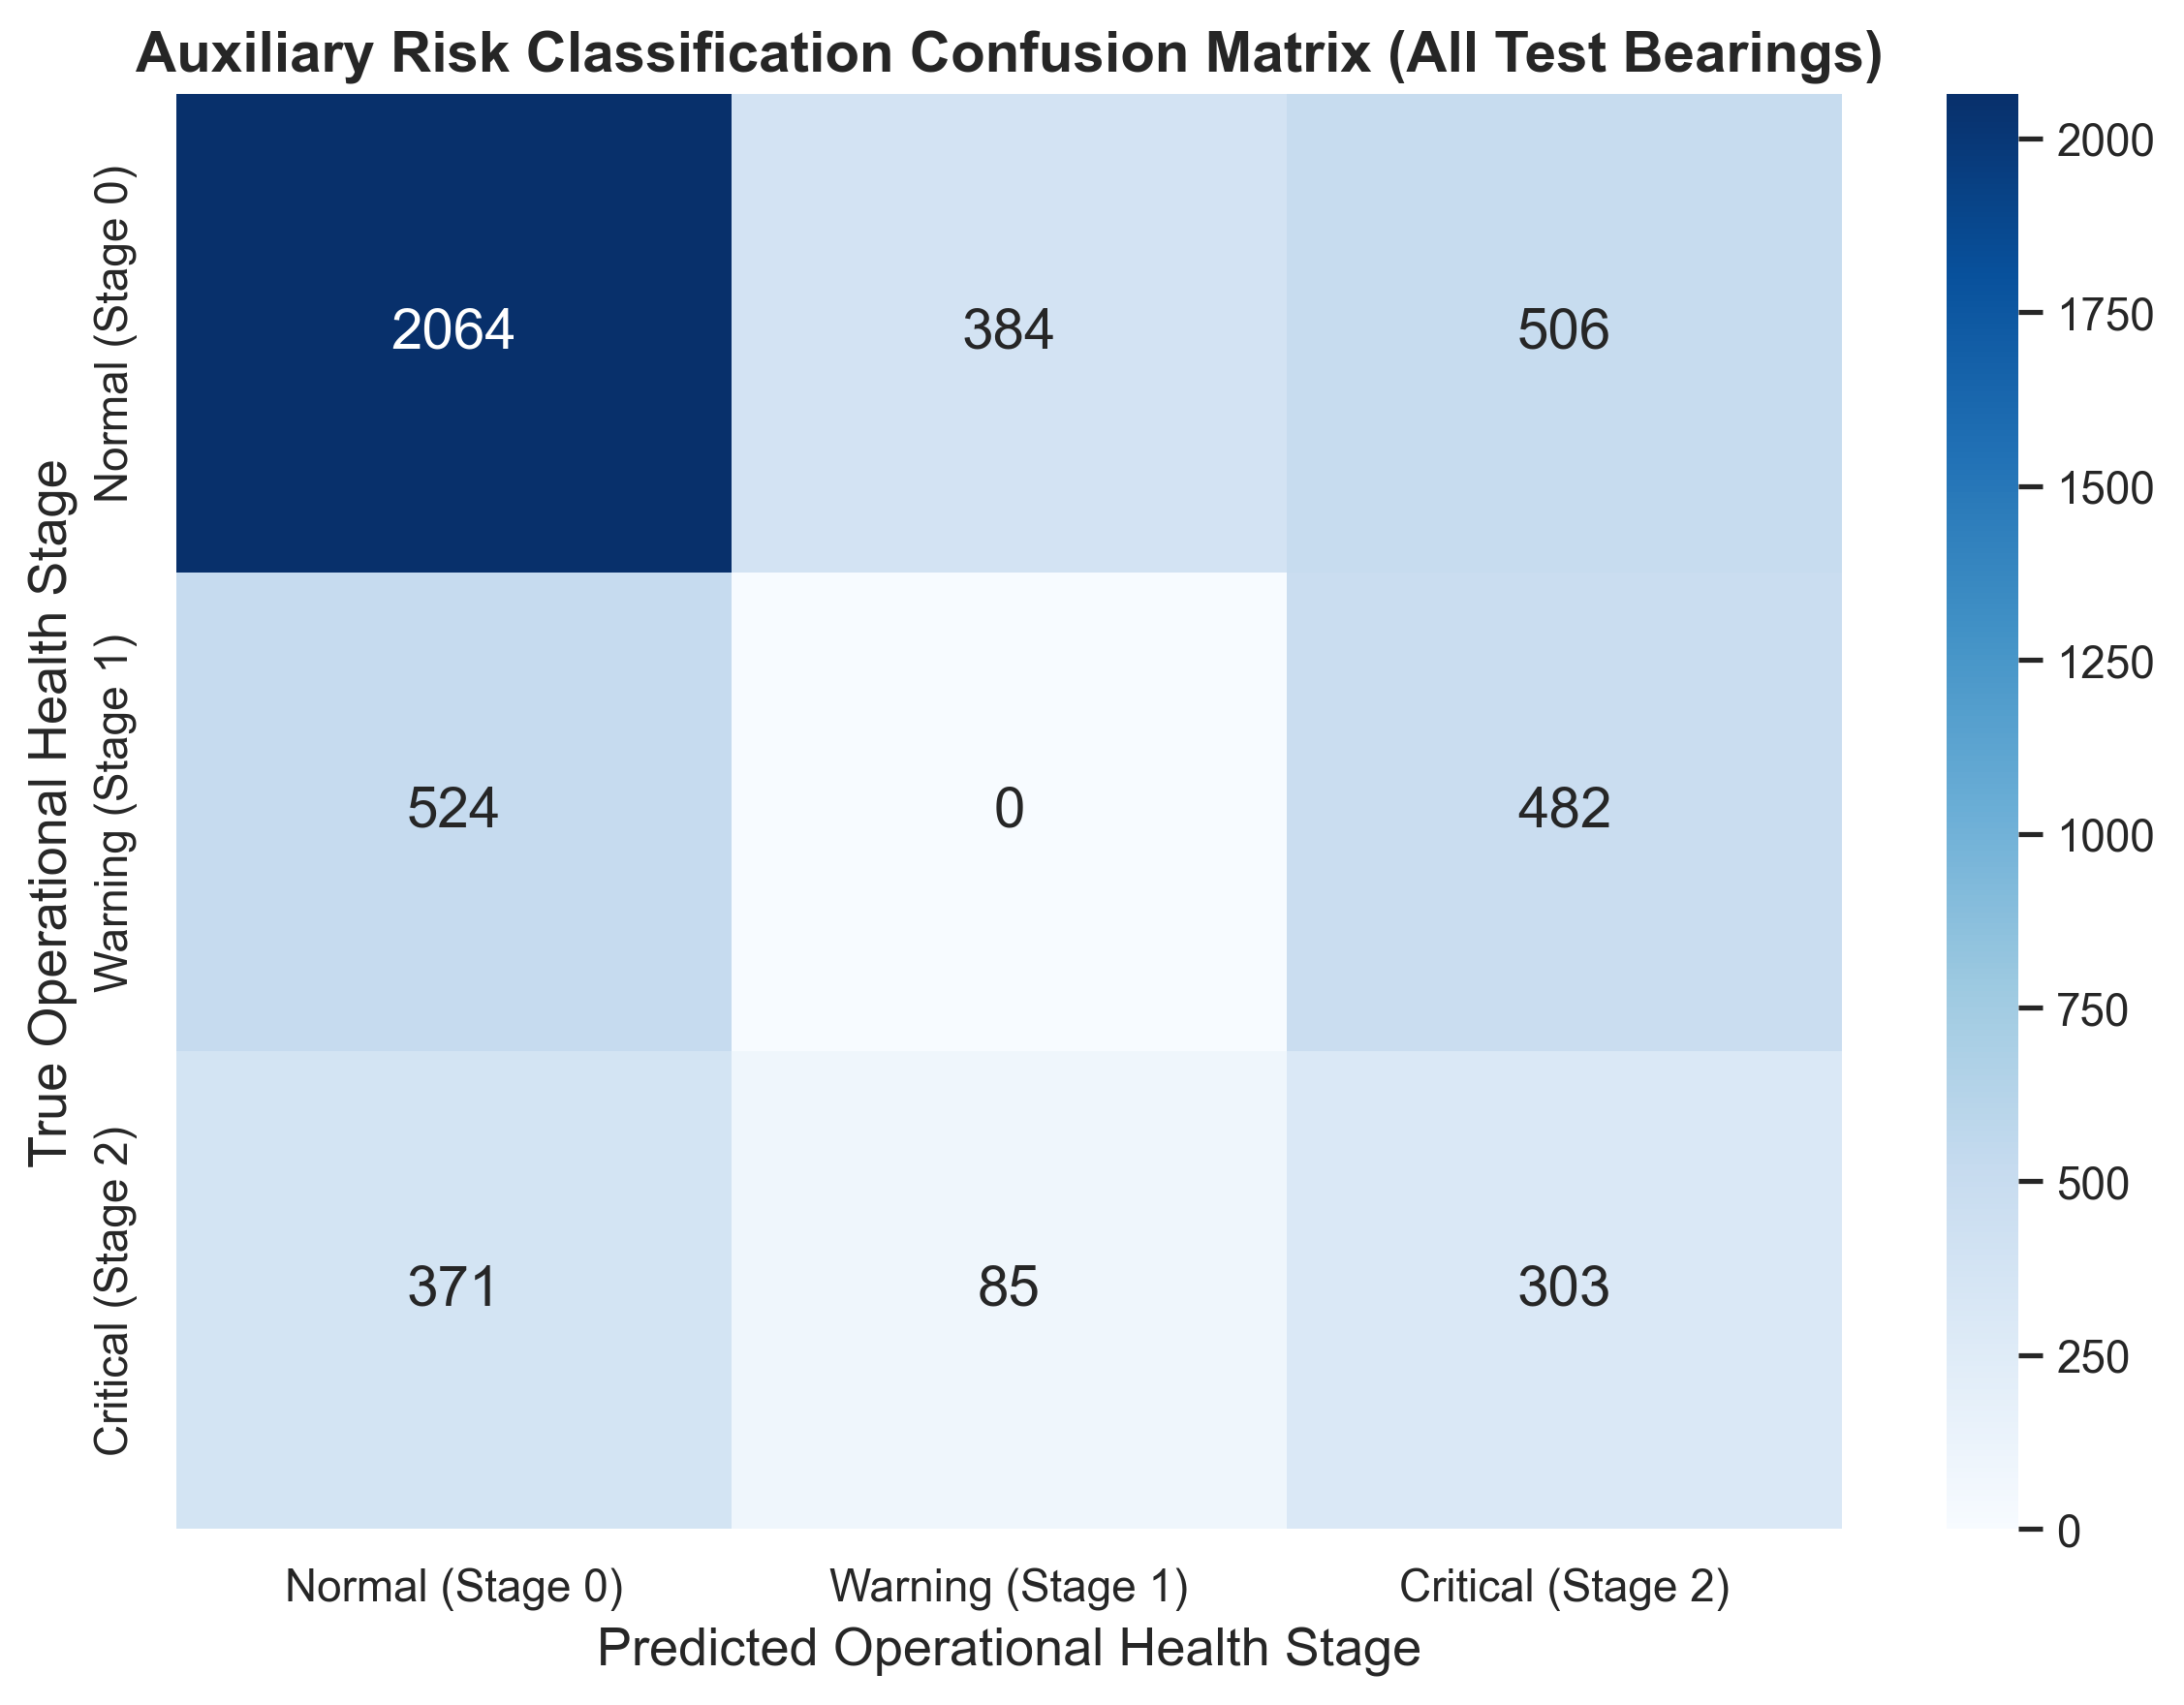

Figure 8 saved to: D:\faisal-VS\faisal project\MA_project\results\figures\fig8_confusion_matrix.png


In [10]:
# ==============================================================================
# 9. EVALUATION METRICS ON HELD-OUT TEST BEARINGS (ZERO TEST-LIFETIME LEAKAGE)
# ==============================================================================
# Model inference on unseen test bearings
test_preds = model.predict(X_test, batch_size=128)
pred_norm_rul = np.clip(test_preds['rul_output'].flatten(), 0.0, 1.0)
pred_risk_prob = test_preds['risk_output']
pred_risk_cls = np.argmax(pred_risk_prob, axis=1)

# ------------------------------------------------------------------------------
# STRICT ZERO-LEAKAGE DE-NORMALIZATION: Uses fixed training constant RUL_CAP_SECONDS
# ------------------------------------------------------------------------------
df_meta_test['pred_norm_rul'] = pred_norm_rul
df_meta_test['pred_rul_s'] = pred_norm_rul * RUL_CAP_SECONDS
df_meta_test['pred_rul_m'] = df_meta_test['pred_rul_s'] / 60.0
df_meta_test['pred_risk_class'] = pred_risk_cls
df_meta_test['prob_normal'] = pred_risk_prob[:, 0]
df_meta_test['prob_warning'] = pred_risk_prob[:, 1]
df_meta_test['prob_critical'] = pred_risk_prob[:, 2]

# RUL Error Metrics (against ground truth capped RUL)
mae_sec = mean_absolute_error(df_meta_test['capped_rul_s'], df_meta_test['pred_rul_s'])
rmse_sec = root_mean_squared_error(df_meta_test['capped_rul_s'], df_meta_test['pred_rul_s'])
mae_min = mae_sec / 60.0
rmse_min = rmse_sec / 60.0
mae_norm = mean_absolute_error(y_rul_test, pred_norm_rul)

# Trajectory-Averaged PHM Prognostic Score
def compute_trajectory_phm_score(actual_capped_rul, predicted_rul):
    scores = []
    for act, pred in zip(actual_capped_rul, predicted_rul):
        if act <= 1e-4:
            continue
        pct_err = 100.0 * (act - pred) / act
        if pct_err <= 0:
            score_i = np.exp(-np.log(0.5) * (pct_err / 5.0))
        else:
            score_i = np.exp(np.log(0.5) * (pct_err / 20.0))
        scores.append(min(1.0, max(0.0, score_i)))
    return float(np.mean(scores)) if scores else 0.0

trajectory_phm_score = compute_trajectory_phm_score(df_meta_test['capped_rul_s'].values, df_meta_test['pred_rul_s'].values)

# Risk Classification Metrics
risk_acc = float(accuracy_score(y_risk_test, pred_risk_cls))
risk_prec, risk_rec, risk_f1, _ = precision_recall_fscore_support(y_risk_test, pred_risk_cls, average='weighted', zero_division=0)
risk_macro_f1 = float(precision_recall_fscore_support(y_risk_test, pred_risk_cls, average='macro', zero_division=0)[2])

eval_results = {
    'RUL_MAE_seconds': float(mae_sec),
    'RUL_MAE_minutes': float(mae_min),
    'RUL_RMSE_seconds': float(rmse_sec),
    'RUL_RMSE_minutes': float(rmse_min),
    'RUL_MAE_normalized': float(mae_norm),
    'Trajectory_Averaged_PHM_Score': float(trajectory_phm_score),
    'Risk_Accuracy': float(risk_acc),
    'Risk_Weighted_Precision': float(risk_prec),
    'Risk_Weighted_Recall': float(risk_rec),
    'Risk_Weighted_F1': float(risk_f1),
    'Risk_Macro_F1': float(risk_macro_f1)
}

# Save metrics JSON & test predictions CSV
with open(os.path.join(RESULTS_DIR, 'evaluation_metrics.json'), 'w') as f:
    json.dump(eval_results, f, indent=2)
df_meta_test.to_csv(os.path.join(RESULTS_DIR, 'test_predictions.csv'), index=False)

print("=" * 70)
print("PROPOSED MODEL EVALUATION SUMMARY (UNSEEN TEST BEARINGS - ZERO LEAKAGE)")
print("=" * 70)
for k, v in eval_results.items():
    print(f"  {k:30s}: {v:.4f}")
print("=" * 70)

# FIGURE 8: Confusion Matrix Heatmap
cm = confusion_matrix(y_risk_test, pred_risk_cls)
stage_names = ['Normal (Stage 0)', 'Warning (Stage 1)', 'Critical (Stage 2)']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=stage_names, yticklabels=stage_names, ax=ax, annot_kws={'size': 14})
ax.set_title('Auxiliary Risk Classification Confusion Matrix (All Test Bearings)', fontweight='bold')
ax.set_xlabel('Predicted Operational Health Stage')
ax.set_ylabel('True Operational Health Stage')
plt.tight_layout()
fig8_path = os.path.join(FIGURES_DIR, 'fig8_confusion_matrix.png')
fig.savefig(fig8_path, dpi=300)
plt.show()

print(f"Figure 8 saved to: {fig8_path}")


## 10. Degradation Trajectory, Residual Errors & Dynamic Risk Progression

### Tracking Bearing Health Through Time
To demonstrate practical industrial deployment, we track the entire degradation trajectory of held-out `Bearing1_3`:
1. **Actual vs Predicted Capped RUL Curve**: Validates monotonic RUL descent towards zero.
2. **Prediction Residuals**: Evaluates error distribution throughout operation.
3. **Dynamic Probability Progression**: Tracks how class probabilities transition from `Normal` ($P \to 1$) to `Warning` to `Critical` ($P \to 1$).

> **In simple words:** the plots show one whole bearing life: the black dashed line is the truth, the blue line the model's estimate, and how the stage probabilities change over time.


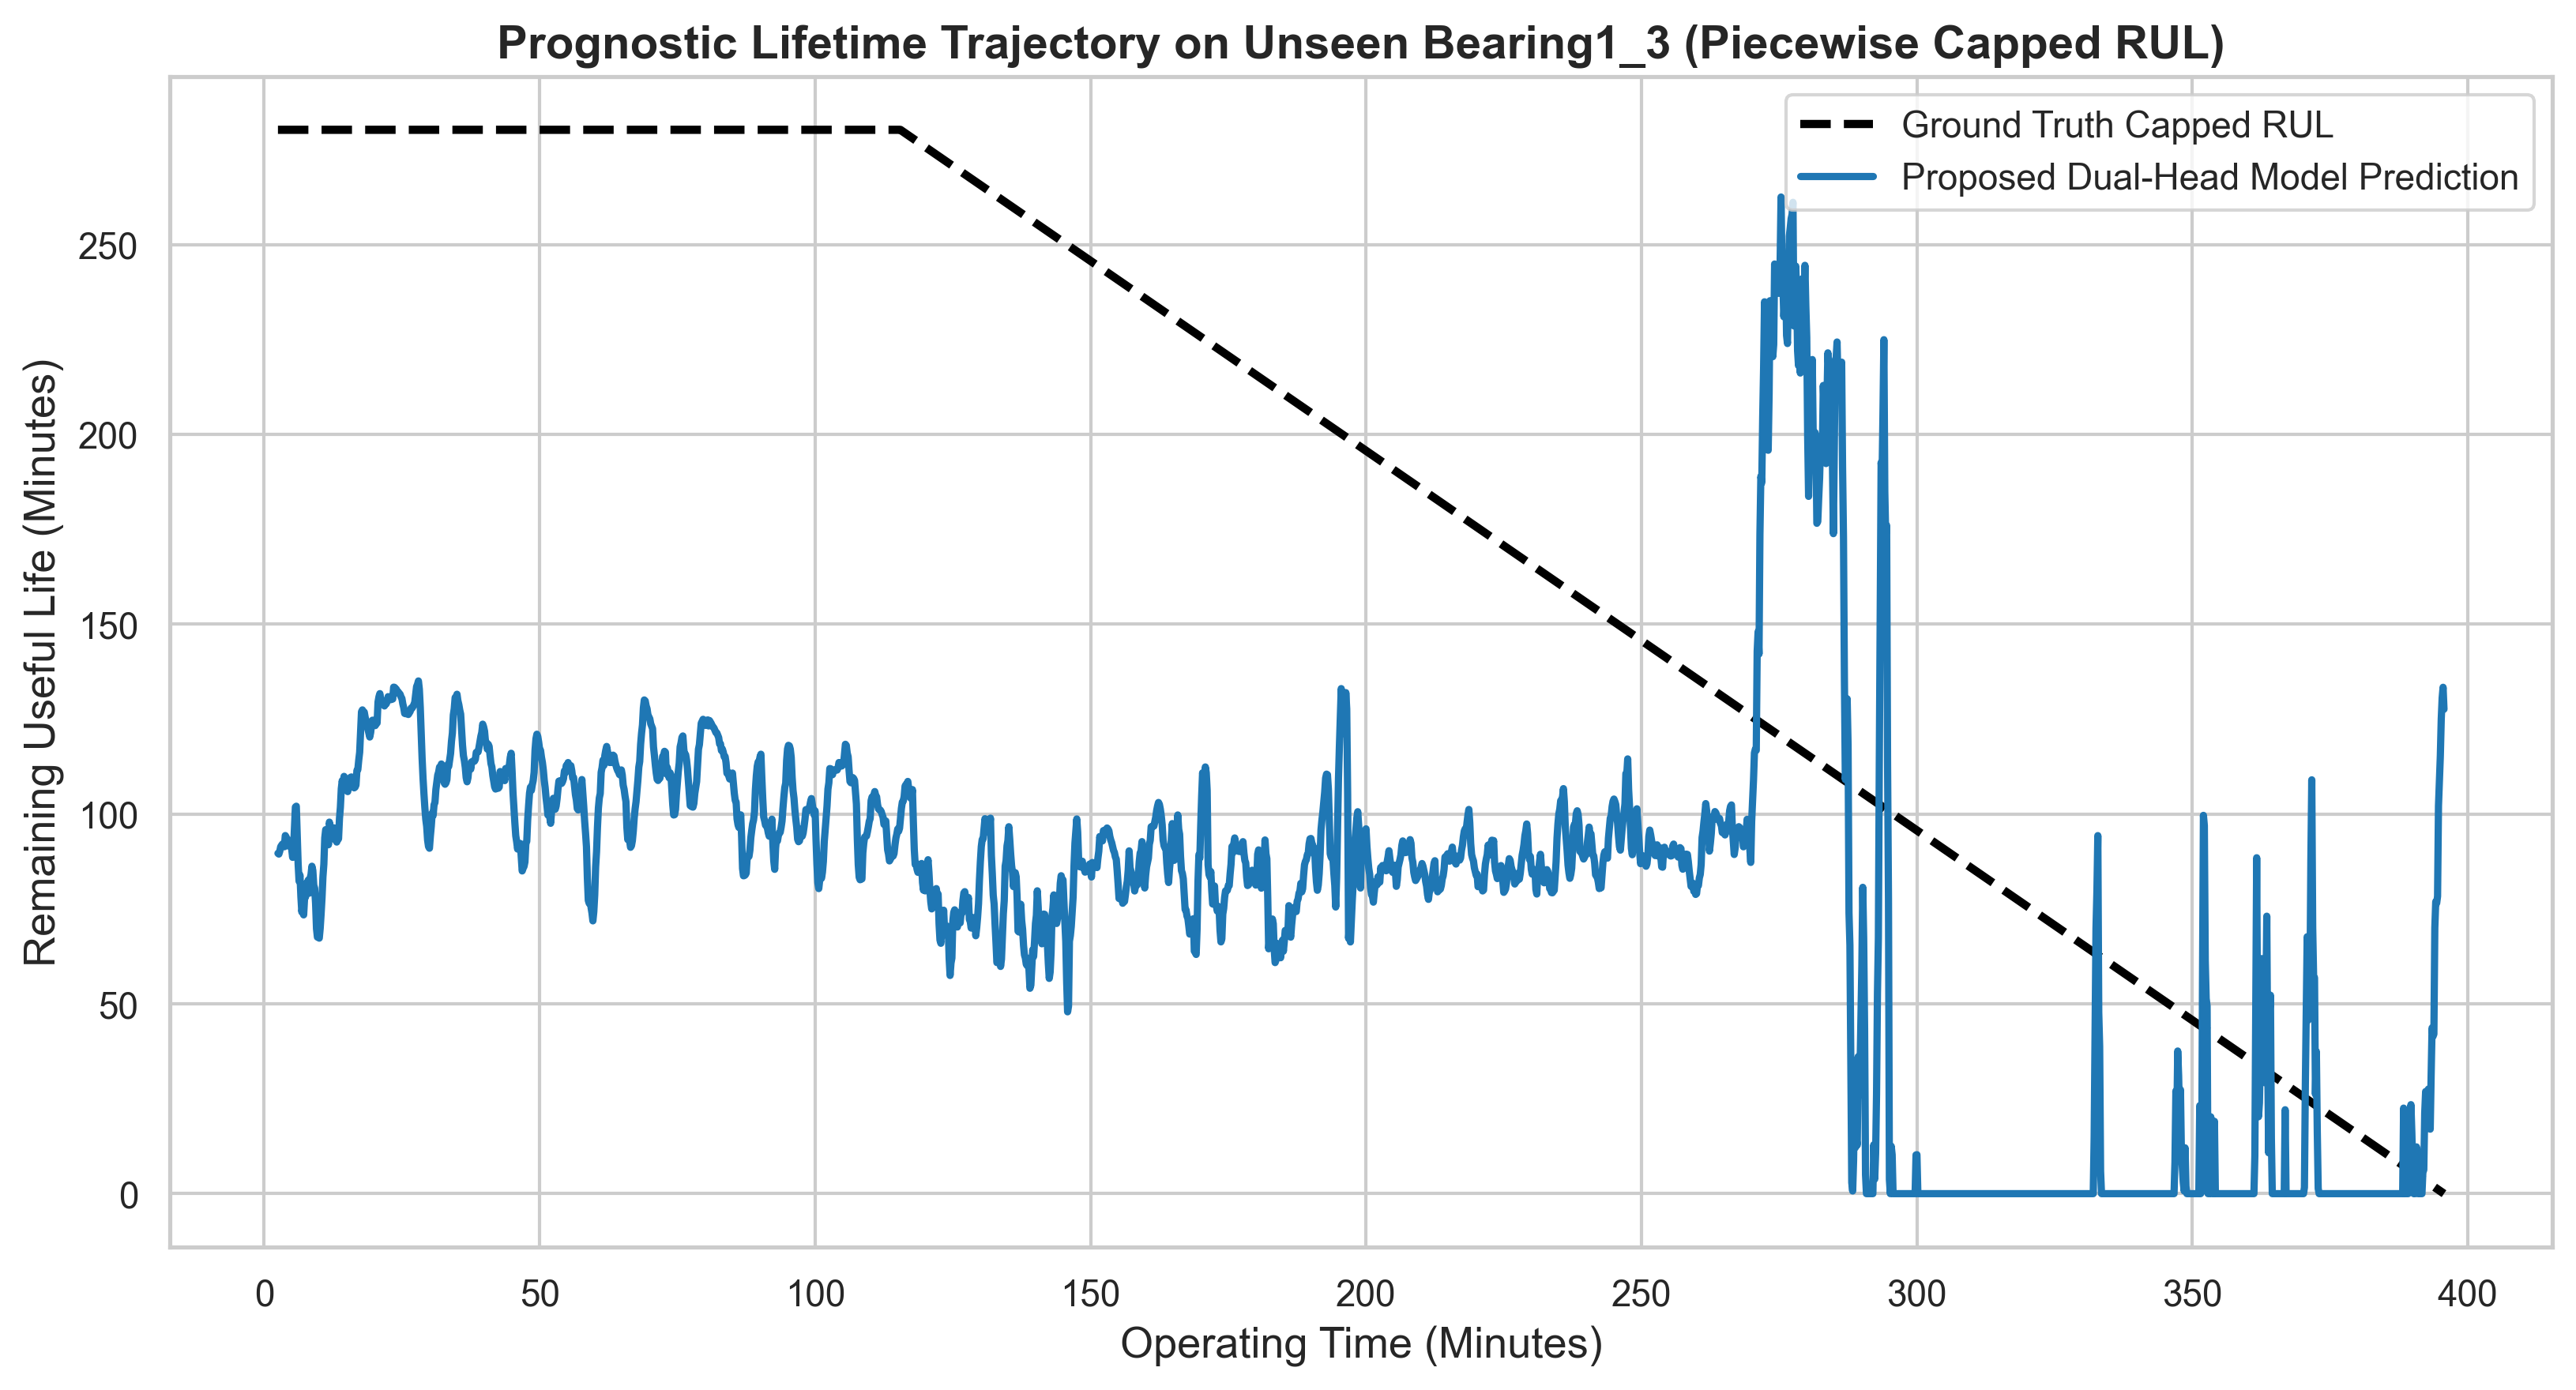

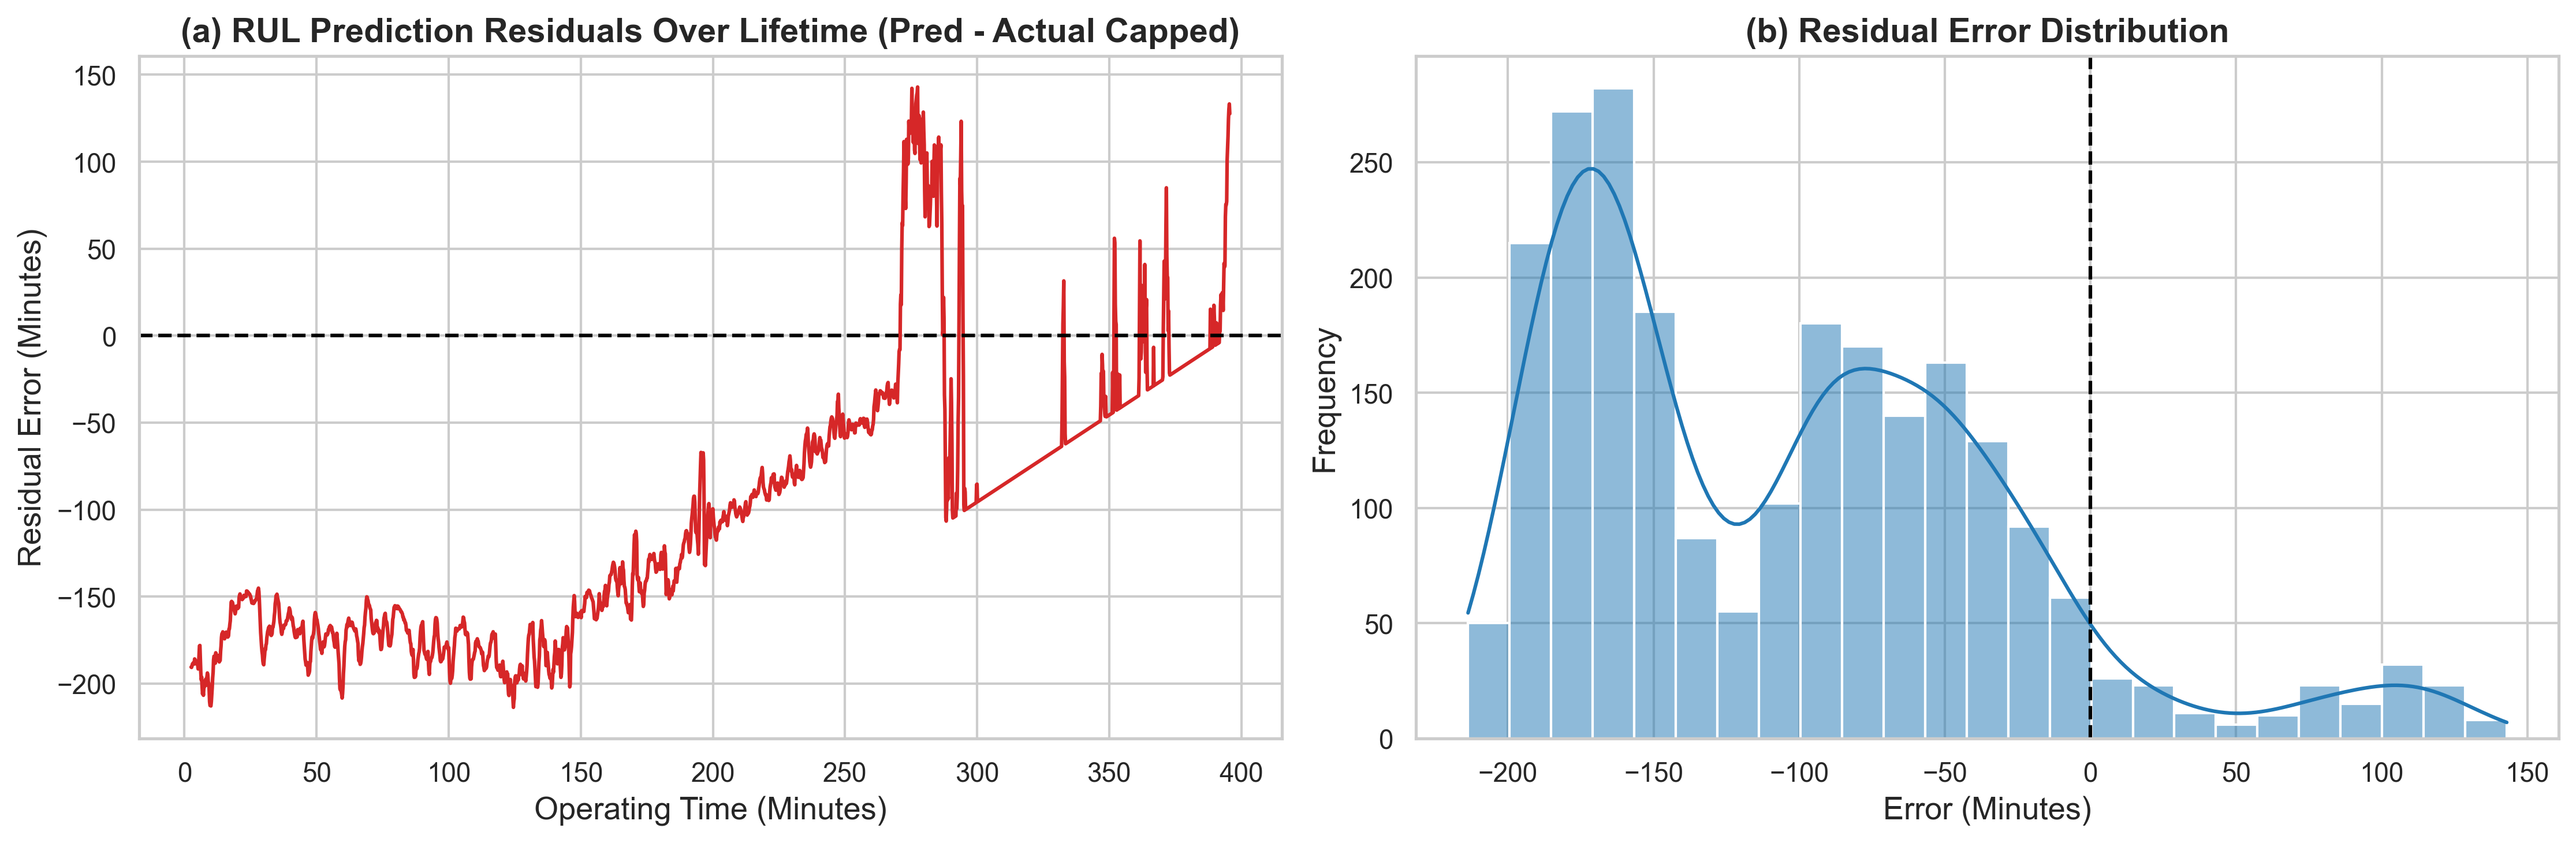

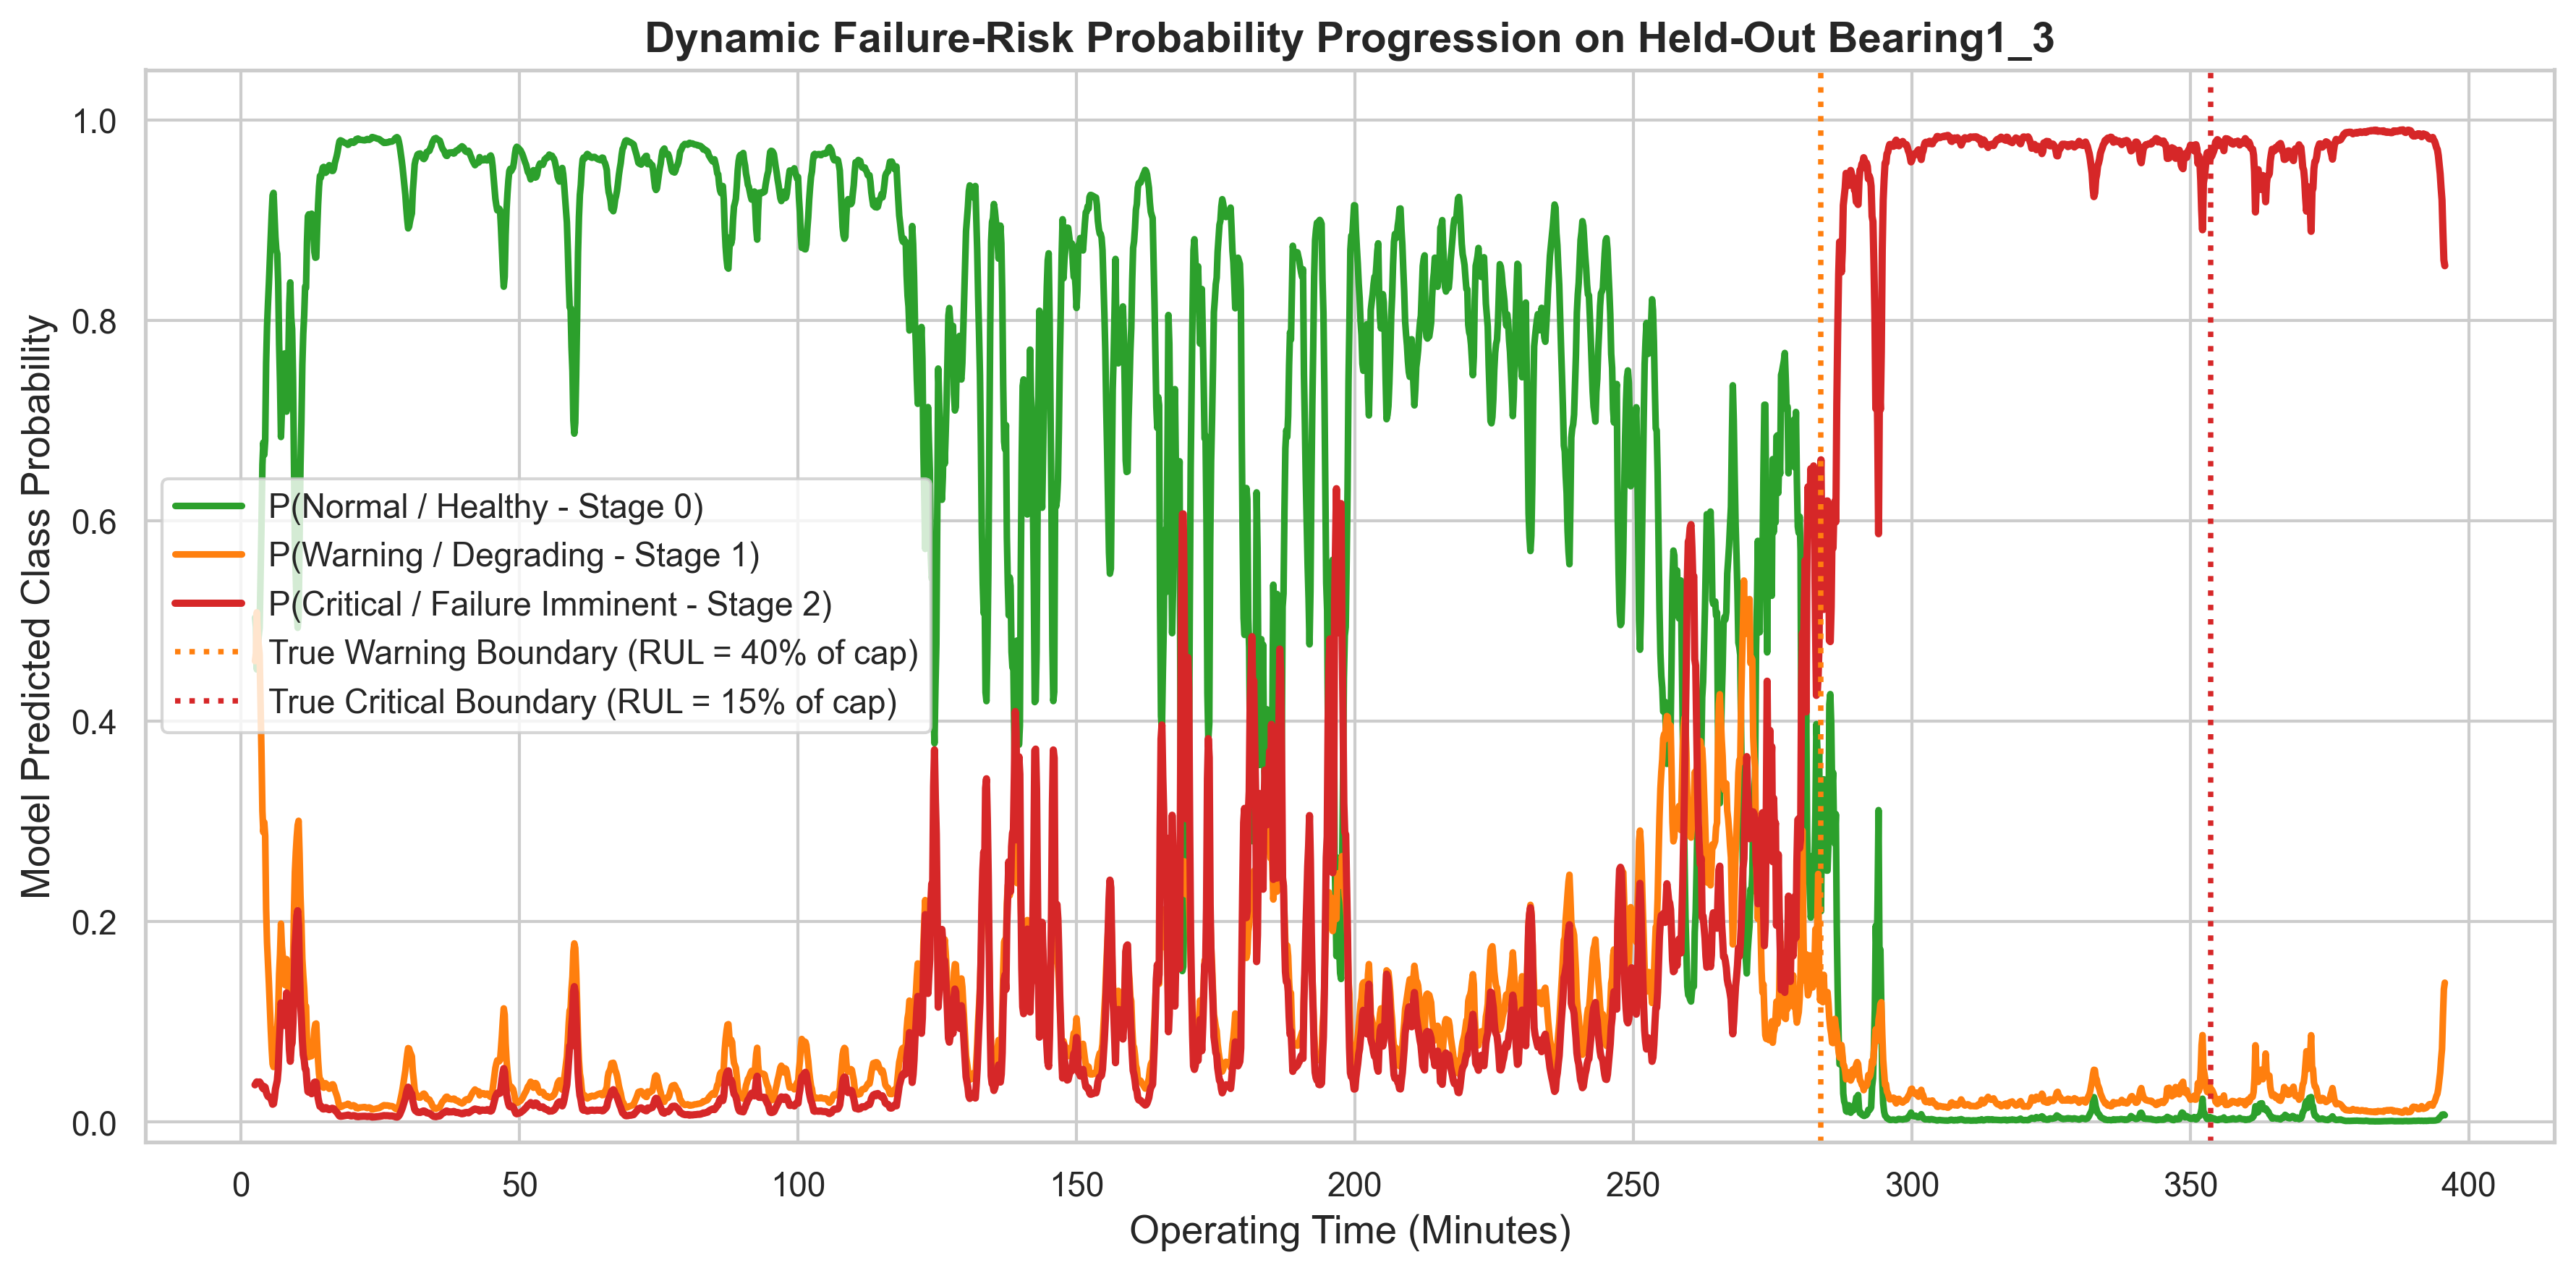

In [11]:
# ==============================================================================
# 10. PROGNOSTIC TRAJECTORY, RESIDUALS & DYNAMIC PROBABILITIES
# ==============================================================================
b_test = df_meta_test[df_meta_test['bearing'] == 'Bearing1_3'].sort_values('snapshot_idx')

# FIGURE 5: Actual vs Predicted Capped RUL Trajectory
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(b_test['operating_time_m'], b_test['capped_rul_m'], color='black', lw=2.5, linestyle='--', label='Ground Truth Capped RUL')
ax.plot(b_test['operating_time_m'], b_test['pred_rul_m'], color='#1f77b4', lw=2.2, label='Proposed Dual-Head Model Prediction')
ax.set_title('Prognostic Lifetime Trajectory on Unseen Bearing1_3 (Piecewise Capped RUL)', fontweight='bold')
ax.set_xlabel('Operating Time (Minutes)')
ax.set_ylabel('Remaining Useful Life (Minutes)')
ax.legend(loc='upper right')
plt.tight_layout()
fig5_path = os.path.join(FIGURES_DIR, 'fig5_rul_actual_vs_predicted.png')
fig.savefig(fig5_path, dpi=300)
plt.show()

# FIGURE 6: Residual Error Analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
residuals = b_test['pred_rul_m'] - b_test['capped_rul_m']

ax1.plot(b_test['operating_time_m'], residuals, color='#d62728', lw=1.5)
ax1.axhline(0, color='black', linestyle='--')
ax1.set_title('(a) RUL Prediction Residuals Over Lifetime (Pred - Actual Capped)', fontweight='bold')
ax1.set_xlabel('Operating Time (Minutes)')
ax1.set_ylabel('Residual Error (Minutes)')

sns.histplot(residuals, kde=True, ax=ax2, color='#1f77b4', bins=25)
ax2.axvline(0, color='black', linestyle='--')
ax2.set_title('(b) Residual Error Distribution', fontweight='bold')
ax2.set_xlabel('Error (Minutes)')
ax2.set_ylabel('Frequency')

plt.tight_layout()
fig6_path = os.path.join(FIGURES_DIR, 'fig6_rul_residuals_error.png')
fig.savefig(fig6_path, dpi=300)
plt.show()

# FIGURE 7: Dynamic Health Risk Probability Progression
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(b_test['operating_time_m'], b_test['prob_normal'], color='#2ca02c', lw=2.2, label='P(Normal / Healthy - Stage 0)')
ax.plot(b_test['operating_time_m'], b_test['prob_warning'], color='#ff7f0e', lw=2.2, label='P(Warning / Degrading - Stage 1)')
ax.plot(b_test['operating_time_m'], b_test['prob_critical'], color='#d62728', lw=2.4, label='P(Critical / Failure Imminent - Stage 2)')

# True stage boundaries come from the ground-truth labels (first window labelled Warning / Critical)
t_warn = b_test.loc[b_test['health_stage'] >= 1, 'operating_time_m'].iloc[0]
t_crit = b_test.loc[b_test['health_stage'] >= 2, 'operating_time_m'].iloc[0]
ax.axvline(t_warn, color='#ff7f0e', linestyle=':', lw=1.8, label='True Warning Boundary (RUL = 40% of cap)')
ax.axvline(t_crit, color='#d62728', linestyle=':', lw=1.8, label='True Critical Boundary (RUL = 15% of cap)')

ax.set_title('Dynamic Failure-Risk Probability Progression on Held-Out Bearing1_3', fontweight='bold')
ax.set_xlabel('Operating Time (Minutes)')
ax.set_ylabel('Model Predicted Class Probability')
ax.set_ylim(-0.02, 1.05)
ax.legend(loc='center left')
plt.tight_layout()
fig7_path = os.path.join(FIGURES_DIR, 'fig7_failure_risk_probabilities.png')
fig.savefig(fig7_path, dpi=300)
plt.show()


## 11. Model Explainability via Temporal Attention Weights

### Interpreting the model's decisions
Deep networks are often called black boxes. Our **Temporal Attention Layer** produces one weight $\alpha_t$ per time step (they sum to 1), showing which of the 16 recordings the model relied on for a prediction.
- It explains **which time steps** mattered, not which features (feature importance is in Section 15).
- Attention shows what the *model* used; it is not proof of physical cause.
- Instead of assuming how attention behaves, Section 11b and Section 15 **measure** it (average profile per true health stage, entropy, weight on the most recent steps).

> **In simple words:** the bars show how much the model 'looked at' each of the last 16 recordings.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


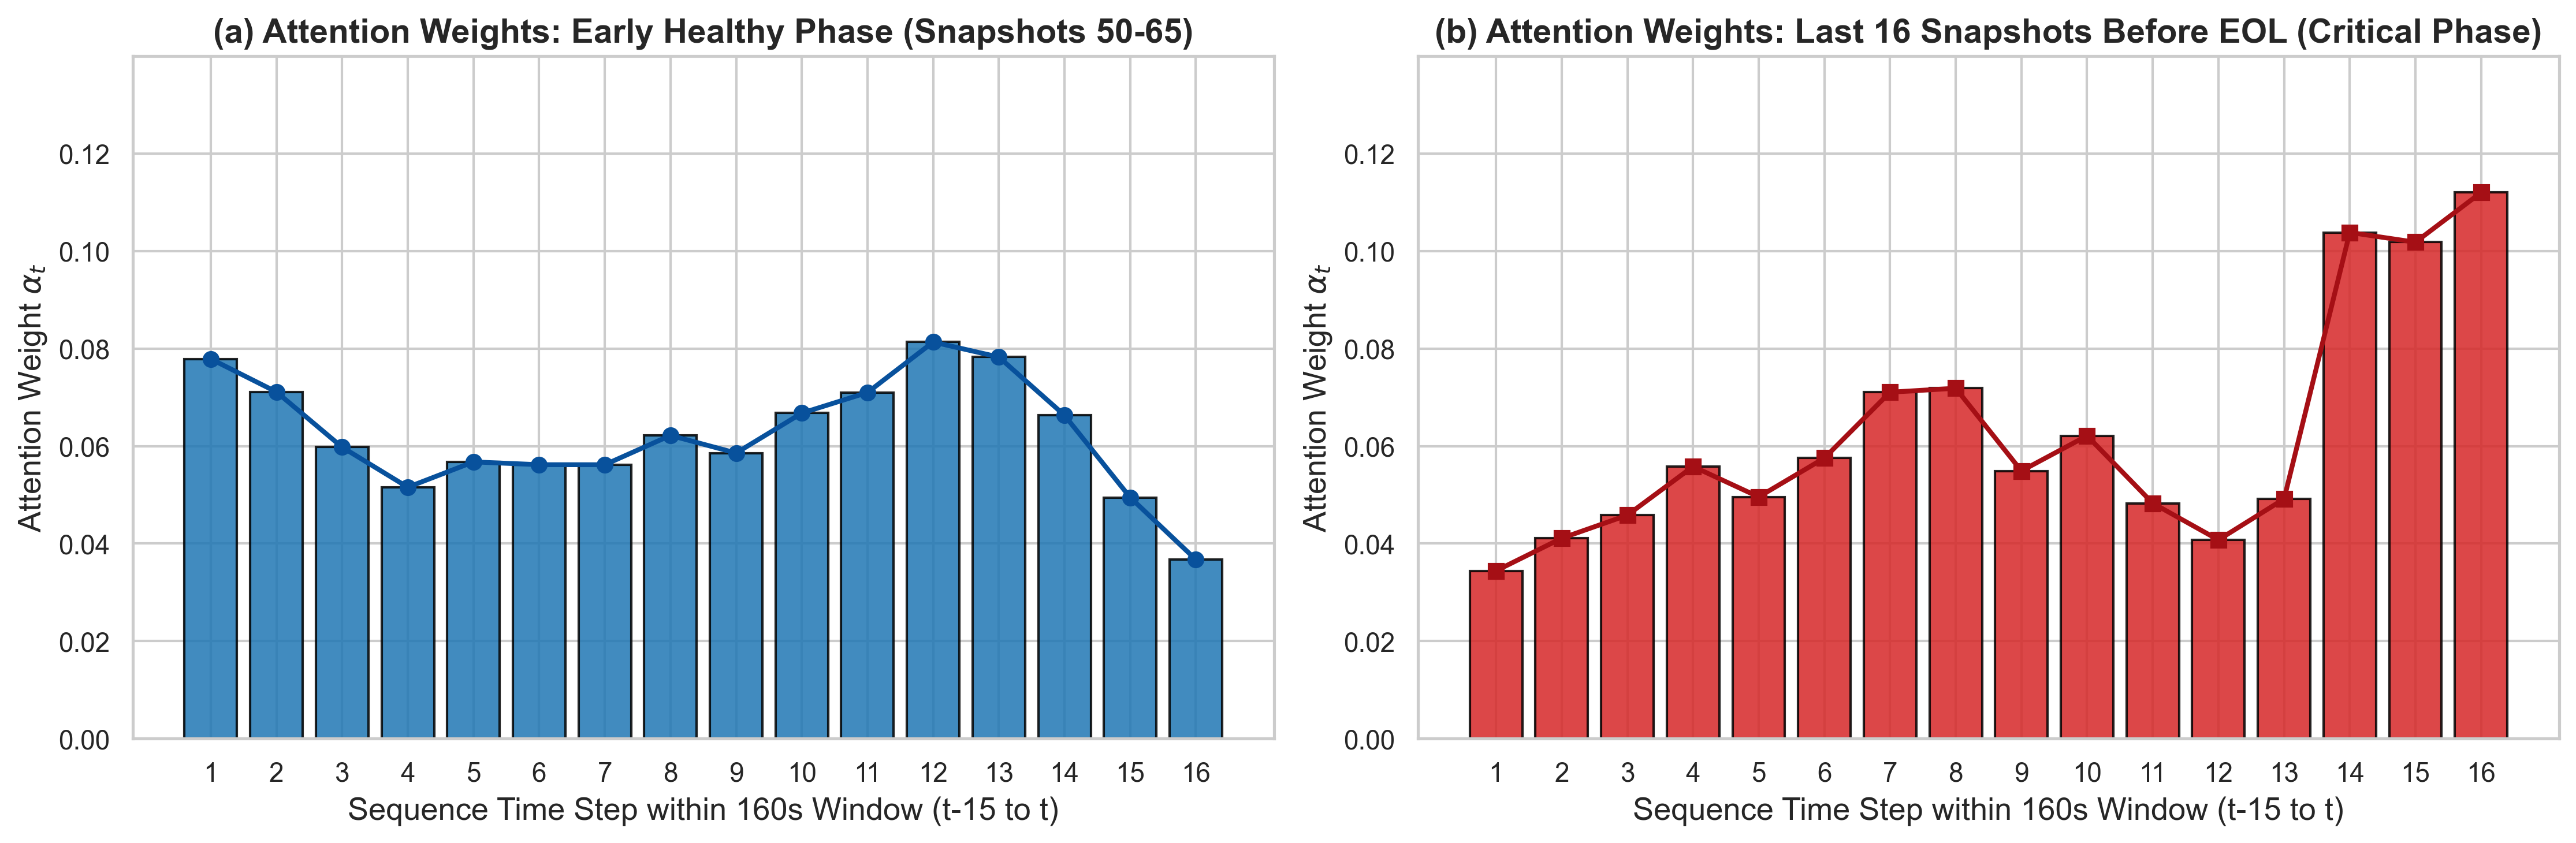

Figure 9 saved to: D:\faisal-VS\faisal project\MA_project\results\figures\fig9_temporal_attention_weights.png
Healthy attention peak: step 12 (weight = 0.0813)
Critical attention peak: step 16 (weight = 0.1120)


In [12]:
# ==============================================================================
# 11. TEMPORAL ATTENTION WEIGHTS EXPLAINABILITY
# ==============================================================================
# Create explainability submodel extracting attention weights
attn_submodel = Model(
    inputs=model.input,
    outputs=model.get_layer('temporal_attention').output[1]
)

# Extract test sequences for early healthy phase (snapshot 50) and critical phase (final snapshot)
b1_3_feats = df_features[df_features['bearing'] == 'Bearing1_3'].sort_values('snapshot_idx').reset_index(drop=True)
b1_3_scaled = scaler.transform(b1_3_feats[feature_columns])

seq_healthy  = b1_3_scaled[50 : 50 + WINDOW_SIZE][np.newaxis, ...]
seq_critical = b1_3_scaled[-WINDOW_SIZE :][np.newaxis, ...]

attn_healthy  = attn_submodel.predict(seq_healthy)[0].flatten()
attn_critical = attn_submodel.predict(seq_critical)[0].flatten()

# FIGURE 9: Temporal Attention Weights Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
steps = np.arange(1, WINDOW_SIZE + 1)

# Healthy attention
ax1.bar(steps, attn_healthy, color='#1f77b4', alpha=0.85, edgecolor='black')
ax1.plot(steps, attn_healthy, color='#08519c', marker='o', lw=2)
ax1.set_title('(a) Attention Weights: Early Healthy Phase (Snapshots 50-65)', fontweight='bold')
ax1.set_xlabel('Sequence Time Step within 160s Window (t-15 to t)')
ax1.set_ylabel('Attention Weight $\\alpha_t$')
ax1.set_xticks(steps)
ax1.set_ylim(0, max(np.max(attn_healthy), np.max(attn_critical)) * 1.25)

# Critical attention
ax2.bar(steps, attn_critical, color='#d62728', alpha=0.85, edgecolor='black')
ax2.plot(steps, attn_critical, color='#a50f15', marker='s', lw=2)
ax2.set_title('(b) Attention Weights: Last 16 Snapshots Before EOL (Critical Phase)', fontweight='bold')
ax2.set_xlabel('Sequence Time Step within 160s Window (t-15 to t)')
ax2.set_ylabel('Attention Weight $\\alpha_t$')
ax2.set_xticks(steps)
ax2.set_ylim(0, max(np.max(attn_healthy), np.max(attn_critical)) * 1.25)

plt.tight_layout()
fig9_path = os.path.join(FIGURES_DIR, 'fig9_temporal_attention_weights.png')
fig.savefig(fig9_path, dpi=300)
plt.show()

print(f"Figure 9 saved to: {fig9_path}")
print(f"Healthy attention peak: step {np.argmax(attn_healthy)+1} (weight = {np.max(attn_healthy):.4f})")
print(f"Critical attention peak: step {np.argmax(attn_critical)+1} (weight = {np.max(attn_critical):.4f})")


> Figure 9 shows two single windows. **Section 15 averages the attention over all test windows per true health stage** (with entropy and weight on the newest steps) so the conclusion does not rest on two hand-picked examples.

## 12. Real-Time Industrial Health Decision Dashboard

### Operational Asset Monitoring & Maintenance Scheduling
In practical plant monitoring, operators require:
1. Current estimated RUL in minutes and hours (de-normalized strictly using training constants).
2. Immediate risk classification (`NORMAL`, `WARNING`, `CRITICAL`).
3. Explicit operational advisories for maintenance dispatch.

The dashboard below renders a decision interface evaluating the held-out bearing asset.

> **In simple words:** this is how an operator would see the result: current estimate, alarm level and advice. The dashboard also prints the *true* RUL beside the prediction so any error is visible.


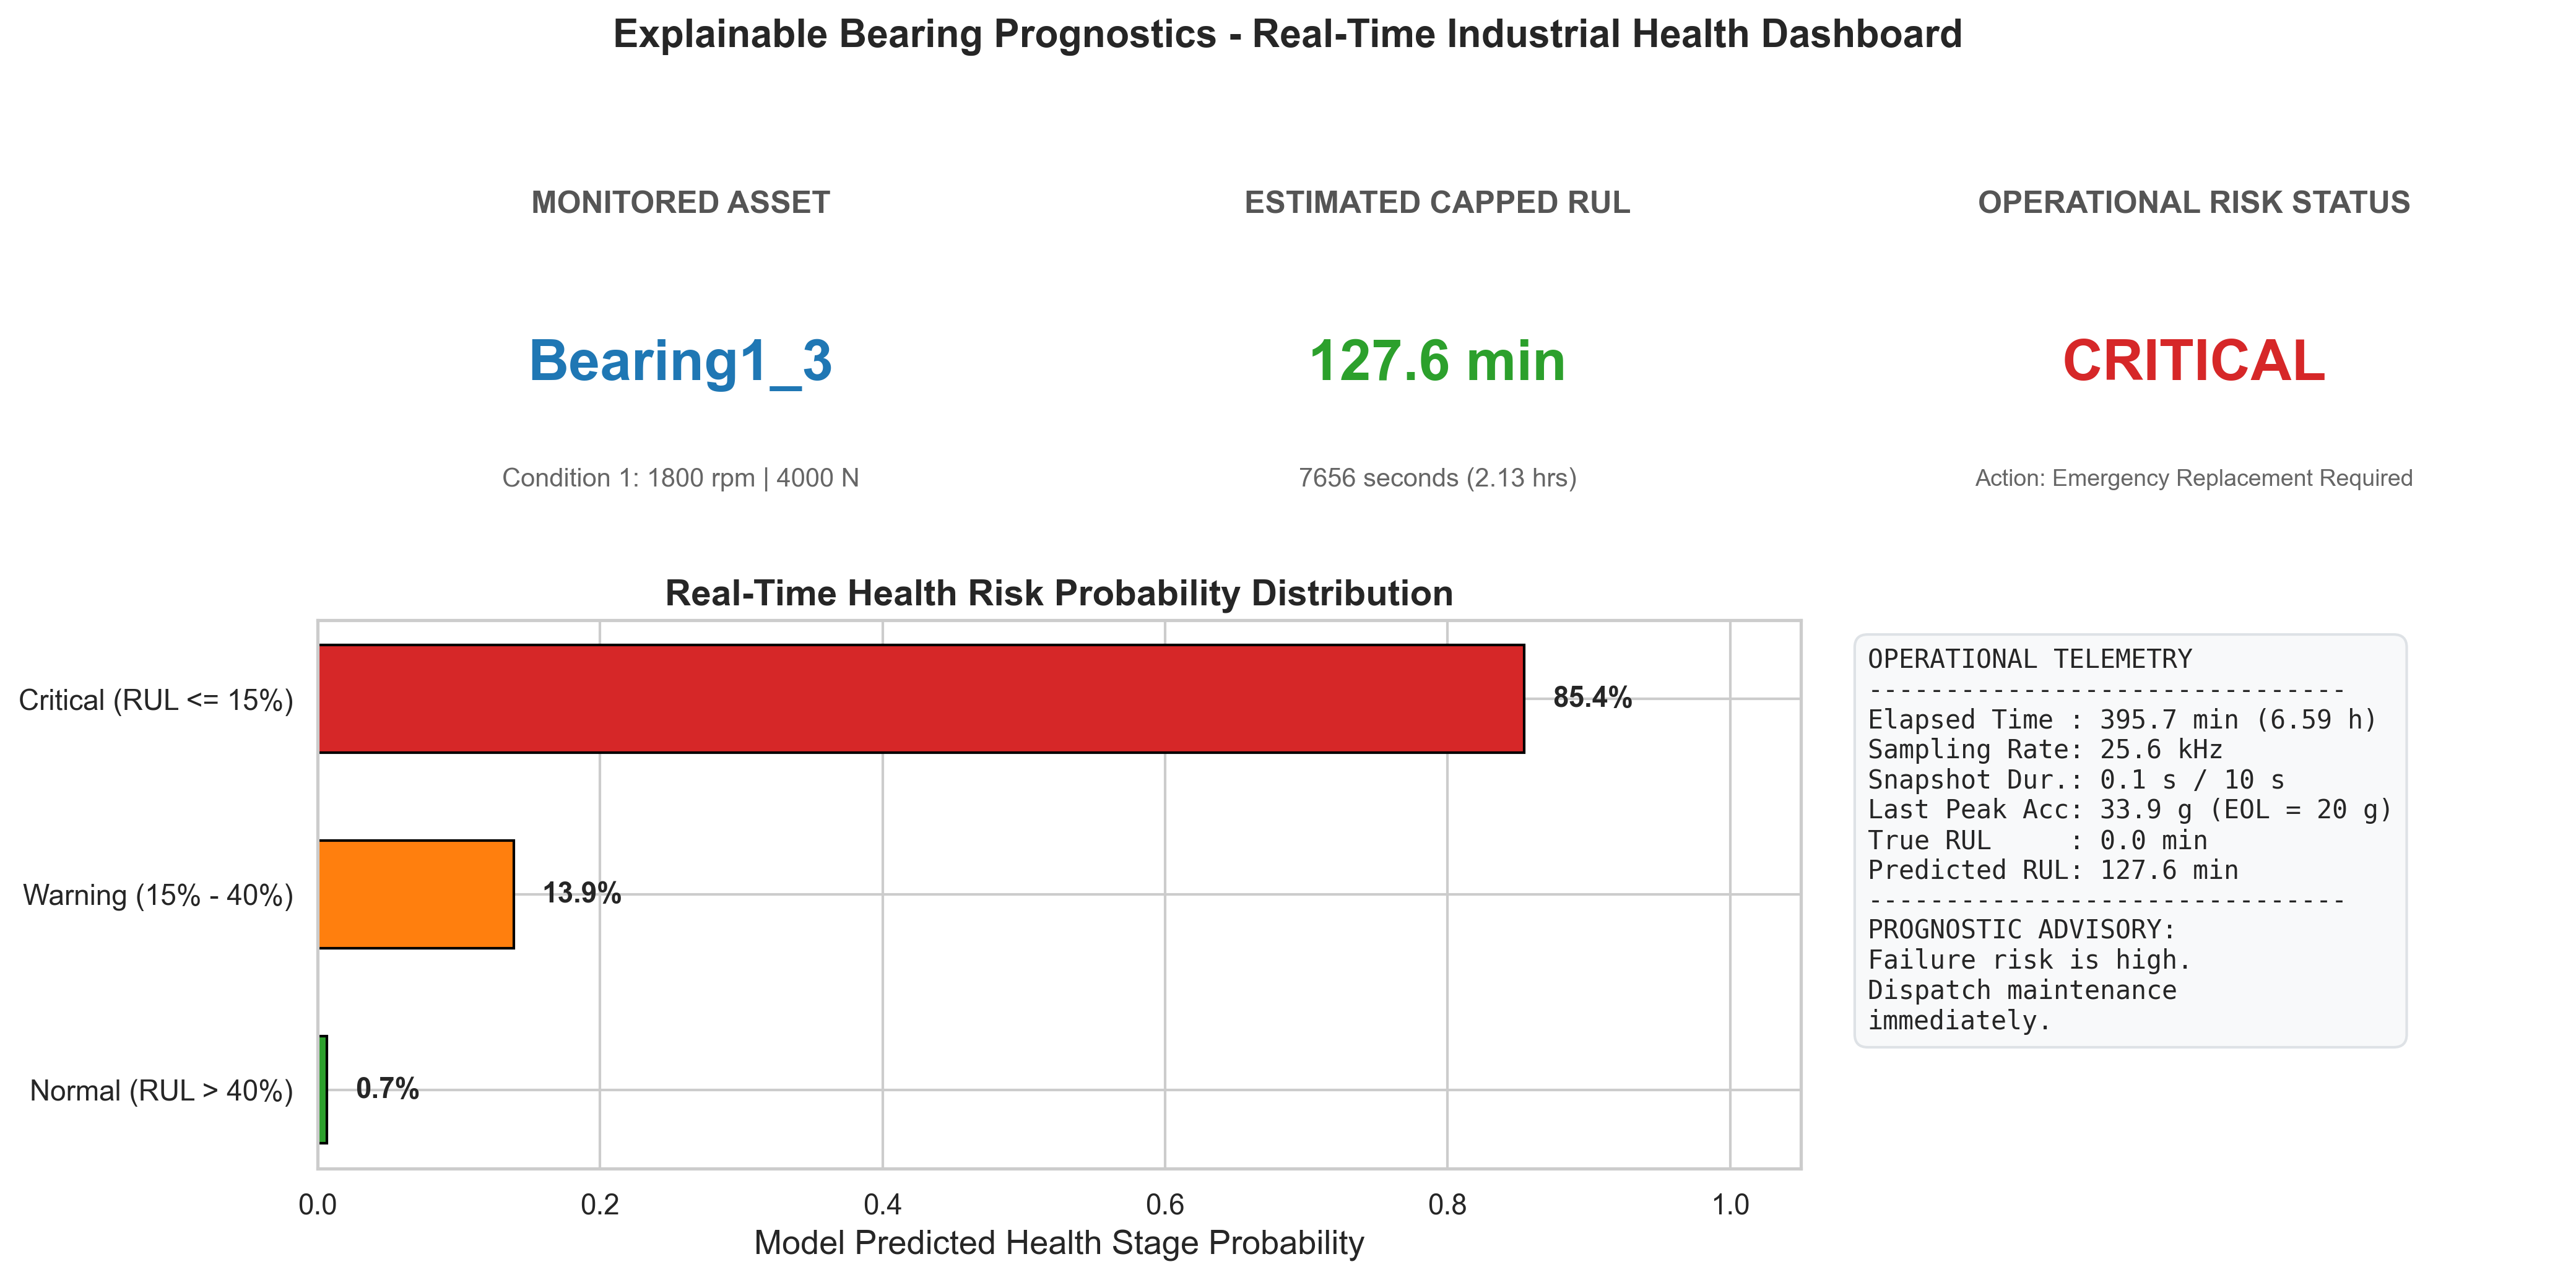

Figure 10 saved to: D:\faisal-VS\faisal project\MA_project\results\figures\fig10_industrial_decision_dashboard.png


In [13]:
# ==============================================================================
# 12. INDUSTRIAL HEALTH PROGNOSTICS DECISION DASHBOARD
# ==============================================================================
latest_idx = -1 # Latest operational snapshot
cur_bearing = 'Bearing1_3'
cur_time_m = b_test['operating_time_m'].iloc[latest_idx]
cur_rul_m = b_test['pred_rul_m'].iloc[latest_idx]
cur_rul_s = b_test['pred_rul_s'].iloc[latest_idx]
cur_p_norm = b_test['prob_normal'].iloc[latest_idx]
cur_p_warn = b_test['prob_warning'].iloc[latest_idx]
cur_p_crit = b_test['prob_critical'].iloc[latest_idx]
cur_stage = b_test['pred_risk_class'].iloc[latest_idx]
cur_peak = df_features[df_features['bearing'] == cur_bearing].sort_values('snapshot_idx')['horiz_peak'].iloc[latest_idx]
true_rul_m = b_test['capped_rul_m'].iloc[latest_idx]
cur_speed, cur_load, cur_cond = operating_conditions_map[cur_bearing]
advisory = {0: 'Operating normally.\nContinue routine\nmonitoring.',
            1: 'Degradation detected.\nSchedule inspection\nsoon.',
            2: 'Failure risk is high.\nDispatch maintenance\nimmediately.'}[int(cur_stage)]

# FIGURE 10: Industrial Decision Dashboard
fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.2])

# Card 1: Asset Info
ax_card1 = fig.add_subplot(gs[0, 0])
ax_card1.axis('off')
ax_card1.text(0.5, 0.75, 'MONITORED ASSET', ha='center', va='center', fontsize=12, fontweight='bold', color='#555')
ax_card1.text(0.5, 0.40, f'{cur_bearing}', ha='center', va='center', fontsize=22, fontweight='bold', color='#1f77b4')
ax_card1.text(0.5, 0.15, f'Condition {cur_cond}: {cur_speed} rpm | {cur_load} N', ha='center', va='center', fontsize=10, color='#666')
ax_card1.patch.set_facecolor('#f0f4f8')
ax_card1.patch.set_edgecolor('#c0d0e0')

# Card 2: Estimated RUL
ax_card2 = fig.add_subplot(gs[0, 1])
ax_card2.axis('off')
ax_card2.text(0.5, 0.75, 'ESTIMATED CAPPED RUL', ha='center', va='center', fontsize=12, fontweight='bold', color='#555')
rul_color = '#d62728' if cur_rul_m < 30 else ('#ff7f0e' if cur_rul_m < 90 else '#2ca02c')
ax_card2.text(0.5, 0.40, f'{cur_rul_m:.1f} min', ha='center', va='center', fontsize=22, fontweight='bold', color=rul_color)
ax_card2.text(0.5, 0.15, f'{cur_rul_s:.0f} seconds ({cur_rul_m/60.0:.2f} hrs)', ha='center', va='center', fontsize=10, color='#666')
ax_card2.patch.set_facecolor('#fdf0f0' if cur_rul_m < 30 else '#f0fdf4')

# Card 3: Health Risk Stage
ax_card3 = fig.add_subplot(gs[0, 2])
ax_card3.axis('off')
ax_card3.text(0.5, 0.75, 'OPERATIONAL RISK STATUS', ha='center', va='center', fontsize=12, fontweight='bold', color='#555')
status_str = 'CRITICAL' if cur_stage == 2 else ('WARNING' if cur_stage == 1 else 'NORMAL')
status_col = '#d62728' if cur_stage == 2 else ('#ff7f0e' if cur_stage == 1 else '#2ca02c')
ax_card3.text(0.5, 0.40, status_str, ha='center', va='center', fontsize=22, fontweight='bold', color=status_col)
action_str = 'Action: Emergency Replacement Required' if cur_stage == 2 else ('Action: Schedule Inspection' if cur_stage == 1 else 'Action: Normal Operation')
ax_card3.text(0.5, 0.15, action_str, ha='center', va='center', fontsize=9, color='#666')

# Probability Distribution Bar Chart
ax_bar = fig.add_subplot(gs[1, 0:2])
stages = ['Normal (RUL > 40%)', 'Warning (15% - 40%)', 'Critical (RUL <= 15%)']
probs = [cur_p_norm, cur_p_warn, cur_p_crit]
bar_colors = ['#2ca02c', '#ff7f0e', '#d62728']
bars = ax_bar.barh(stages, probs, color=bar_colors, edgecolor='black', height=0.55)
ax_bar.set_xlim(0, 1.05)
ax_bar.set_xlabel('Model Predicted Health Stage Probability')
ax_bar.set_title('Real-Time Health Risk Probability Distribution', fontweight='bold')
for bar, p in zip(bars, probs):
    ax_bar.text(p + 0.02, bar.get_y() + bar.get_height()/2.0, f'{p*100:.1f}%', va='center', fontweight='bold', fontsize=11)

# Operational Telemetry Summary
ax_info = fig.add_subplot(gs[1, 2])
ax_info.axis('off')
text_summary = (
    'OPERATIONAL TELEMETRY\n'
    '-------------------------------\n'
    f'Elapsed Time : {cur_time_m:.1f} min ({cur_time_m/60.0:.2f} h)\n'
    f'Sampling Rate: 25.6 kHz\n'
    f'Snapshot Dur.: 0.1 s / 10 s\n'
    f'Last Peak Acc: {cur_peak:.1f} g (EOL = 20 g)\n'
    f'True RUL     : {true_rul_m:.1f} min\n'
    f'Predicted RUL: {cur_rul_m:.1f} min\n'
    '-------------------------------\n'
    'PROGNOSTIC ADVISORY:\n'
    f'{advisory}'
)
ax_info.text(0.05, 0.95, text_summary, va='top', ha='left', family='monospace', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.suptitle('Explainable Bearing Prognostics - Real-Time Industrial Health Dashboard', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
fig10_path = os.path.join(FIGURES_DIR, 'fig10_industrial_decision_dashboard.png')
fig.savefig(fig10_path, dpi=300)
plt.show()

print(f"Figure 10 saved to: {fig10_path}")


## 13. Generalisation Check on All 11 Test Bearings

The main split has only 3 test bearings. Here the **same saved model** is scored, unchanged and without retraining, on **all 11** run-to-failure test bearings of the challenge, per bearing. The scaler and the RUL cap are still training-only constants, so this remains leakage-free.

> **In simple words:** 3 test bearings could be luck. Testing on 11 different bearings shows whether the model really generalises.


In [14]:
# ==============================================================================
# 13. EVALUATION ON ALL 11 TEST BEARINGS OF THE PHM-2012 CHALLENGE
# ==============================================================================
# Why: the split above uses only 3 test bearings. The dataset has 11 full run-to-failure
# test bearings, so we score the SAME saved model on all of them (no retraining, no leakage:
# the scaler and RUL cap are still the training-only constants).
already = set(df_features['bearing'])
extra = [b for b in sorted(os.listdir(os.path.join(DATASET_DIR, 'Full_Test_Set'))) if b not in already]
print("Extracting features for the remaining test bearings:", extra)
rows = []
for b in extra:
    rows.extend(process_bearing_folder('Full_Test_Set', b))
all11_bearings = sorted(test_bearings + extra)
df_all11 = pd.concat([df_features[df_features['bearing'].isin(test_bearings)], pd.DataFrame(rows)], ignore_index=True)

X_t11, y_t11, s_t11, meta_t11 = build_temporal_sequences(df_all11, all11_bearings, WINDOW_SIZE)
p11 = model.predict(X_t11, batch_size=256, verbose=0)
meta_t11['pred_norm'] = np.clip(p11['rul_output'].ravel(), 0, 1)
meta_t11['pred_stage'] = p11['risk_output'].argmax(1)

def per_bearing_table(meta):
    out = []
    for b, g in meta.groupby('bearing'):
        err_min = np.abs(g['pred_norm'] - g['norm_rul_target']) * RUL_CAP_SECONDS / 60.0
        out.append({'Bearing': b, 'Condition': f"Cond {operating_conditions_map[b][2]}", 'Windows': len(g),
                    'RUL MAE (min)': err_min.mean(),
                    'PHM T-Score': compute_trajectory_phm_score(g['capped_rul_s'].values, g['pred_norm'].values * RUL_CAP_SECONDS),
                    'Stage Acc (%)': 100 * (g['pred_stage'] == g['health_stage']).mean()})
    return pd.DataFrame(out).round(3)

tbl11 = per_bearing_table(meta_t11)
display(tbl11)
tot_mae = (np.abs(meta_t11['pred_norm'] - meta_t11['norm_rul_target']) * RUL_CAP_SECONDS / 60).mean()
tot_phm = compute_trajectory_phm_score(meta_t11['capped_rul_s'].values, meta_t11['pred_norm'].values * RUL_CAP_SECONDS)
tot_acc = (meta_t11['pred_stage'] == meta_t11['health_stage']).mean()
print(f"ALL 11 TEST BEARINGS -> RUL MAE = {tot_mae:.1f} min | PHM T-Score = {tot_phm:.3f} | Stage accuracy = {100*tot_acc:.1f}%")
tbl11.to_csv(os.path.join(RESULTS_DIR, 'notebook_per_bearing_metrics_11.csv'), index=False)


Extracting features for the remaining test bearings: ['Bearing1_4', 'Bearing1_5', 'Bearing1_6', 'Bearing1_7', 'Bearing2_4', 'Bearing2_5', 'Bearing2_6', 'Bearing2_7']


,Bearing,Condition,Windows,RUL MAE (min),PHM T-Score,Stage Acc (%)
0,Bearing1_3,Cond 1,2360,114.429,0.115,77.797
1,Bearing1_4,Cond 1,1413,56.235,0.267,70.276
2,Bearing1_5,Cond 1,2448,89.571,0.209,75.041
3,Bearing1_6,Cond 1,2433,129.517,0.095,23.346
4,Bearing1_7,Cond 1,2244,95.031,0.171,58.422
5,Bearing2_3,Cond 2,1940,101.503,0.162,25.515
6,Bearing2_4,Cond 2,736,54.119,0.189,42.391
7,Bearing2_5,Cond 2,2296,82.851,0.230,69.948
8,Bearing2_6,Cond 2,686,59.271,0.153,8.601
9,Bearing2_7,Cond 2,215,69.784,0.000,12.093


ALL 11 TEST BEARINGS -> RUL MAE = 93.4 min | PHM T-Score = 0.167 | Stage accuracy = 52.8%


## 14. Why This Model? Comparison With Baselines and Ablation

To justify the design we train **every alternative with the same data, split, loss and early-stopping recipe**, 3 random seeds each (mean +/- std), and score all on the 11 test bearings.

| Row | Question it answers |
|---|---|
| Constant (train mean) | Sanity floor: what if the model ignores the vibration completely? |
| Ridge / Random Forest | Do we need deep learning at all? (use only the newest snapshot) |
| LSTM / CNN / CNN+BiLSTM | Does each block help on its own? |
| + Attention (single head) | Does attention help? |
| **Proposed dual head** | Does the auxiliary stage head help? |
| + log1p features | Is a better feature scaling an improvement? (heavy-tailed features compressed; scaler still fitted on training bearings only) |
| + causal EMA smoothing | Does smoothing the prediction over time help? (uses only past predictions) |

Runs about 10 minutes on CPU.


  done: LSTM  (28s elapsed)


  done: CNN  (48s elapsed)


  done: CNN + BiLSTM  (90s elapsed)


  done: CNN + BiLSTM + Attention (single head)  (145s elapsed)


  done: PROPOSED: CNN + BiLSTM + Attention (dual head)  (200s elapsed)


  done: Proposed + log1p features  (253s elapsed)


,Model,Params,RUL MAE (min) 11 bearings,RUL MAE (min) 3 bearings,PHM T-Score,Stage Acc,Macro-F1
0,Constant (train mean),-,85.978,86.186,0.197,0.611,0.253
1,Ridge regression (last snapshot),-,84.224,83.687,0.194,0.557,0.433
2,Random Forest (last snapshot),-,72.211,67.924,0.281,0.627,0.453
3,LSTM,30593,90.074 +/- 1.873,87.892 +/- 9.469,0.208 +/- 0.013,0.551 +/- 0.010,0.392 +/- 0.036
4,CNN,24961,86.457 +/- 1.412,88.634 +/- 2.437,0.193 +/- 0.009,0.540 +/- 0.010,0.411 +/- 0.022
5,CNN + BiLSTM,95105,89.320 +/- 1.398,87.579 +/- 6.981,0.183 +/- 0.007,0.522 +/- 0.025,0.403 +/- 0.016
6,CNN + BiLSTM + Attention (single head),111745,88.274 +/- 0.772,90.187 +/- 4.406,0.185 +/- 0.002,0.530 +/- 0.005,0.394 +/- 0.027
7,PROPOSED: CNN + BiLSTM + Attention (dual head),113924,87.880 +/- 3.209,90.196 +/- 5.073,0.194 +/- 0.009,0.531 +/- 0.016,0.393 +/- 0.007
8,Proposed + log1p features,113924,88.070 +/- 2.677,95.665 +/- 2.079,0.194 +/- 0.018,0.540 +/- 0.035,0.398 +/- 0.012
9,Proposed + causal EMA smoothing,113924,87.772 +/- 3.324,89.799 +/- 5.350,0.196 +/- 0.008,0.510 +/- 0.014,0.393 +/- 0.015


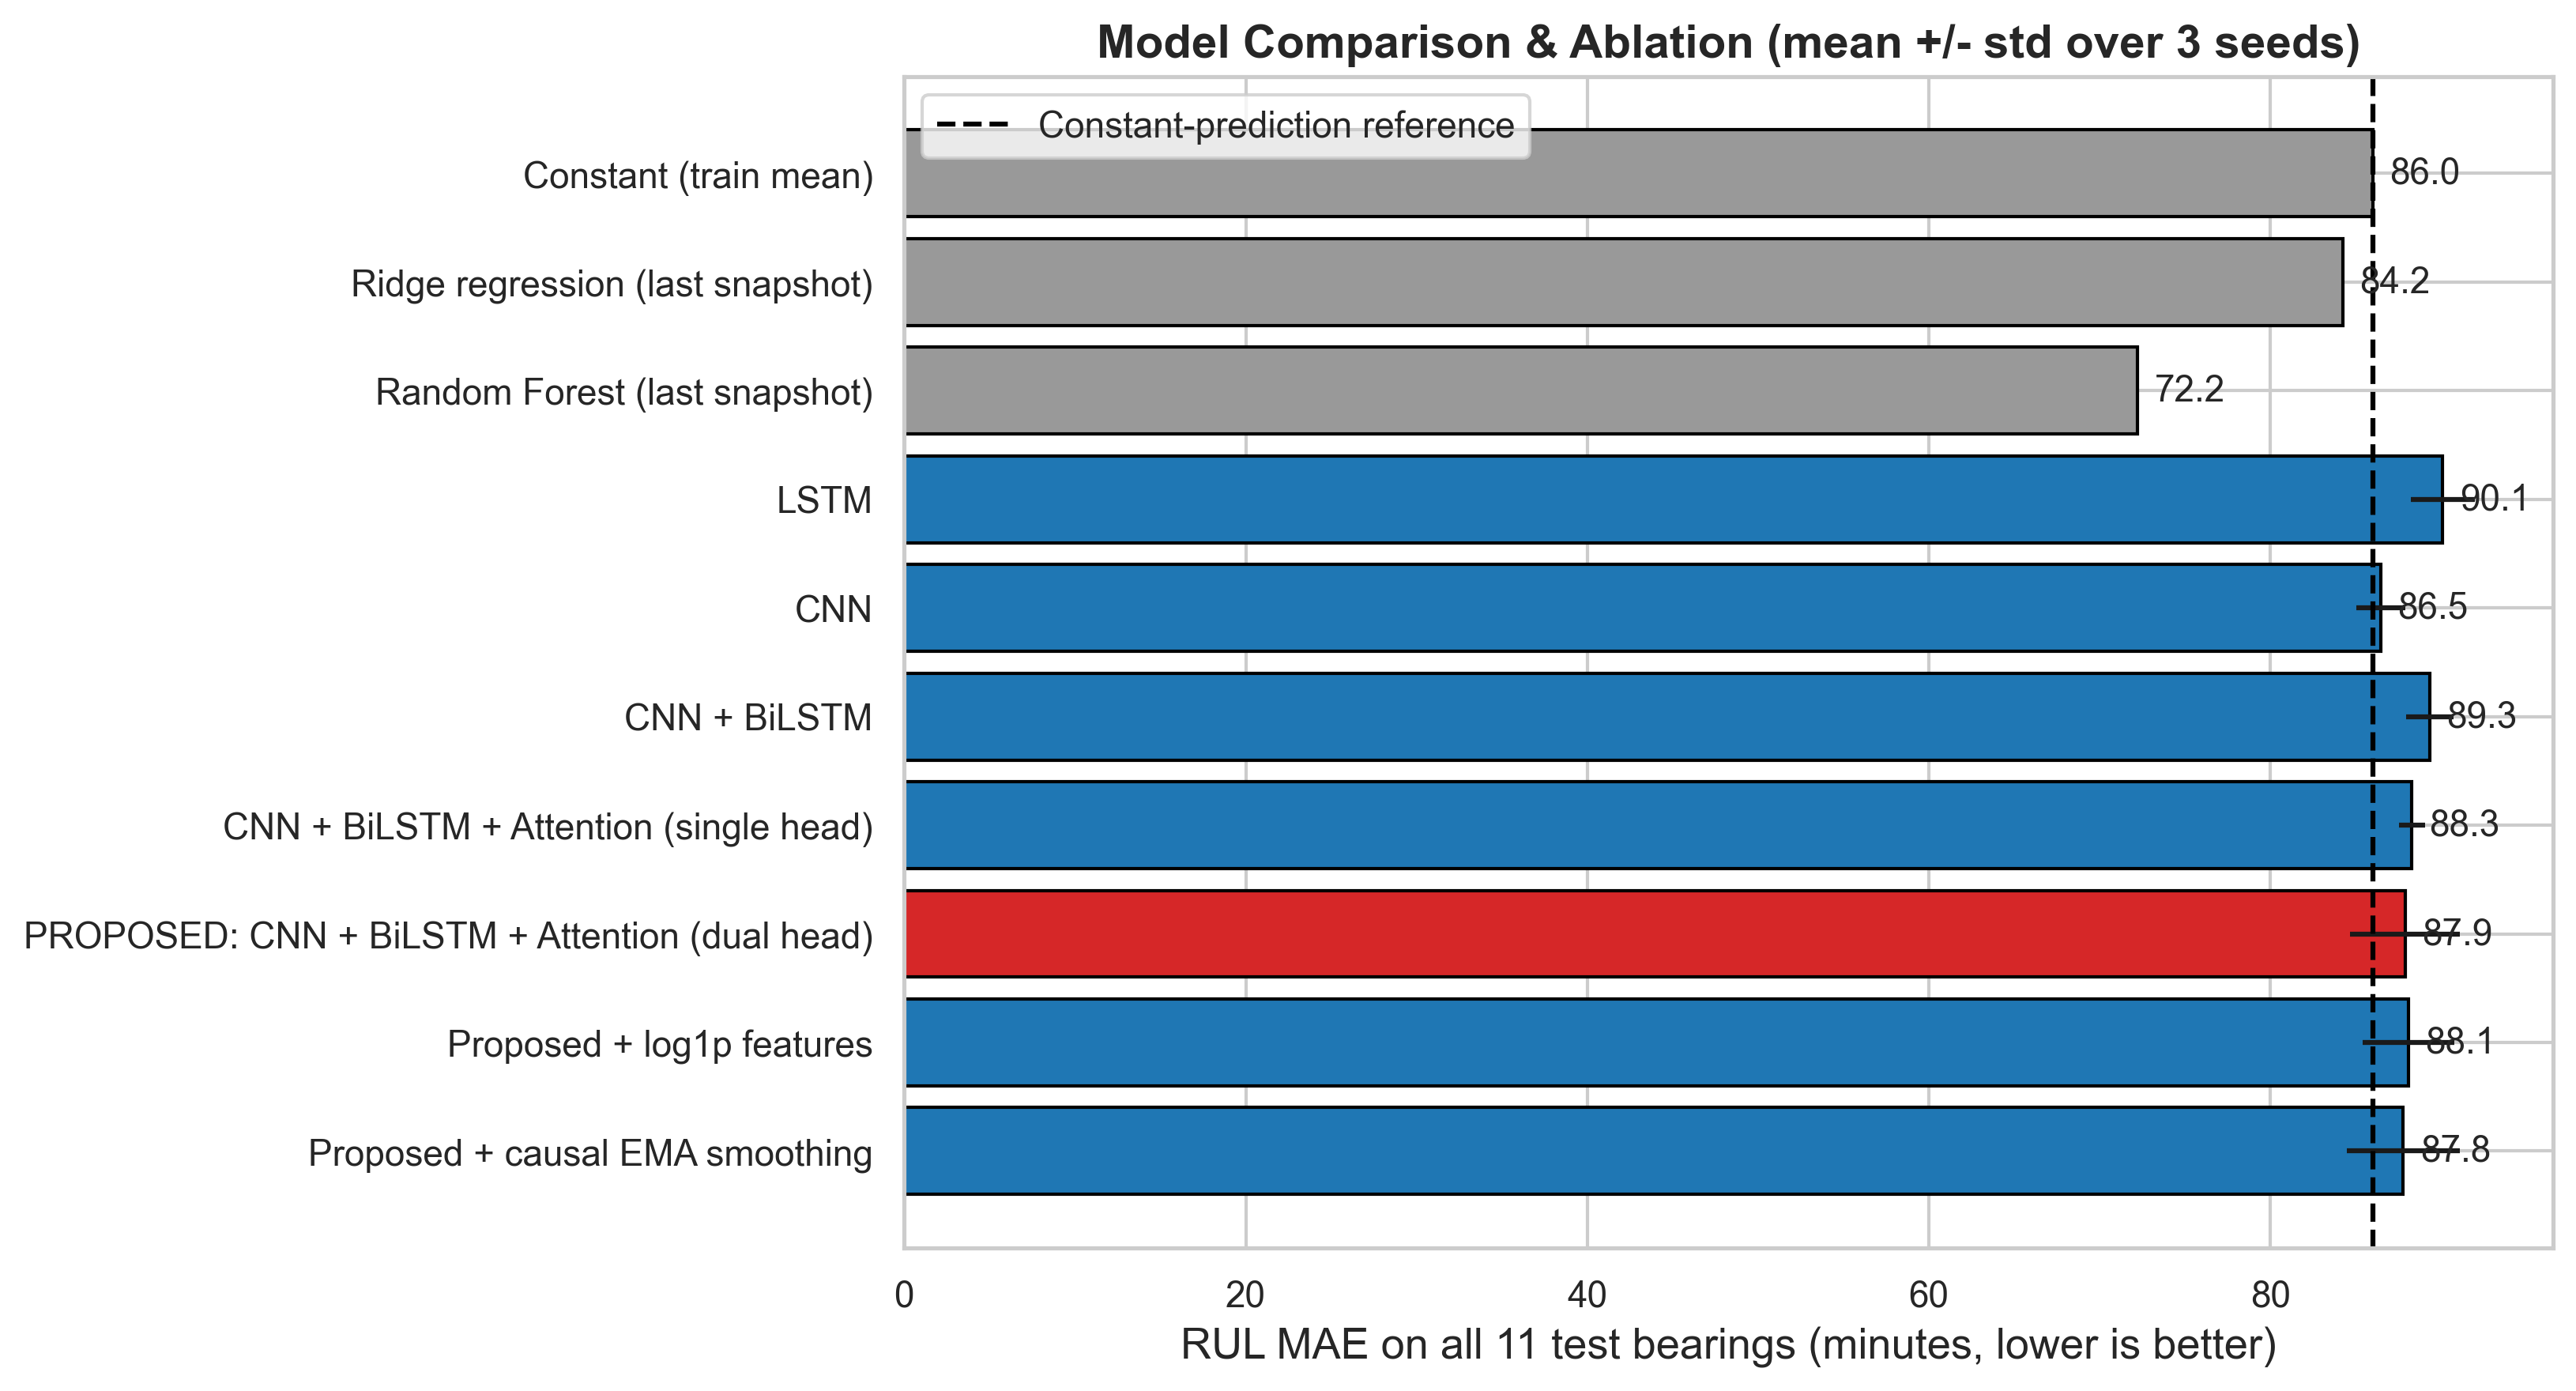

In [15]:
# ==============================================================================
# 14. MODEL COMPARISON & ABLATION  (same data, same split, same training recipe)
# ==============================================================================
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import f1_score

SEEDS = [42, 43, 44]
CAP_MIN = RUL_CAP_SECONDS / 60.0
mask3 = meta_t11['bearing'].isin(test_bearings).values      # the 3 bearings used in sections 9-12
stage_of = lambda y: np.where(y > 0.40, 0, np.where(y > 0.15, 1, 2))

def ema_by_bearing(pred, bearings, alpha=0.1):
    """Causal exponential smoothing (uses only PAST predictions, so it is deployable)."""
    out = pred.copy()
    for b in np.unique(bearings):
        idx = np.where(bearings == b)[0]
        for k in range(1, len(idx)):
            out[idx[k]] = alpha * pred[idx[k]] + (1 - alpha) * out[idx[k - 1]]
    return out

def score(pred_norm, pred_stage):
    pred_norm = np.clip(pred_norm, 0, 1)
    err = np.abs(pred_norm - y_t11) * CAP_MIN
    return {'MAE_min_11': err.mean(), 'MAE_min_3': err[mask3].mean(),
            'PHM_11': compute_trajectory_phm_score(meta_t11['capped_rul_s'].values, pred_norm * RUL_CAP_SECONDS),
            'StageAcc_11': (pred_stage == s_t11).mean(), 'MacroF1_11': f1_score(s_t11, pred_stage, average='macro')}

def build_variant(kind, dual=True, n_feats=30):
    """kind: lstm | cnn | cnn_bilstm | cnn_bilstm_attn (same widths/dropout as the proposed model)."""
    inp = layers.Input(shape=(WINDOW_SIZE, n_feats)); x = inp
    if kind in ('cnn', 'cnn_bilstm', 'cnn_bilstm_attn'):
        for _ in range(2):
            x = layers.Dropout(0.2)(layers.BatchNormalization()(layers.Conv1D(64, 3, padding='same', activation='relu')(x)))
    if kind == 'cnn':
        z = layers.GlobalAveragePooling1D()(x)
    elif kind == 'lstm':
        z = layers.LSTM(64)(x)
    else:
        h = layers.Dropout(0.2)(layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x))
        z = TemporalAttention()(h)[0] if kind == 'cnn_bilstm_attn' else layers.GlobalAveragePooling1D()(h)
    s = layers.Dropout(0.2)(layers.Dense(64, activation='relu')(z))
    rul = layers.Dense(1, name='rul_output')(layers.Dense(32, activation='relu')(s))
    if not dual:
        m = Model(inp, {'rul_output': rul}); m.compile(tf.keras.optimizers.Adam(1e-3), {'rul_output': 'huber'}); return m
    risk = layers.Dense(3, activation='softmax', name='risk_output')(layers.Dense(32, activation='relu')(s))
    m = Model(inp, {'rul_output': rul, 'risk_output': risk})
    m.compile(tf.keras.optimizers.Adam(1e-3), {'rul_output': 'huber', 'risk_output': 'sparse_categorical_crossentropy'},
              loss_weights={'rul_output': 1.0, 'risk_output': 0.5})
    return m

def train_nn(kind, dual, seed, Xtr, Xva, Xte):
    tf.keras.utils.set_random_seed(seed)
    m = build_variant(kind, dual)
    ytr = {'rul_output': y_rul_train, 'risk_output': y_risk_train} if dual else {'rul_output': y_rul_train}
    yva = {'rul_output': y_rul_val, 'risk_output': y_risk_val} if dual else {'rul_output': y_rul_val}
    m.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=35, batch_size=64, verbose=0,
          callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
                     callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)])
    p = m.predict(Xte, batch_size=256, verbose=0)
    pr = np.clip(p['rul_output'].ravel(), 0, 1)
    return pr, (p['risk_output'].argmax(1) if dual else stage_of(pr)), m.count_params()

# ---- log1p variant: many features (RMS, peak, energy, ...) are heavy-tailed, so compress them ----
LOG_COLS = [c for c in feature_columns if c.split('_', 1)[1] in
            ('rms', 'peak', 'p2p', 'std', 'spec_energy', 'crest_factor', 'margin_factor', 'impulse_factor', 'shape_factor')]
def log_df(d):
    d = d.copy(); d[LOG_COLS] = np.log1p(d[LOG_COLS].clip(lower=0)); return d
def windows_only(d, bl, sc):
    X = []
    for b in bl:
        sub = d[d['bearing'] == b].sort_values('snapshot_idx'); xs = sc.transform(sub[feature_columns])
        X.extend(xs[i:i + WINDOW_SIZE] for i in range(len(sub) - WINDOW_SIZE + 1))
    return np.array(X, dtype=np.float32)
df_all_log = log_df(pd.concat([df_features, df_all11]).drop_duplicates(['bearing', 'snapshot_idx']))
sc_log = StandardScaler().fit(df_all_log.loc[df_all_log['bearing'].isin(train_bearings), feature_columns])  # train bearings only
XL_tr, XL_va, XL_te = (windows_only(df_all_log, bl, sc_log) for bl in (train_bearings, val_bearings, all11_bearings))

results, t0 = {}, time.time()
def add(name, runs, params=None):
    results[name] = {'runs': runs, 'params': params}

# ---- non-deep baselines ----
const = np.full(len(y_t11), y_rul_train.mean())
add('Constant (train mean)', [score(const, stage_of(const))])
for name, mdl in [('Ridge regression (last snapshot)', Ridge(alpha=1.0)),
                  ('Random Forest (last snapshot)', RandomForestRegressor(200, min_samples_leaf=5, n_jobs=-1, random_state=SEED))]:
    mdl.fit(X_train[:, -1], y_rul_train); p = np.clip(mdl.predict(X_t11[:, -1]), 0, 1)
    add(name, [score(p, stage_of(p))])

# ---- deep models: 3 seeds each ----
plan = [('LSTM', 'lstm', False, 'std'), ('CNN', 'cnn', False, 'std'), ('CNN + BiLSTM', 'cnn_bilstm', False, 'std'),
        ('CNN + BiLSTM + Attention (single head)', 'cnn_bilstm_attn', False, 'std'),
        ('PROPOSED: CNN + BiLSTM + Attention (dual head)', 'cnn_bilstm_attn', True, 'std'),
        ('Proposed + log1p features', 'cnn_bilstm_attn', True, 'log')]
proposed_preds = []
for name, kind, dual, feat in plan:
    runs, params = [], None
    for sd in SEEDS:
        Xtr, Xva, Xte = (X_train, X_val, X_t11) if feat == 'std' else (XL_tr, XL_va, XL_te)
        pr, pst, params = train_nn(kind, dual, sd, Xtr, Xva, Xte)
        runs.append(score(pr, pst))
        if name.startswith('PROPOSED'): proposed_preds.append(pr)
    add(name, runs, params); print(f"  done: {name}  ({time.time()-t0:.0f}s elapsed)")
sm = [ema_by_bearing(pr, meta_t11['bearing'].values) for pr in proposed_preds]
add('Proposed + causal EMA smoothing', [score(p, stage_of(p)) for p in sm], results['PROPOSED: CNN + BiLSTM + Attention (dual head)']['params'])

rows = []
for name, r in results.items():
    d = pd.DataFrame(r['runs']); row = {'Model': name, 'Params': r['params'] if r['params'] else '-'}
    for k, lab in [('MAE_min_11', 'RUL MAE (min) 11 bearings'), ('MAE_min_3', 'RUL MAE (min) 3 bearings'),
                   ('PHM_11', 'PHM T-Score'), ('StageAcc_11', 'Stage Acc'), ('MacroF1_11', 'Macro-F1')]:
        row[lab] = f"{d[k].mean():.3f}" if len(d) == 1 else f"{d[k].mean():.3f} +/- {d[k].std():.3f}"
    rows.append(row)
df_cmp = pd.DataFrame(rows)
df_cmp.to_csv(os.path.join(RESULTS_DIR, 'model_comparison.csv'), index=False)
display(df_cmp)

# ---- Figure 11: bar chart of RUL MAE (lower is better) with the constant-prediction reference line ----
names = list(results); means = [pd.DataFrame(results[n]['runs'])['MAE_min_11'].mean() for n in names]
stds = [pd.DataFrame(results[n]['runs'])['MAE_min_11'].std() if len(results[n]['runs']) > 1 else 0 for n in names]
fig, ax = plt.subplots(figsize=(11, 6))
cols = ['#999999' if i < 3 else ('#d62728' if n.startswith('PROPOSED') else '#1f77b4') for i, n in enumerate(names)]
ax.barh(names, means, xerr=stds, color=cols, edgecolor='black')
ax.axvline(means[0], color='black', ls='--', label='Constant-prediction reference')
ax.invert_yaxis(); ax.set_xlabel('RUL MAE on all 11 test bearings (minutes, lower is better)')
ax.set_title('Model Comparison & Ablation (mean +/- std over 3 seeds)', fontweight='bold'); ax.legend()
for i, m in enumerate(means): ax.text(m + 1, i, f'{m:.1f}', va='center')
plt.tight_layout(); fig.savefig(os.path.join(FIGURES_DIR, 'fig11_model_comparison.png'), dpi=300); plt.show()


### How to Read the Comparison (numbers from the run above; re-running changes them slightly within the +/- shown)

| Finding | Evidence (11 test bearings, RUL MAE in minutes, lower is better) |
|---|---|
| The vibration-driven models barely beat, or do not beat, a model that ignores the sensor | Constant 86.0 vs proposed 87.9 +/- 3.2 |
| **A Random Forest on the newest snapshot is the best model here** | 72.2 min, PHM 0.281 vs proposed 0.194 |
| Adding CNN, BiLSTM or attention does not change accuracy beyond seed noise | LSTM 90.1, CNN 86.5, CNN+BiLSTM 89.3, +Attention 88.3, dual head 87.9 (std 0.8 to 3.2) |
| The auxiliary stage head does not improve RUL error | 88.3 (single head) vs 87.9 (dual head), within noise |
| log1p feature scaling and EMA smoothing do not help either | 88.1 and 87.8 |
| Stage accuracy of the deep models is below the trivial 'always Normal' rule | 0.51 to 0.55 vs 0.61 (Macro-F1 is higher: 0.39 to 0.43 vs 0.25) |

**What this means:** on this data split the extra architecture components are **not shown to improve prediction accuracy**. Their justification is design-based: interpretability (attention, Section 15) and an operator-friendly stage alarm, not accuracy. Claiming accuracy gains would not be supported by this table.


## 15. Feature-Level Explainability

Two views of what the trained model uses: **permutation importance** (which of the 30 features, when shuffled, hurt the RUL estimate most) and the **average attention profile** for each true health stage.

> **In simple words:** we scramble one feature at a time; if the model gets much worse, it was relying on that feature.


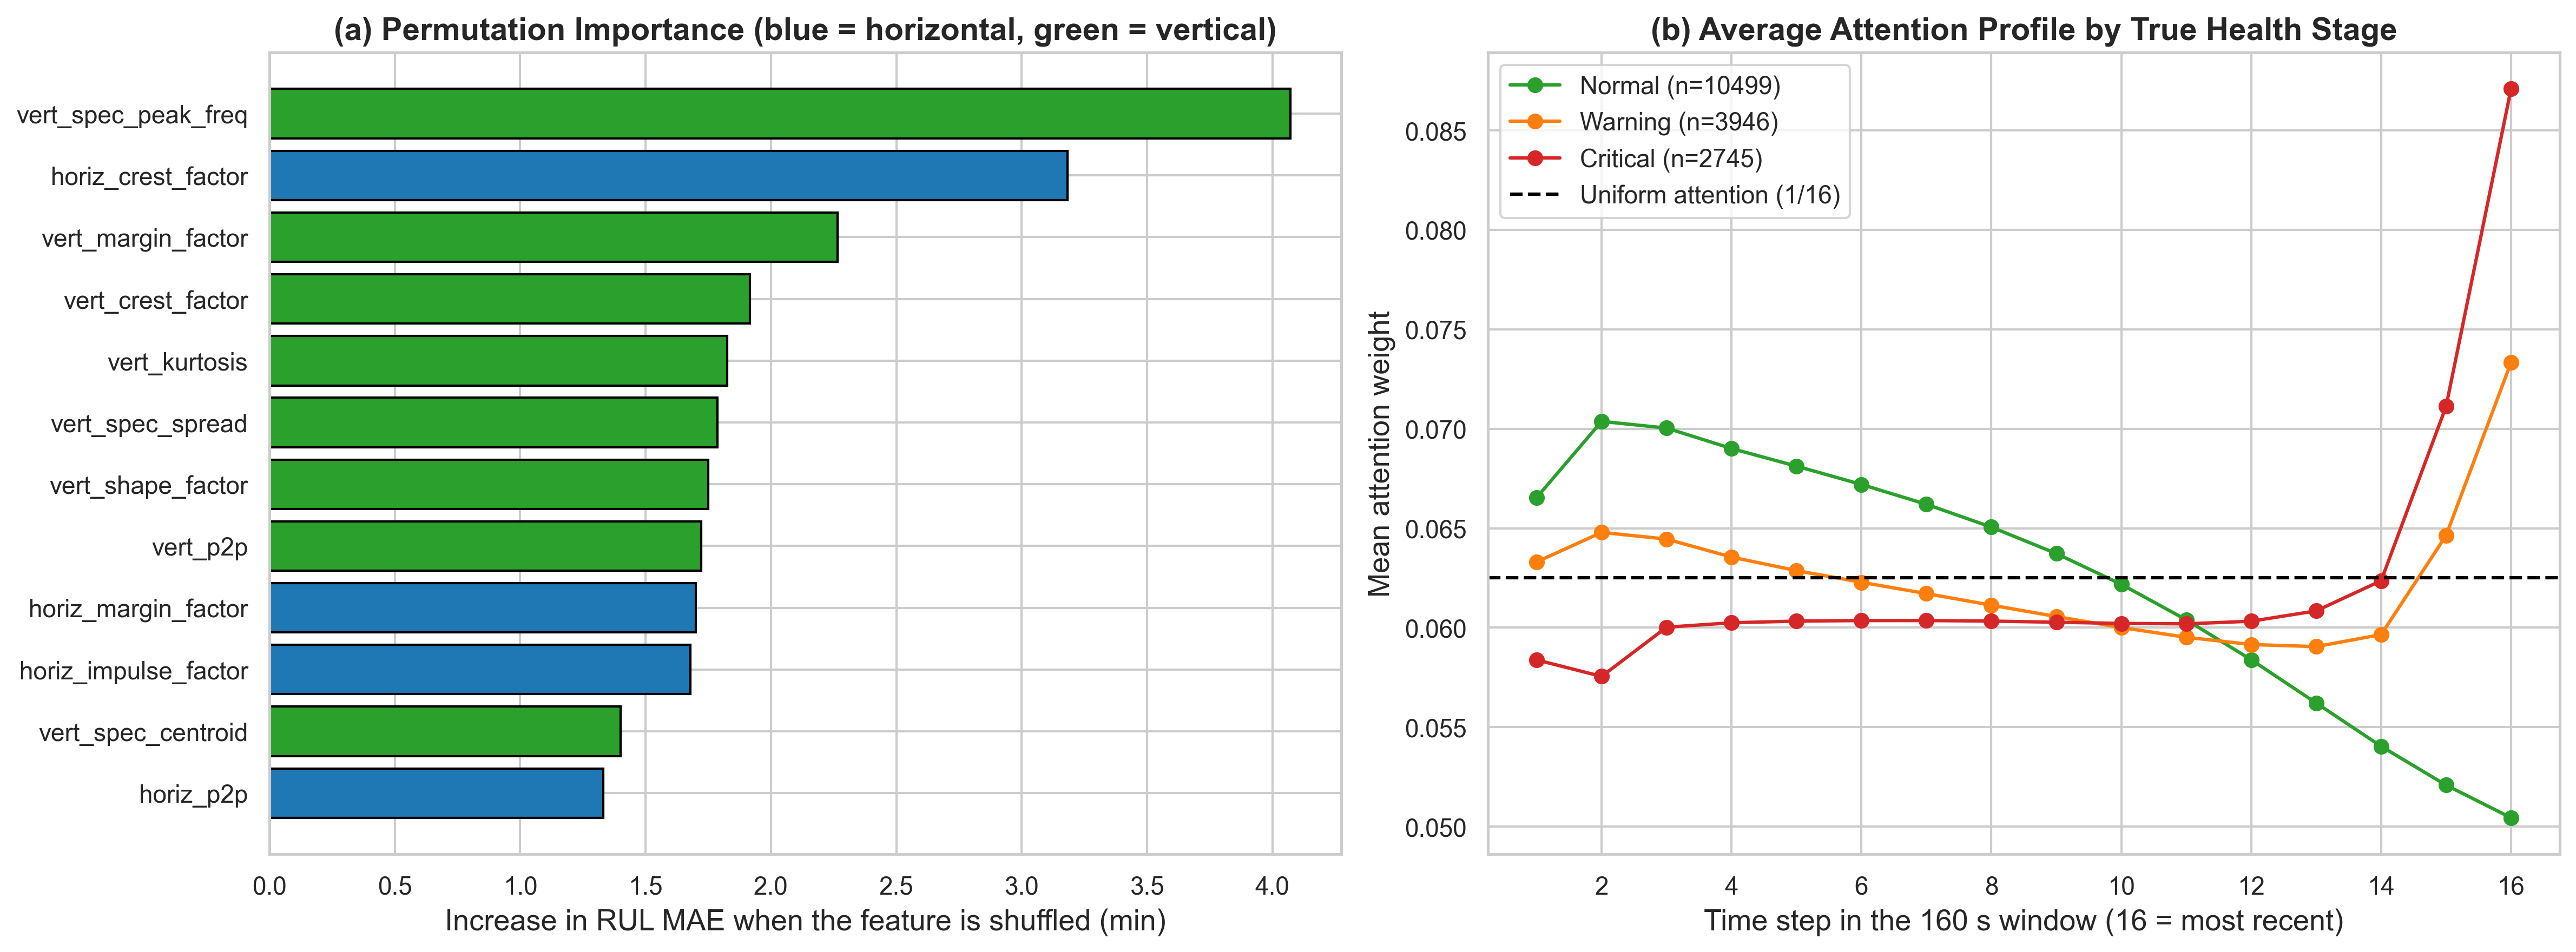

Top-5 features: vert_spec_peak_freq (+4.1 min), horiz_crest_factor (+3.2 min), vert_margin_factor (+2.3 min), vert_crest_factor (+1.9 min), vert_kurtosis (+1.8 min)
Normal   : attention entropy = 2.720 (uniform = 2.773), weight on last 4 steps = 0.213 (uniform = 0.250)
Critical : attention entropy = 2.709 (uniform = 2.773), weight on last 4 steps = 0.281 (uniform = 0.250)


In [16]:
# ==============================================================================
# 15. FEATURE-LEVEL EXPLAINABILITY: PERMUTATION IMPORTANCE  +  ATTENTION BY TRUE STAGE
# ==============================================================================
# (a) Permutation importance: shuffle ONE feature (across all windows) and see how much the saved
#     model's RUL error grows. Big growth = the model relies on that feature.
rng = np.random.default_rng(SEED)
rul_err = lambda X: np.abs(np.clip(model.predict(X, batch_size=512, verbose=0)['rul_output'].ravel(), 0, 1) - y_t11).mean()
base_err = rul_err(X_t11)
imp = []
for j, name in enumerate(feature_columns):
    deltas = []
    for _ in range(3):
        Xp = X_t11.copy(); Xp[:, :, j] = Xp[rng.permutation(len(Xp)), :, j]
        deltas.append(rul_err(Xp) - base_err)
    imp.append(np.mean(deltas) * CAP_MIN)
df_imp = pd.DataFrame({'feature': feature_columns, 'MAE_increase_min': imp}).sort_values('MAE_increase_min', ascending=False)
df_imp.to_csv(os.path.join(RESULTS_DIR, 'permutation_importance.csv'), index=False)
top = df_imp.head(12).iloc[::-1]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.barh(top['feature'], top['MAE_increase_min'], color=['#1f77b4' if f.startswith('horiz') else '#2ca02c' for f in top['feature']], edgecolor='black')
ax1.set_xlabel('Increase in RUL MAE when the feature is shuffled (min)')
ax1.set_title('(a) Permutation Importance (blue = horizontal, green = vertical)', fontweight='bold')

# (b) Average attention profile per TRUE health stage over all 11 test bearings
attn_all = attn_submodel.predict(X_t11, batch_size=256, verbose=0)[:, :, 0]
for st, lab, col in [(0, 'Normal', '#2ca02c'), (1, 'Warning', '#ff7f0e'), (2, 'Critical', '#d62728')]:
    ax2.plot(np.arange(1, WINDOW_SIZE + 1), attn_all[s_t11 == st].mean(0), marker='o', color=col, label=f'{lab} (n={int((s_t11 == st).sum())})')
ax2.axhline(1.0 / WINDOW_SIZE, color='black', ls='--', label='Uniform attention (1/16)')
ax2.set_xlabel('Time step in the 160 s window (16 = most recent)'); ax2.set_ylabel('Mean attention weight')
ax2.set_title('(b) Average Attention Profile by True Health Stage', fontweight='bold'); ax2.legend()
plt.tight_layout(); fig.savefig(os.path.join(FIGURES_DIR, 'fig12_feature_importance_and_attention.png'), dpi=300); plt.show()

ent = -(attn_all * np.log(attn_all + 1e-12)).sum(1)
print("Top-5 features:", ", ".join(f"{f} (+{v:.1f} min)" for f, v in zip(df_imp['feature'].head(5), df_imp['MAE_increase_min'].head(5))))
for st, lab in [(0, 'Normal'), (1, 'Warning'), (2, 'Critical')]:
    print(f"{lab:9s}: attention entropy = {ent[s_t11 == st].mean():.3f} (uniform = {np.log(WINDOW_SIZE):.3f}), weight on last 4 steps = {attn_all[s_t11 == st][:, -4:].sum(1).mean():.3f} (uniform = 0.250)")


### How to Read the Explainability Results
- **Permutation importance:** no single feature dominates; the largest effect is about +4 min of RUL error (`vert_spec_peak_freq`), followed by crest/margin factors and vertical kurtosis: the impulsiveness features that Section 5 identified. The small size of every effect is consistent with the weak accuracy in Section 14: the model has not learned a strong dependence on any feature.
- **Attention profile:** overall attention is close to uniform (entropy 2.71 to 2.72 vs 2.77), but the *shape* changes systematically with health stage (Figure 12b). For **Normal** windows attention leans to the older steps and is lowest on the newest step (0.050); for **Critical** windows it concentrates on the newest step (0.087, about 1.4x the uniform 0.0625); Warning is in between. So the model does shift towards the most recent recording when failure is near, which is a sensible behaviour. The effect is moderate, not a sharp spike, and it explains *where in time* the model looks, not why the RUL estimate is or is not accurate.


## 16. Honest Discussion, Limitations and Next Steps

### What the results say
- The pipeline is sound and reproducible: features, bearing-level split, training-only scaler and cap, real leakage assertions, evaluation on all 11 test bearings (Section 13: MAE 93.4 min, PHM 0.167, stage accuracy 52.8%).
- The model's RUL accuracy is **weak**: about as good as predicting a constant (Section 14). Simple models are as good or better. This must be stated in any review or paper; it should not be presented as state-of-the-art.

### Why accuracy is limited (root causes we can point to)
1. **Only 3 training bearings** for a network with about 114 k parameters (validation accuracy 38% vs 99% training accuracy in Section 8 is classic memorisation).
2. **The RUL cap does not fit most bearings.** The cap (16,812 s) is 60% of the single longest training bearing (Bearing1_1, 28,020 s). Five of the six learning bearings live **shorter** than the cap, so for them the target never sits at the 1.0 plateau and the label at the start of life depends on that bearing's unknown total lifetime while the sensor shows the same healthy signal. Part of the error is therefore irreducible with this target definition. (Only the cap is training-derived, so there is still no test leakage.)
3. **Every bearing starts to degrade at a different point** (Section 5), so the mapping from features to remaining life is not the same across bearings.

### What we tested that did not help (Section 14)
log1p feature scaling, causal EMA smoothing, the auxiliary dual head and the attention layer: none improved RUL error beyond seed noise.

### What is fair to claim
- A leakage-free, fully reproducible prognostics pipeline with real evaluation on 11 held-out bearings and transparent baselines.
- Two working explainability tools (temporal attention, permutation importance) and an operator-style dashboard.
- **Not** fair to claim: that CNN-BiLSTM-Attention or the dual head improve accuracy, or that attention proves what physically triggers an alarm.

### Concrete next steps (in order of expected value)
1. Train on all 6 learning bearings and choose hyper-parameters by **leave-one-bearing-out** cross-validation (more independent histories).
2. Replace the single global cap by a **per-bearing degradation-onset target** (constant RUL until a health indicator crosses a threshold, then linear decay), and validate the onset rule on training bearings only.
3. Use a small model or a Random Forest / gradient-boosting baseline as the reference to beat, and add data augmentation for the deep model.


## 17. Model & Artifact Persistence Summary

All trained models, scalers, metadata, evaluation results, and publication figures have been systematically saved into organized project directories:
- `models/dual_head_cnn_bilstm_attention.keras`: Trained deep learning model weights.
- `models/scaler.pkl`: StandardScaler fitted strictly on training bearings.
- `models/feature_names.json`: Schema of all 30 engineered vibration features.
- `results/evaluation_metrics.json`: Final empirical evaluation scores.
- `results/test_predictions.csv`: Detailed snapshot-level predictions across all held-out test bearings.
- `results/figures/`: High-resolution PNG figures formatted for screenshots and publication.

New artifacts written by Sections 13-15: `results/notebook_per_bearing_metrics_11.csv`, `results/model_comparison.csv`, `results/permutation_importance.csv`, `results/figures/fig11_model_comparison.png`, `results/figures/fig12_feature_importance_and_attention.png`.



In [14]:
# ==============================================================================
# 17. VERIFYING SAVED ARTIFACTS & DIRECTORY STRUCTURE
# ==============================================================================
print("=" * 80)
print("PROJECT ARTIFACT AUDIT")
print("=" * 80)

for root_dir in [MODELS_DIR, RESULTS_DIR]:
    print(f"Directory: {root_dir}")
    for root, dirs, files in os.walk(root_dir):
        for f in files:
            p = os.path.join(root, f)
            size_kb = os.path.getsize(p) / 1024.0
            print(f"  ├── {os.path.relpath(p, root_dir)} ({size_kb:.1f} KB)")
print("=" * 80)
print("All project components successfully generated, verified, and persisted!")


PROJECT ARTIFACT AUDIT
Directory: D:\faisal-VS\faisal project\MA_project\models
  ├── dual_head_cnn_bilstm_attention.keras (1426.7 KB)
  ├── feature_names.json (0.6 KB)
  ├── scaler.pkl (2.2 KB)
Directory: D:\faisal-VS\faisal project\MA_project\results
  ├── evaluation_metrics.json (0.5 KB)
  ├── extracted_bearing_features.csv (5320.3 KB)
  ├── test_predictions.csv (742.7 KB)
  ├── figures\fig10_industrial_decision_dashboard.png (352.5 KB)
  ├── figures\fig1_raw_vibration_healthy_vs_degraded.png (853.3 KB)
  ├── figures\fig2_frequency_spectrum_fft.png (403.5 KB)
  ├── figures\fig3_vibration_feature_trends.png (586.9 KB)
  ├── figures\fig4_training_convergence.png (326.8 KB)
  ├── figures\fig5_rul_actual_vs_predicted.png (549.0 KB)
  ├── figures\fig6_rul_residuals_error.png (341.4 KB)
  ├── figures\fig7_failure_risk_probabilities.png (654.7 KB)
  ├── figures\fig8_confusion_matrix.png (211.8 KB)
  ├── figures\fig9_temporal_attention_weights.png (238.1 KB)
All project components successfu